# Frozen vs Evolving NTK Mode Dynamics

This notebook analyzes one target family at one width in detail, then compares width and target families.

Current default run: `ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w1024`.

Notebook flow:
1. Single-run diagnostics (objective, residual modes, phase portraits, principal angles, projector drift).
2. Cross-width comparison for the same target family.
3. Cross-target-family comparison at matched width sets.



## Theory and What We Measure

### 1) Objective (least squares)

We use

$L(t) = \frac{1}{2}\|r_t\|_2^2, \qquad r_t = f_t(X_{train}) - y_{train}.$ 

This is the least-squares objective used in the theoretical kernel dynamics derivations.

### 2) Residual Fourier projections

For a normalized sampled Fourier mode $\phi_m$ on the train grid:

$c_m(t) = \phi_m^\top r_t.$

Tracking $c_m(t)$ shows how each frequency component of the residual decays.

### 3) Residual phase portraits

For each frequency $k\ge 1$:

$x_k(t)=\langle r_t,\cos(k\theta)\rangle,\qquad y_k(t)=\langle r_t,\sin(k\theta)\rangle.$ 

The trajectory $(x_k(t), y_k(t))$ visualizes residual flow in that Fourier plane.

### 4) Eigenspace alignment and principal angles

Let $F_k$ be the Fourier subspace and $\hat{F}_k(t)$ the matched empirical eigenspace.
We track the two principal angles $\theta_{k,1}(t),\theta_{k,2}(t)$ between these subspaces.

Small and stable angles indicate good Fourier alignment; growth in angles indicates drift away from Fourier eigenspaces.


## Roadmap for Interpretation

- **Single-run sections** show how Fourier-plane alignment evolves in time for one `(target, width)` run.
- **Cross-width section** asks whether larger width stabilizes eigenspace geometry (more lazy-like behavior).
- **Cross-target section** asks whether drift is target-dependent when higher frequencies are activated.

Primary geometric diagnostic:
$$\epsilon_k(t)=\|\widehat P_k(t)-P_k\|_F,\qquad \Delta\epsilon_k(t)=\epsilon_k(t)-\epsilon_k(0).$$


In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / 'utils').exists() and (ROOT.parent / 'utils').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.artifacts_io import latest_run_dir, load_manifest, npz

BASE_RESULTS = ROOT / 'results'
EXP_NAME = 'ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512'
PLOT_DIR = ROOT / 'notebooks' / 'plots' / EXP_NAME
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

print('Project root:', ROOT)
print('Results base:', BASE_RESULTS)
print('Plots dir:', PLOT_DIR)



Project root: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments
Results base: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results
Plots dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512


In [4]:
run_dir = latest_run_dir(BASE_RESULTS, EXP_NAME)
if run_dir is None:
    raise FileNotFoundError(f"No run found for experiment '{EXP_NAME}' in {BASE_RESULTS}")

manifest = load_manifest(run_dir)
probe = npz(run_dir, manifest['probe_geometry'])
target = npz(run_dir, manifest['target_task'])

widths = sorted([int(w) for w in manifest['runs'].keys()])
WIDTH = widths[0]
run = npz(run_dir, manifest['runs'][str(WIDTH)])

n_train = int(manifest['meta']['n_train'])
snapshot_steps = np.asarray(run['snapshot_steps'], dtype=int)
seeds = np.asarray(run['seeds'], dtype=int)
tracked_freqs = np.asarray(run['tracked_freqs'], dtype=int)
plane_freqs = np.asarray(run['plane_freqs'], dtype=int)

tracked_mode_names = [str(x) for x in run['tracked_mode_names']]
tracked_mode_freqs = np.asarray(run['tracked_mode_freqs'], dtype=int)
tracked_mode_types = np.asarray([str(x) for x in run['tracked_mode_types']])

mode_proj_frozen = np.asarray(run['mode_proj_frozen'], dtype=float)
mode_proj_evolving = np.asarray(run['mode_proj_evolving'], dtype=float)

plane_projector_fro_frozen = np.asarray(run['plane_projector_fro_frozen'], dtype=float)
plane_projector_fro_evolving = np.asarray(run['plane_projector_fro_evolving'], dtype=float)
plane_angles_frozen = np.asarray(run['plane_angles_frozen'], dtype=float)
plane_angles_evolving = np.asarray(run['plane_angles_evolving'], dtype=float)
plane_coeff_raw_frozen = np.asarray(run['plane_coeff_raw_frozen'], dtype=float)
plane_coeff_raw_evolving = np.asarray(run['plane_coeff_raw_evolving'], dtype=float)

if 'train_loss_frozen' in run:
    train_loss_frozen = np.asarray(run['train_loss_frozen'], dtype=float)
    train_loss_evolving = np.asarray(run['train_loss_evolving'], dtype=float)
else:
    # backward compatibility with older runs
    train_mse_frozen = np.asarray(run['train_mse_frozen'], dtype=float)
    train_mse_evolving = np.asarray(run['train_mse_evolving'], dtype=float)
    train_loss_frozen = 0.5 * n_train * train_mse_frozen
    train_loss_evolving = 0.5 * n_train * train_mse_evolving

train_mse_frozen = (2.0 / n_train) * train_loss_frozen
train_mse_evolving = (2.0 / n_train) * train_loss_evolving

gamma_eval = np.asarray(probe['gamma_eval'], dtype=float)
y_eval_true = np.asarray(target['y_eval_true'], dtype=float)

has_eval_preds = ('pred_eval_frozen' in run) and ('pred_eval_evolving' in run)
if has_eval_preds:
    pred_eval_frozen = np.asarray(run['pred_eval_frozen'], dtype=float)
    pred_eval_evolving = np.asarray(run['pred_eval_evolving'], dtype=float)

print('Loaded run:', run_dir)
print('width:', WIDTH)
print('seeds:', seeds.tolist())
print('num snapshots:', len(snapshot_steps), '| first/last:', int(snapshot_steps[0]), int(snapshot_steps[-1]))
print('tracked freqs:', tracked_freqs.tolist())
print('plane freqs:', plane_freqs.tolist())
print('tracked modes:', tracked_mode_names)
print('has eval predictions:', has_eval_preds)



Loaded run: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/20260508-115107-fc6f47a4
width: 512
seeds: [0, 1, 2, 3, 4]
num snapshots: 201 | first/last: 0 20000
tracked freqs: [0, 1, 2, 3, 4, 5, 6]
plane freqs: [0, 1, 2, 3, 4, 5, 6]
tracked modes: ['const', 'cos_1', 'sin_1', 'cos_2', 'sin_2', 'cos_3', 'sin_3', 'cos_4', 'sin_4', 'cos_5', 'sin_5', 'cos_6', 'sin_6']
has eval predictions: True


In [5]:
def keep_existing(items, allowed):
    allowed = set(allowed)
    return [x for x in items if x in allowed]


def seed_mean_std(arr):
    arr = np.asarray(arr, dtype=float)
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)


def nearest_step_idx(step):
    return int(np.argmin(np.abs(snapshot_steps - int(step))))


def plane_idx(k):
    m = np.where(plane_freqs == int(k))[0]
    if len(m) != 1:
        raise ValueError(f'Frequency {k} not found in plane_freqs {plane_freqs.tolist()}')
    return int(m[0])


def tracked_mode_index(k, mode_type):
    m = np.where((tracked_mode_freqs == int(k)) & (tracked_mode_types == str(mode_type)))[0]
    if len(m) != 1:
        raise ValueError(f'Could not find unique mode for k={k}, type={mode_type}')
    return int(m[0])


def mode_sort_key(mode_name):
    if mode_name in ('const', 'cos_0'):
        return (0, 0)
    if mode_name.startswith('cos_'):
        return (int(mode_name.split('_')[1]), 0)
    if mode_name.startswith('sin_'):
        return (int(mode_name.split('_')[1]), 1)
    return (10**9, mode_name)


default_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Story-notebook style: assign colors mode-wise from a stable ordered list,
# then derive per-frequency colors from those mode colors.
tracked_modes_sorted = sorted([str(m) for m in tracked_mode_names], key=mode_sort_key)
mode_to_color = {m: default_cycle[i % len(default_cycle)] for i, m in enumerate(tracked_modes_sorted)}

freq_to_color = {}
for i, k in enumerate(sorted(set(int(x) for x in plane_freqs))):
    cos_key = f'cos_{k}'
    sin_key = f'sin_{k}'
    if cos_key in mode_to_color:
        freq_to_color[k] = mode_to_color[cos_key]
    elif sin_key in mode_to_color:
        freq_to_color[k] = mode_to_color[sin_key]
    else:
        freq_to_color[k] = default_cycle[i % len(default_cycle)]

print('Mode-to-color map:', mode_to_color)
print('Frequency-to-color map:', freq_to_color)




Mode-to-color map: {'const': '#1f77b4', 'cos_1': '#ff7f0e', 'sin_1': '#2ca02c', 'cos_2': '#d62728', 'sin_2': '#9467bd', 'cos_3': '#8c564b', 'sin_3': '#e377c2', 'cos_4': '#7f7f7f', 'sin_4': '#bcbd22', 'cos_5': '#17becf', 'sin_5': '#1f77b4', 'cos_6': '#ff7f0e', 'sin_6': '#2ca02c'}
Frequency-to-color map: {0: '#1f77b4', 1: '#ff7f0e', 2: '#d62728', 3: '#8c564b', 4: '#7f7f7f', 5: '#17becf', 6: '#ff7f0e'}


## Training Objective Over Time (Least Squares)

We plot $L(t)=\frac{1}{2}\|r_t\|_2^2$ (mean +- std over seeds).


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/train_ls_frozen_vs_evolving_w512.png


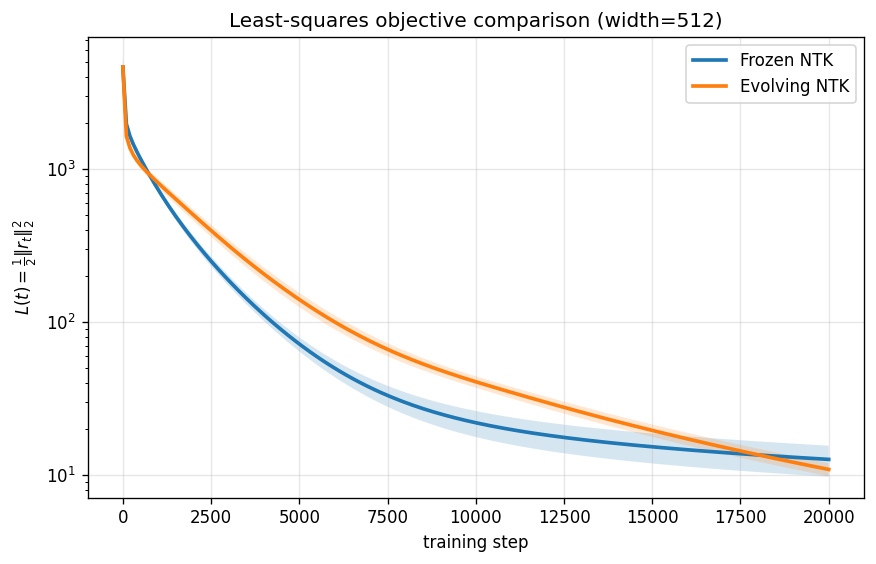

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w128/train_ls_frozen_vs_evolving_w128.png


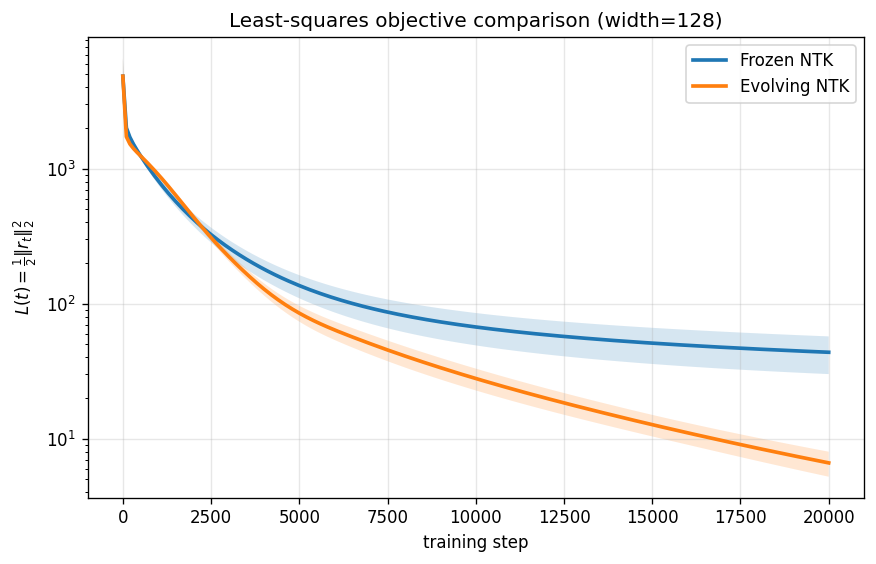

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w256/train_ls_frozen_vs_evolving_w256.png


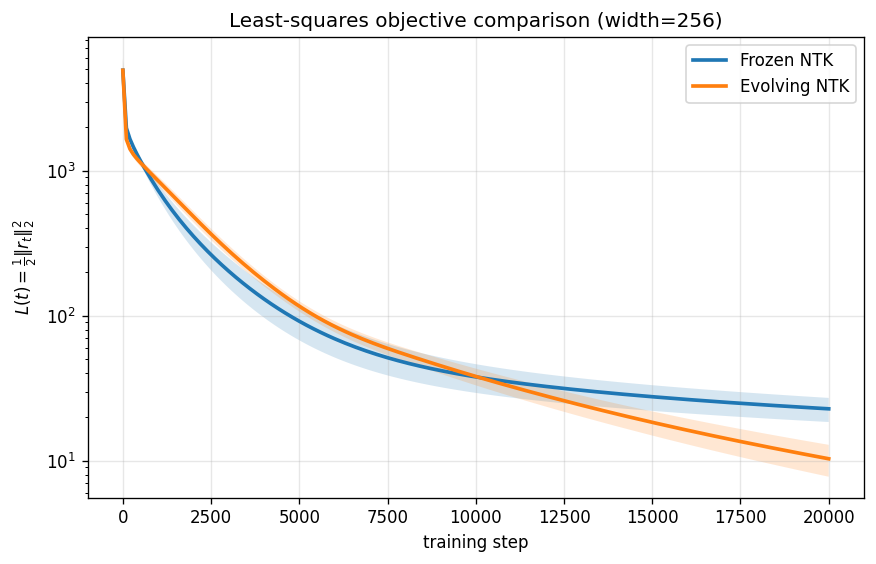

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/train_ls_frozen_vs_evolving_w512.png


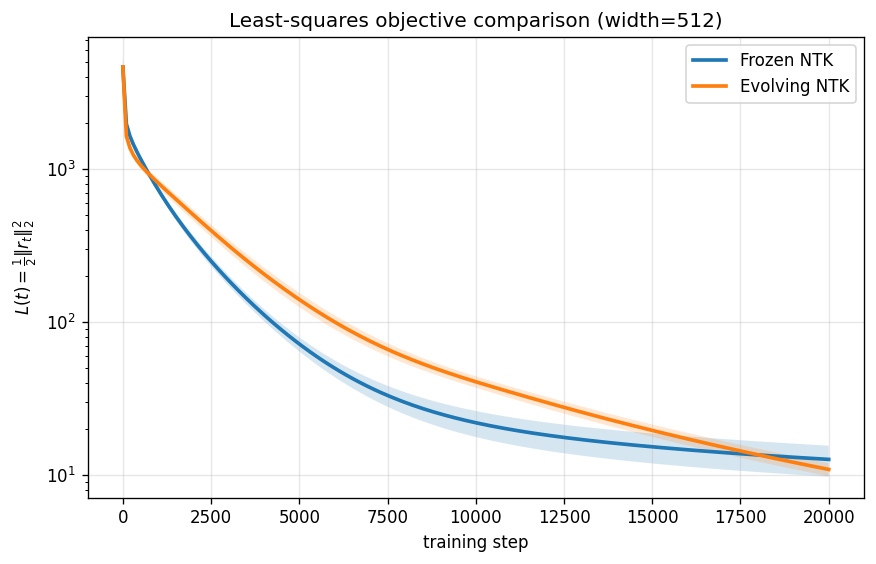

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w1024/train_ls_frozen_vs_evolving_w1024.png


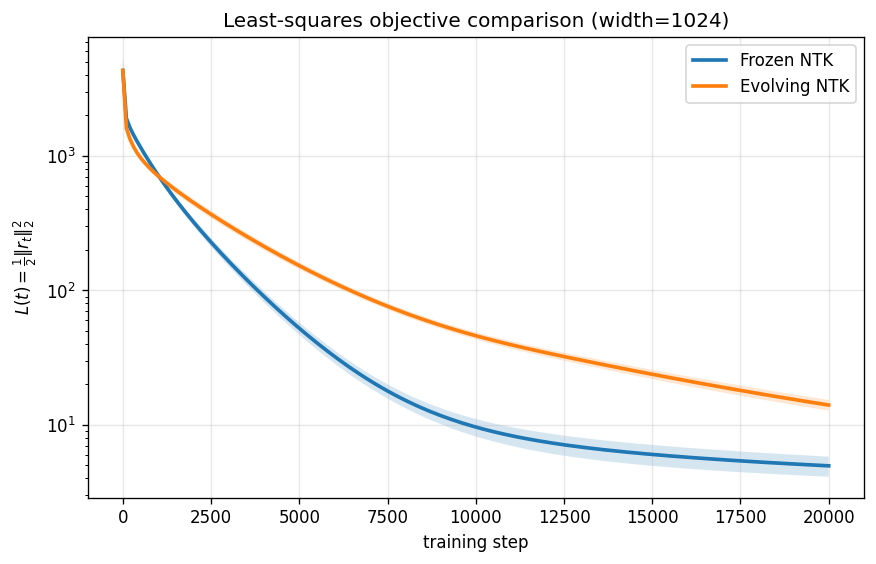

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_compare/train_ls_frozen_vs_evolving_cross_width_w128_w256_w512_w1024.png


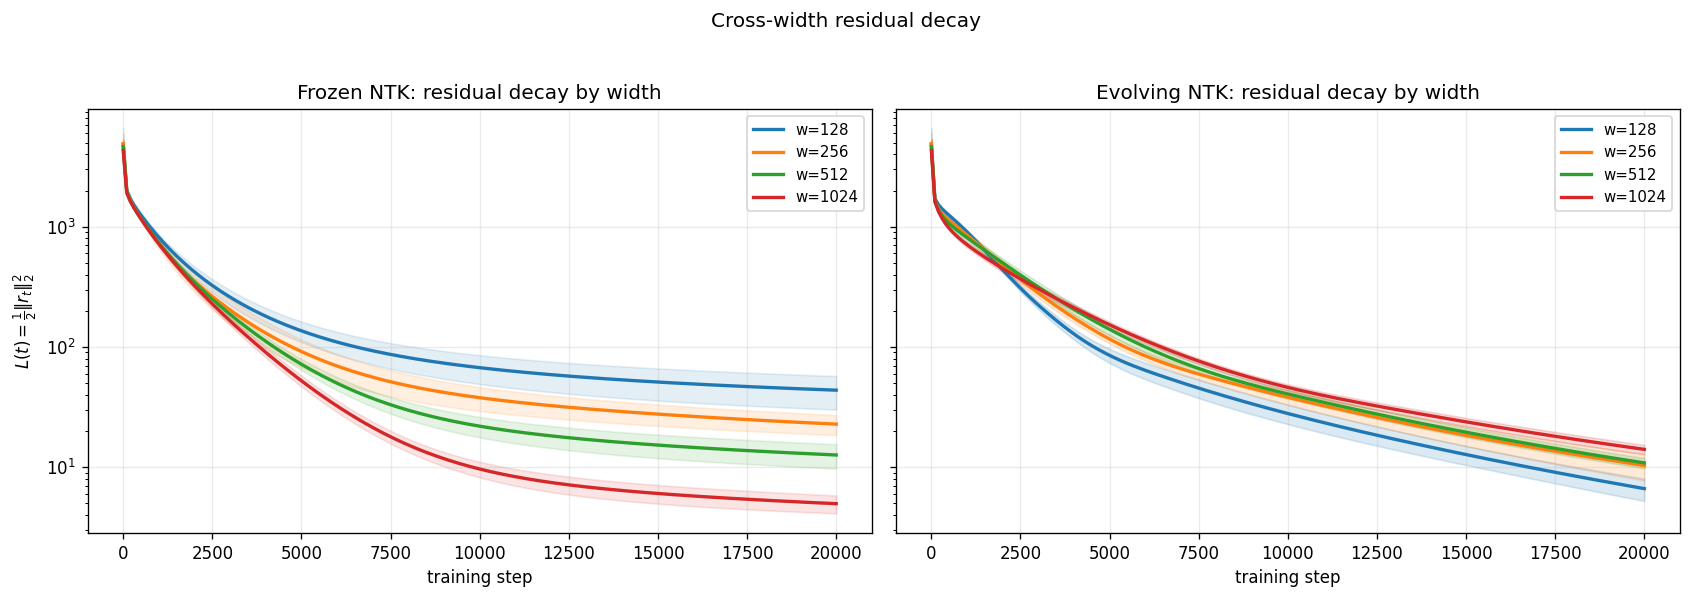

In [6]:
# Width-specific residual-decay plot for the currently loaded run
m_f, s_f = seed_mean_std(train_loss_frozen)
m_e, s_e = seed_mean_std(train_loss_evolving)

plt.figure(figsize=(7.4, 4.8))
plt.plot(snapshot_steps, m_f, linewidth=2.2, label='Frozen NTK')
plt.fill_between(snapshot_steps, np.maximum(m_f - s_f, 1e-16), m_f + s_f, alpha=0.18)

plt.plot(snapshot_steps, m_e, linewidth=2.2, label='Evolving NTK')
plt.fill_between(snapshot_steps, np.maximum(m_e - s_e, 1e-16), m_e + s_e, alpha=0.18)

plt.yscale('log')
plt.xlabel('training step')
plt.ylabel(r'$L(t)=\frac{1}{2}\|r_t\|_2^2$')
plt.title(f'Least-squares objective comparison (width={WIDTH})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

filename = PLOT_DIR / f'train_ls_frozen_vs_evolving_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

# Same objective plot for other widths in the k0256 family
WIDTHS_COMPARE = [128, 256, 512, 1024]
TARGET_FAMILY_FMT = 'ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w{width}'

cross_plot_dir = ROOT / 'notebooks' / 'plots' / 'ntk_frozen_vs_evolving_mode_dynamics_width_compare'
cross_plot_dir.mkdir(parents=True, exist_ok=True)

width_colors_compare = {
    128: 'C0',
    256: 'C1',
    512: 'C2',
    1024: 'C3',
}

available = []
curve_data = {}

for w in WIDTHS_COMPARE:
    exp_name_w = TARGET_FAMILY_FMT.format(width=w)
    run_dir_w = latest_run_dir(BASE_RESULTS, exp_name_w)
    if run_dir_w is None:
        print(f'Skip missing run: {exp_name_w}')
        continue

    manifest_w = load_manifest(run_dir_w)
    width_keys = sorted(int(x) for x in manifest_w['runs'].keys())
    width_key = width_keys[0]
    run_w = npz(run_dir_w, manifest_w['runs'][str(width_key)])

    n_train_w = int(manifest_w['meta']['n_train'])
    steps_w = np.asarray(run_w['snapshot_steps'], dtype=int)

    if 'train_loss_frozen' in run_w:
        loss_f_w = np.asarray(run_w['train_loss_frozen'], dtype=float)
        loss_e_w = np.asarray(run_w['train_loss_evolving'], dtype=float)
    else:
        mse_f_w = np.asarray(run_w['train_mse_frozen'], dtype=float)
        mse_e_w = np.asarray(run_w['train_mse_evolving'], dtype=float)
        loss_f_w = 0.5 * n_train_w * mse_f_w
        loss_e_w = 0.5 * n_train_w * mse_e_w

    mf_w, sf_w = seed_mean_std(loss_f_w)
    me_w, se_w = seed_mean_std(loss_e_w)

    curve_data[w] = {
        'steps': steps_w,
        'mf': mf_w,
        'sf': sf_w,
        'me': me_w,
        'se': se_w,
    }
    available.append(w)

    # Per-width figure in the same style as the original cell
    exp_plot_dir_w = ROOT / 'notebooks' / 'plots' / exp_name_w
    exp_plot_dir_w.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(1, 1, figsize=(7.4, 4.8))
    ax.plot(steps_w, mf_w, linewidth=2.2, label='Frozen NTK')
    ax.fill_between(steps_w, np.maximum(mf_w - sf_w, 1e-16), mf_w + sf_w, alpha=0.18)

    ax.plot(steps_w, me_w, linewidth=2.2, label='Evolving NTK')
    ax.fill_between(steps_w, np.maximum(me_w - se_w, 1e-16), me_w + se_w, alpha=0.18)

    ax.set_yscale('log')
    ax.set_xlabel('training step')
    ax.set_ylabel(r'$L(t)=\frac{1}{2}\|r_t\|_2^2$')
    ax.set_title(f'Least-squares objective comparison (width={w})')
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()
    file_w = exp_plot_dir_w / f'train_ls_frozen_vs_evolving_w{w}.png'
    fig.savefig(file_w, bbox_inches='tight')
    print(f'Successfully saved {file_w}')
    plt.show()

if len(available) == 0:
    raise RuntimeError('No runs available for cross-width residual decay plot.')

# Cross-width overlay (frozen left, evolving right)
fig, axes = plt.subplots(1, 2, figsize=(14.2, 4.8), sharey=True)
ax_frozen, ax_evolving = axes

for w in available:
    c = width_colors_compare.get(w, default_cycle[w % len(default_cycle)])
    info = curve_data[w]

    ax_frozen.plot(info['steps'], info['mf'], linewidth=2.0, color=c, label=f'w={w}')
    ax_frozen.fill_between(
        info['steps'],
        np.maximum(info['mf'] - info['sf'], 1e-16),
        info['mf'] + info['sf'],
        alpha=0.12,
        color=c,
    )

    ax_evolving.plot(info['steps'], info['me'], linewidth=2.0, color=c, label=f'w={w}')
    ax_evolving.fill_between(
        info['steps'],
        np.maximum(info['me'] - info['se'], 1e-16),
        info['me'] + info['se'],
        alpha=0.16,
        color=c,
    )

ax_frozen.set_title('Frozen NTK: residual decay by width')
ax_evolving.set_title('Evolving NTK: residual decay by width')

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('training step')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)

ax_frozen.set_ylabel(r'$L(t)=\frac{1}{2}\|r_t\|_2^2$')

fig.suptitle('Cross-width residual decay', y=1.03)
fig.tight_layout()

filename = cross_plot_dir / 'train_ls_frozen_vs_evolving_cross_width_w128_w256_w512_w1024.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()




## Residual Mode Projections (Target-Present Modes)

We identify which tracked real Fourier modes are present in the target signal (based on
`target.Ks`, `target.amps`, and `target.phases`) and focus residual-decay plots on those modes.

Then we add a side-by-side comparison where all present modes are overlaid:
- left panel: frozen residual decay,
- right panel: evolving residual decay.


Target-present tracked modes: ['const', 'cos_1', 'sin_2', 'cos_3', 'cos_4', 'sin_5', 'sin_6']
Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/mode_projection_target_present_trajectories_w512.png


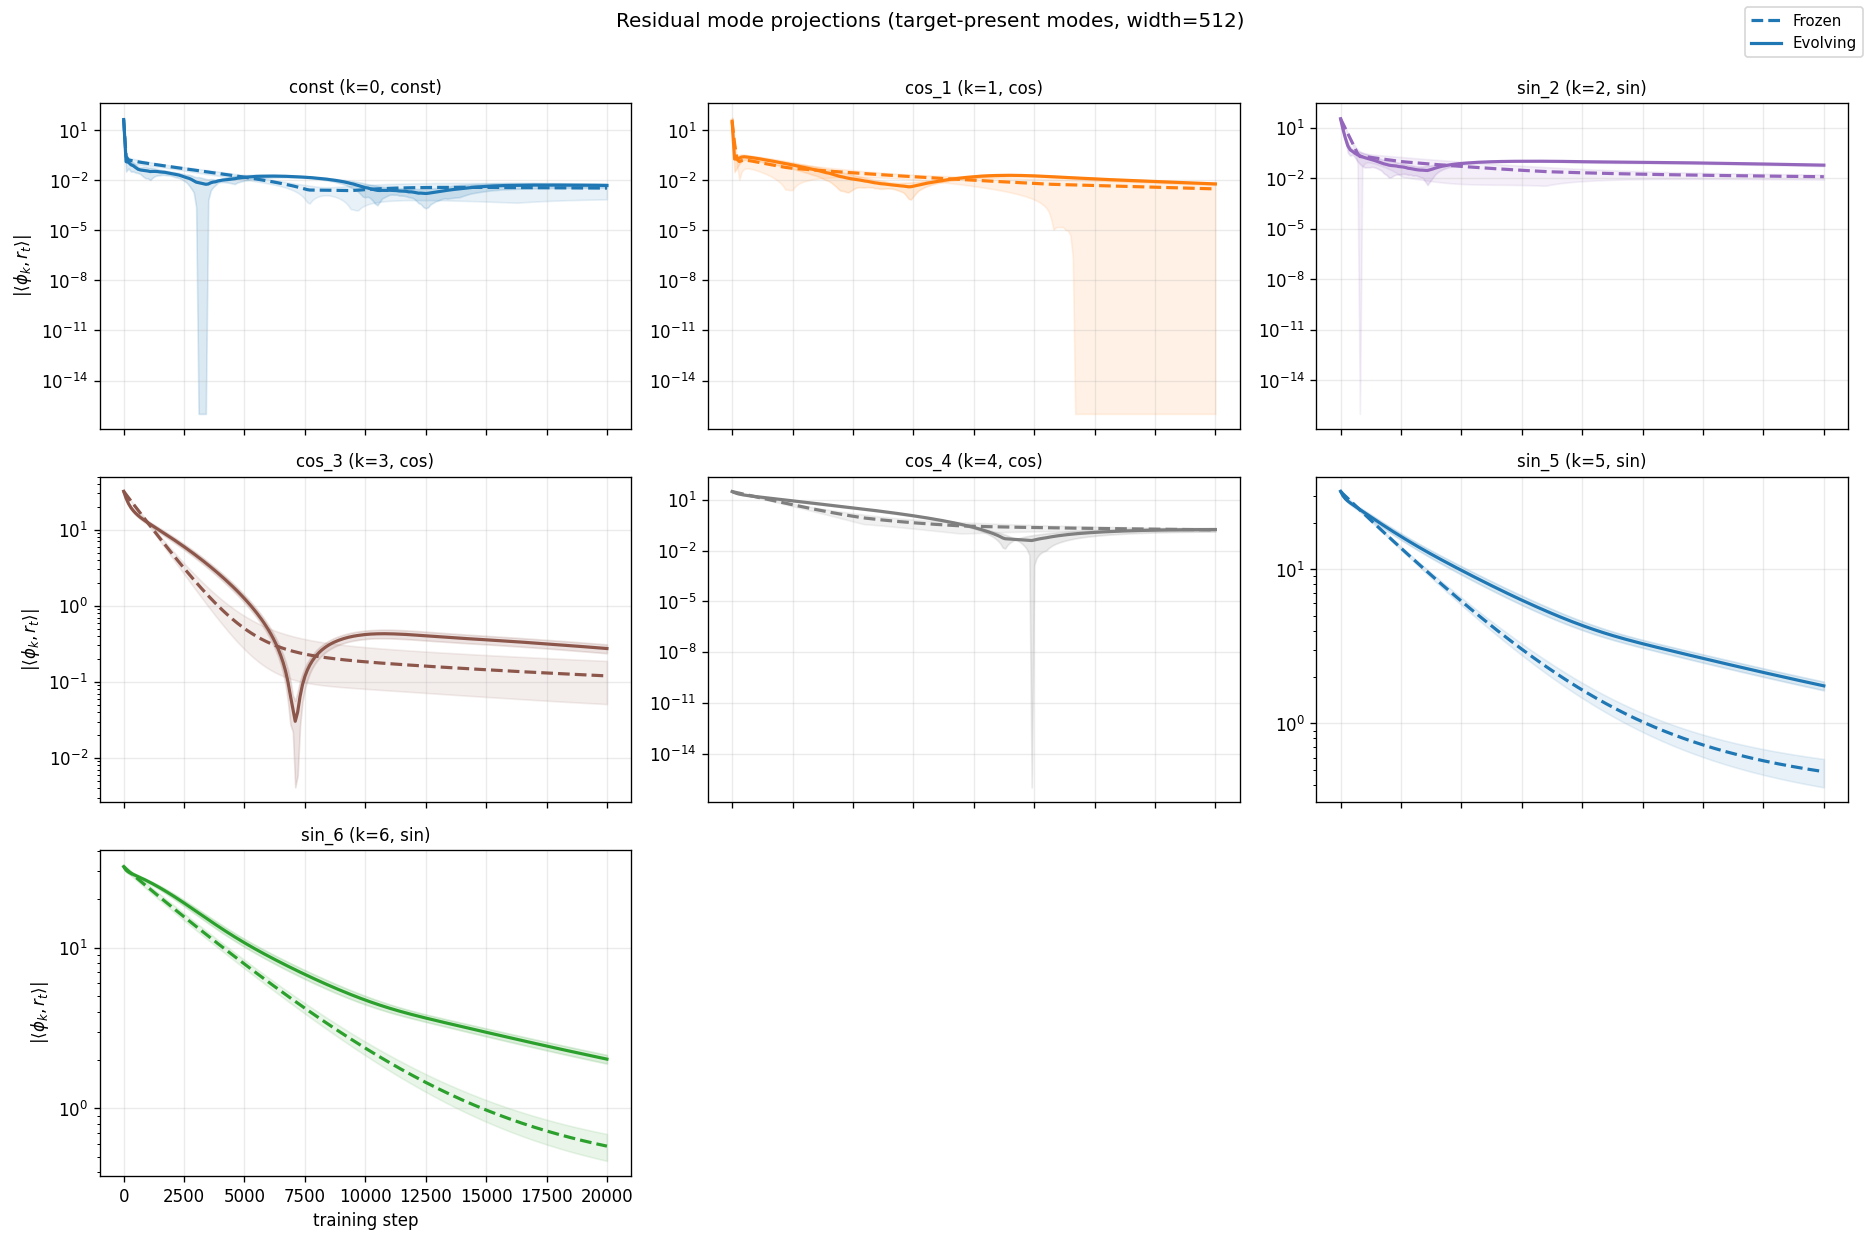

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/mode_projection_side_by_side_target_present_w512.png


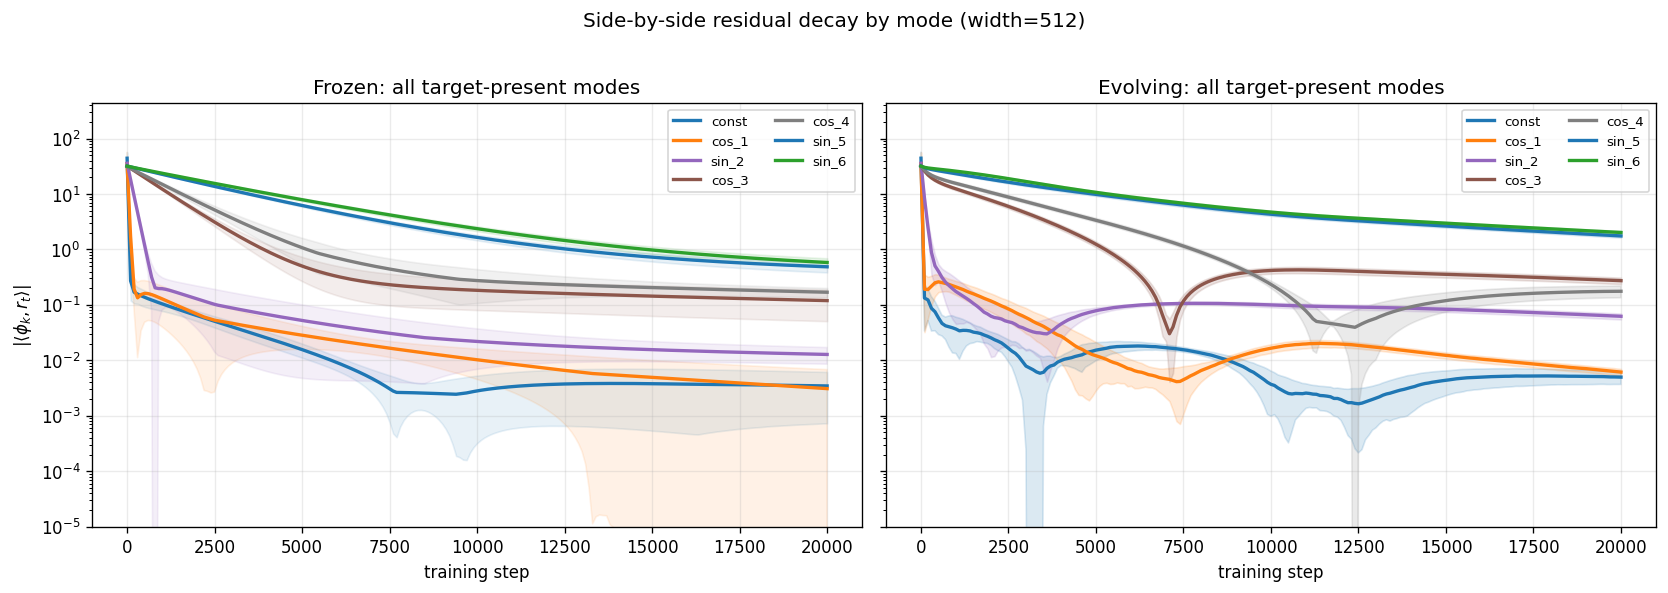

In [7]:
target_ks = np.asarray(manifest['meta'].get('target_Ks', []), dtype=int)
target_amps = np.asarray(manifest['meta'].get('target_amps', []), dtype=float)
target_phases = np.asarray(manifest['meta'].get('target_phases', []), dtype=float)

if not (len(target_ks) == len(target_amps) == len(target_phases)):
    raise ValueError('target_Ks/target_amps/target_phases lengths do not match in manifest meta.')

present_mode_names = set()
PHASE_TOL = 1e-10
AMP_TOL = 1e-10

for k, a, phi in zip(target_ks, target_amps, target_phases):
    k = int(k)
    a = float(a)
    phi = float(phi)

    if abs(a) <= AMP_TOL:
        continue

    if k == 0:
        # f(θ) includes a * cos(phi) constant component for k=0.
        if abs(a * np.cos(phi)) > AMP_TOL:
            present_mode_names.add('const')
        continue

    # a*cos(kθ + phi) = a*cos(phi)*cos(kθ) - a*sin(phi)*sin(kθ)
    coeff_cos = a * np.cos(phi)
    coeff_sin = -a * np.sin(phi)

    if abs(coeff_cos) > AMP_TOL:
        present_mode_names.add(f'cos_{k}')
    if abs(coeff_sin) > AMP_TOL:
        present_mode_names.add(f'sin_{k}')

present_mode_indices = [
    i for i, name in enumerate(tracked_mode_names) if str(name) in present_mode_names
]

if len(present_mode_indices) == 0:
    print('Warning: no target-present tracked modes identified; falling back to all tracked modes.')
    present_mode_indices = list(range(len(tracked_mode_names)))

print('Target-present tracked modes:', [tracked_mode_names[i] for i in present_mode_indices])

# ---------------------------------------------------------------------
# Figure 1: individual trajectories for target-present tracked modes
# ---------------------------------------------------------------------
n_modes_plot = len(present_mode_indices)
n_cols = 3
n_rows = int(np.ceil(n_modes_plot / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.4 * n_rows), sharex=True)
axes = np.asarray(axes).reshape(-1)

for plot_i, mode_i in enumerate(present_mode_indices):
    ax = axes[plot_i]
    mode_name = str(tracked_mode_names[mode_i])
    c = mode_to_color.get(mode_name, default_cycle[plot_i % len(default_cycle)])

    y_f = np.abs(mode_proj_frozen[:, :, mode_i])
    y_e = np.abs(mode_proj_evolving[:, :, mode_i])

    mf, sf = seed_mean_std(y_f)
    me, se = seed_mean_std(y_e)

    ax.plot(snapshot_steps, mf, linewidth=1.9, linestyle='--', color=c, label='Frozen')
    ax.fill_between(snapshot_steps, np.maximum(mf - sf, 1e-16), mf + sf, alpha=0.10, color=c)

    ax.plot(snapshot_steps, me, linewidth=1.9, color=c, label='Evolving')
    ax.fill_between(snapshot_steps, np.maximum(me - se, 1e-16), me + se, alpha=0.16, color=c)

    ax.set_yscale('log')
    ax.set_title(
        f"{mode_name} (k={tracked_mode_freqs[mode_i]}, {tracked_mode_types[mode_i]})",
        fontsize=10,
    )
    ax.grid(True, alpha=0.25)

    if plot_i % n_cols == 0:
        ax.set_ylabel(r'$|\langle \phi_k, r_t \rangle|$')
    if plot_i // n_cols == n_rows - 1:
        ax.set_xlabel('training step')

for j in range(n_modes_plot, len(axes)):
    axes[j].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=9)
fig.suptitle(f'Residual mode projections (target-present modes, width={WIDTH})', y=1.01)
fig.tight_layout()

filename = PLOT_DIR / f'mode_projection_target_present_trajectories_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

# ---------------------------------------------------------------------
# Figure 2: side-by-side overlays (frozen left, evolving right)
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True, sharey=True)
ax_frozen, ax_evolving = axes

for plot_i, mode_i in enumerate(present_mode_indices):
    mode_name = str(tracked_mode_names[mode_i])
    c = mode_to_color.get(mode_name, default_cycle[plot_i % len(default_cycle)])

    y_f = np.abs(mode_proj_frozen[:, :, mode_i])
    y_e = np.abs(mode_proj_evolving[:, :, mode_i])

    mf, sf = seed_mean_std(y_f)
    me, se = seed_mean_std(y_e)

    ax_frozen.plot(snapshot_steps, mf, linewidth=2.0, color=c, label=mode_name)
    ax_frozen.fill_between(snapshot_steps, np.maximum(mf - sf, 1e-16), mf + sf, alpha=0.10, color=c)

    ax_evolving.plot(snapshot_steps, me, linewidth=2.0, color=c, label=mode_name)
    ax_evolving.fill_between(snapshot_steps, np.maximum(me - se, 1e-16), me + se, alpha=0.16, color=c)

ax_frozen.set_title('Frozen: all target-present modes')
ax_evolving.set_title('Evolving: all target-present modes')

for ax in axes:
    ax.set_yscale('log')
    ax.set_ylim(bottom=1e-5)
    ax.set_xlabel('training step')
    ax.grid(True, alpha=0.25)

ax_frozen.set_ylabel(r'$|\langle \phi_k, r_t \rangle|$')
ax_frozen.legend(fontsize=8, ncol=2)
ax_evolving.legend(fontsize=8, ncol=2)

fig.suptitle(f'Side-by-side residual decay by mode (width={WIDTH})', y=1.02)
fig.tight_layout()

filename = PLOT_DIR / f'mode_projection_side_by_side_target_present_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()



## Principal Angles Over Time (Frozen vs Evolving)

We track both principal angles between empirical eigenspace $\hat{F}_k(t)$ and Fourier subspace $F_k$.
Frozen curves are the static baseline; evolving curves show alignment drift over training.


/var/folders/yy/f08jrfk55s3_yrjg0s_jfggc0000gn/T/ipykernel_90738/925408593.py:8: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)
/Users/shreyas/Documents/msc-cs/msc-thesis/code/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/principal_angles_over_training_w512.png


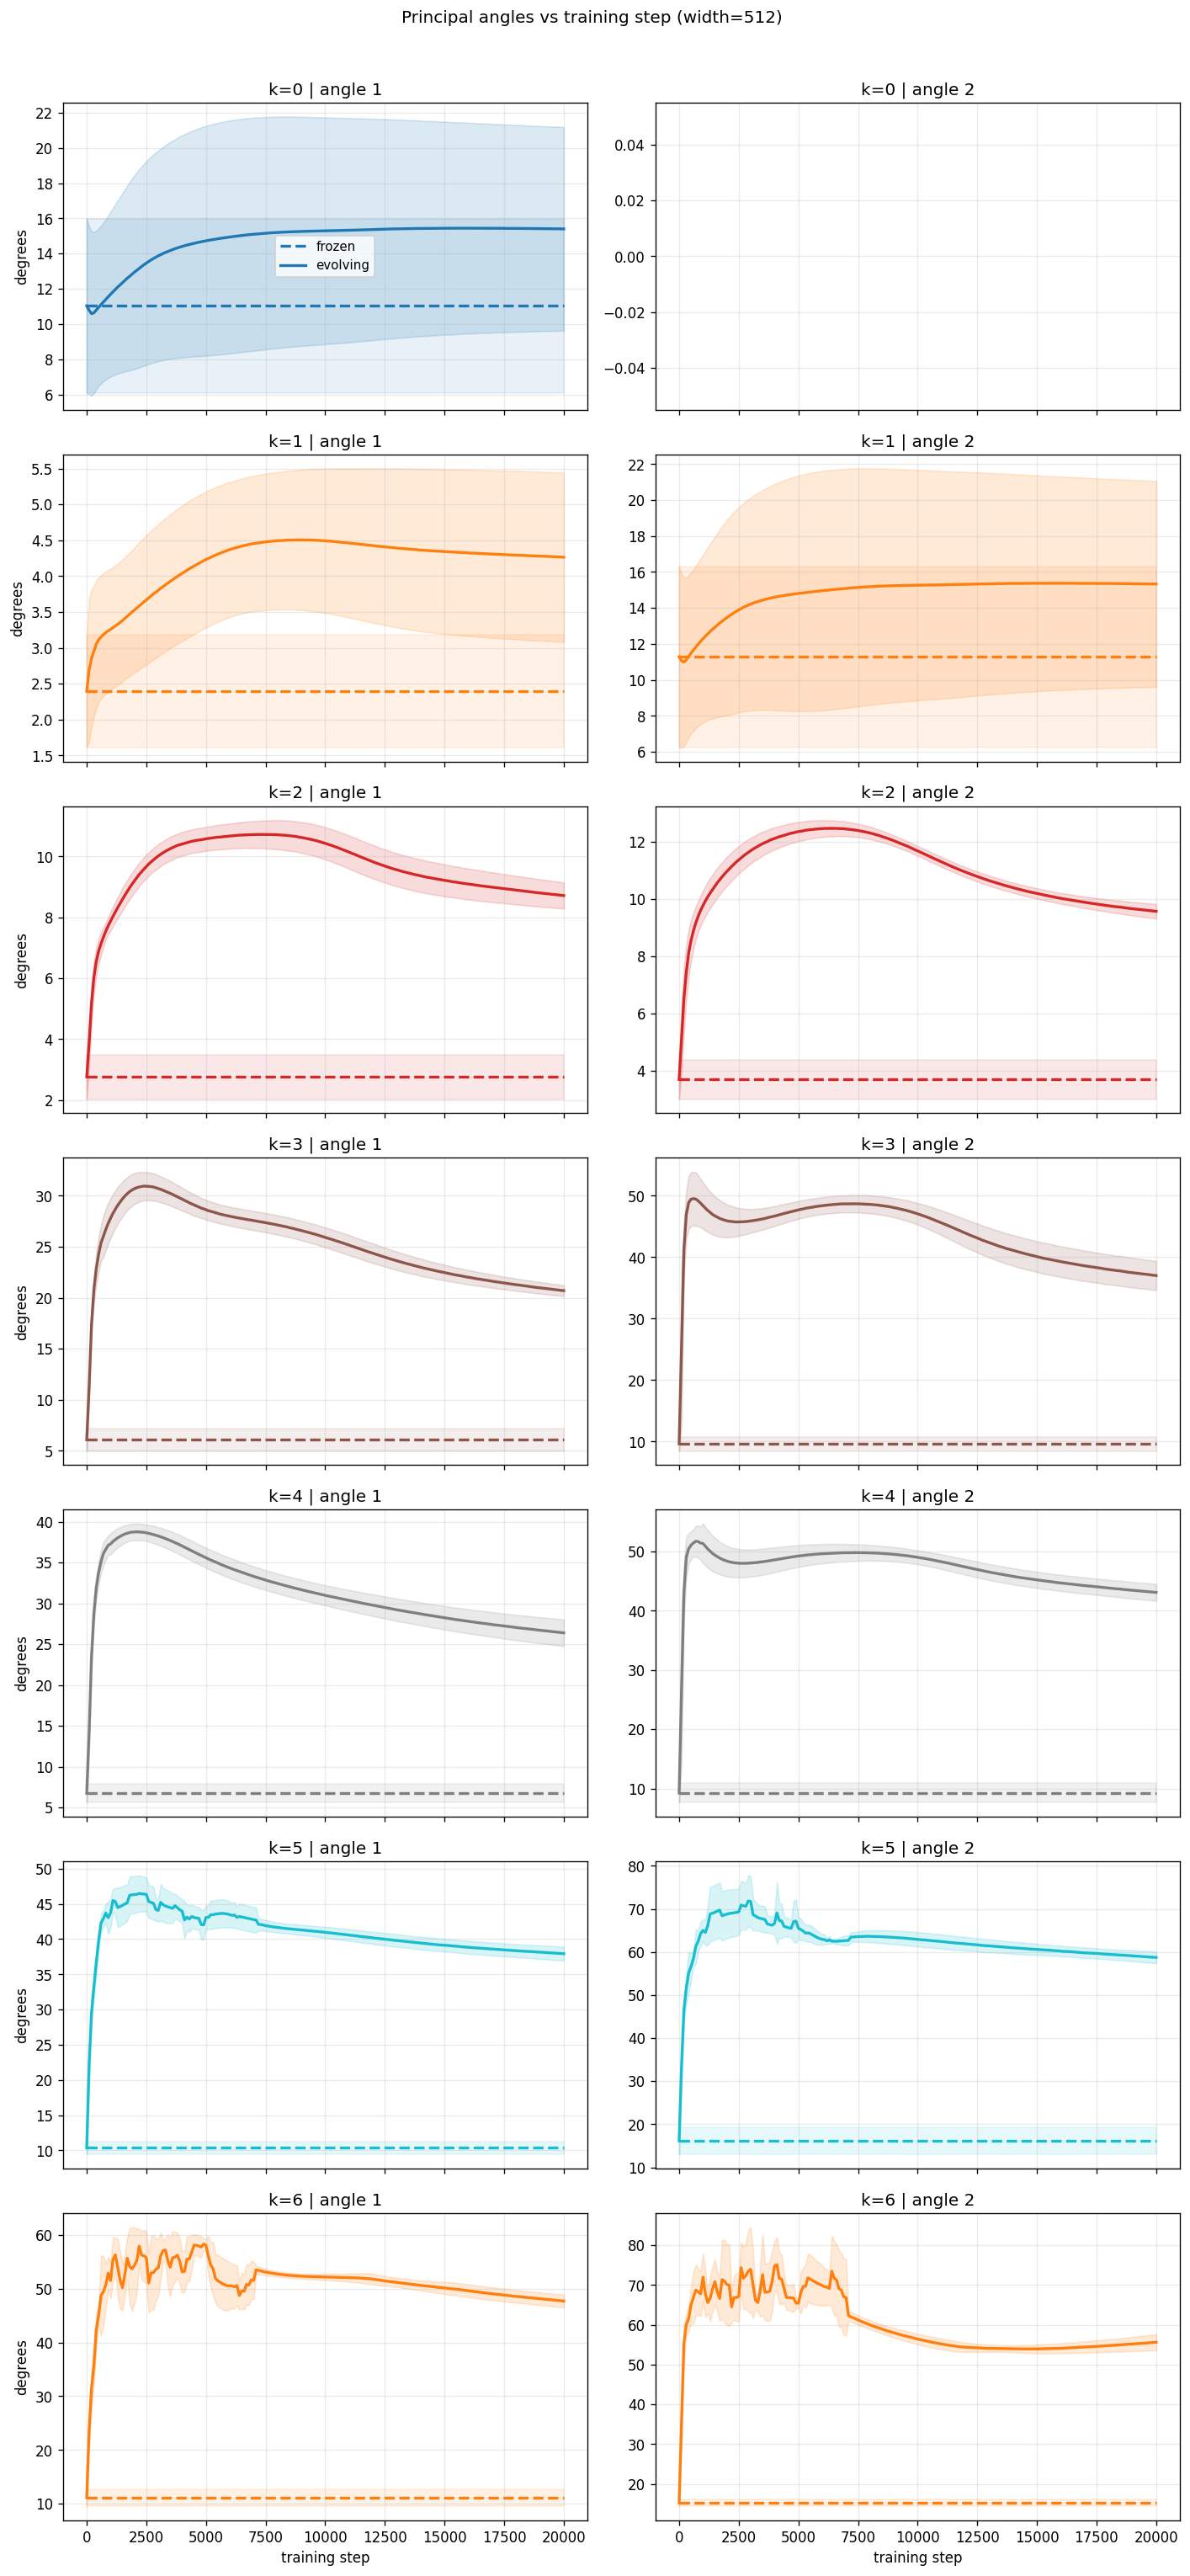

In [8]:
n_freq = len(plane_freqs)
fig, axes = plt.subplots(n_freq, 2, figsize=(12.0, 3.6 * n_freq), sharex=True, sharey=False)
axes = np.asarray(axes)
if n_freq == 1:
    axes = axes[None, :]

for r, k in enumerate(plane_freqs):
    c = freq_to_color.get(int(k), default_cycle[r % len(default_cycle)])
    a1_f = np.rad2deg(plane_angles_frozen[:, :, r, 0])
    a2_f = np.rad2deg(plane_angles_frozen[:, :, r, 1])
    a1_e = np.rad2deg(plane_angles_evolving[:, :, r, 0])
    a2_e = np.rad2deg(plane_angles_evolving[:, :, r, 1])

    m1f, s1f = seed_mean_std(a1_f)
    m2f, s2f = seed_mean_std(a2_f)
    m1e, s1e = seed_mean_std(a1_e)
    m2e, s2e = seed_mean_std(a2_e)

    ax = axes[r, 0]
    ax.plot(snapshot_steps, m1f, linewidth=2.0, linestyle='--', color=c, label='frozen')
    ax.fill_between(snapshot_steps, np.maximum(m1f - s1f, 0.0), m1f + s1f, alpha=0.10, color=c)
    ax.plot(snapshot_steps, m1e, linewidth=2.0, color=c, label='evolving')
    ax.fill_between(snapshot_steps, np.maximum(m1e - s1e, 0.0), m1e + s1e, alpha=0.16, color=c)
    ax.set_title(f'k={int(k)} | angle 1')
    ax.set_ylabel('degrees')
    ax.grid(True, alpha=0.25)

    ax = axes[r, 1]
    ax.plot(snapshot_steps, m2f, linewidth=2.0, linestyle='--', color=c, label='frozen')
    ax.fill_between(snapshot_steps, np.maximum(m2f - s2f, 0.0), m2f + s2f, alpha=0.10, color=c)
    ax.plot(snapshot_steps, m2e, linewidth=2.0, color=c, label='evolving')
    ax.fill_between(snapshot_steps, np.maximum(m2e - s2e, 0.0), m2e + s2e, alpha=0.16, color=c)
    ax.set_title(f'k={int(k)} | angle 2')
    ax.grid(True, alpha=0.25)

for c in range(2):
    axes[-1, c].set_xlabel('training step')

axes[0, 0].legend(fontsize=9)
fig.suptitle(f'Principal angles vs training step (width={WIDTH})', y=1.01)
fig.tight_layout()

filename = PLOT_DIR / f'principal_angles_over_training_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()



## Cosine Alignment Score Over Time

This score summarizes eigenspace-to-Fourier alignment in one number per frequency using
RMS principal-angle cosines (subspace affinity):

$$
s_k^{\mathrm{RMS}}(t)
=
\sqrt{\frac{1}{d_k}\sum_{i=1}^{d_k}\cos^2\theta_{k,i}(t)},
$$

where $d_k$ is the Fourier-subspace dimension for frequency $k$.

- $s_k^{\mathrm{RMS}}(t)\approx 1$ means strong eigenspace-to-Fourier alignment on $F_k$.
- Decrease in $s_k^{\mathrm{RMS}}(t)$ indicates alignment drift.

This is subspace-level (not a single-vector metric), so it is robust to in-subspace rotations/sign flips.


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/eigenspace_alignment_rms_cos_over_time_w512.png


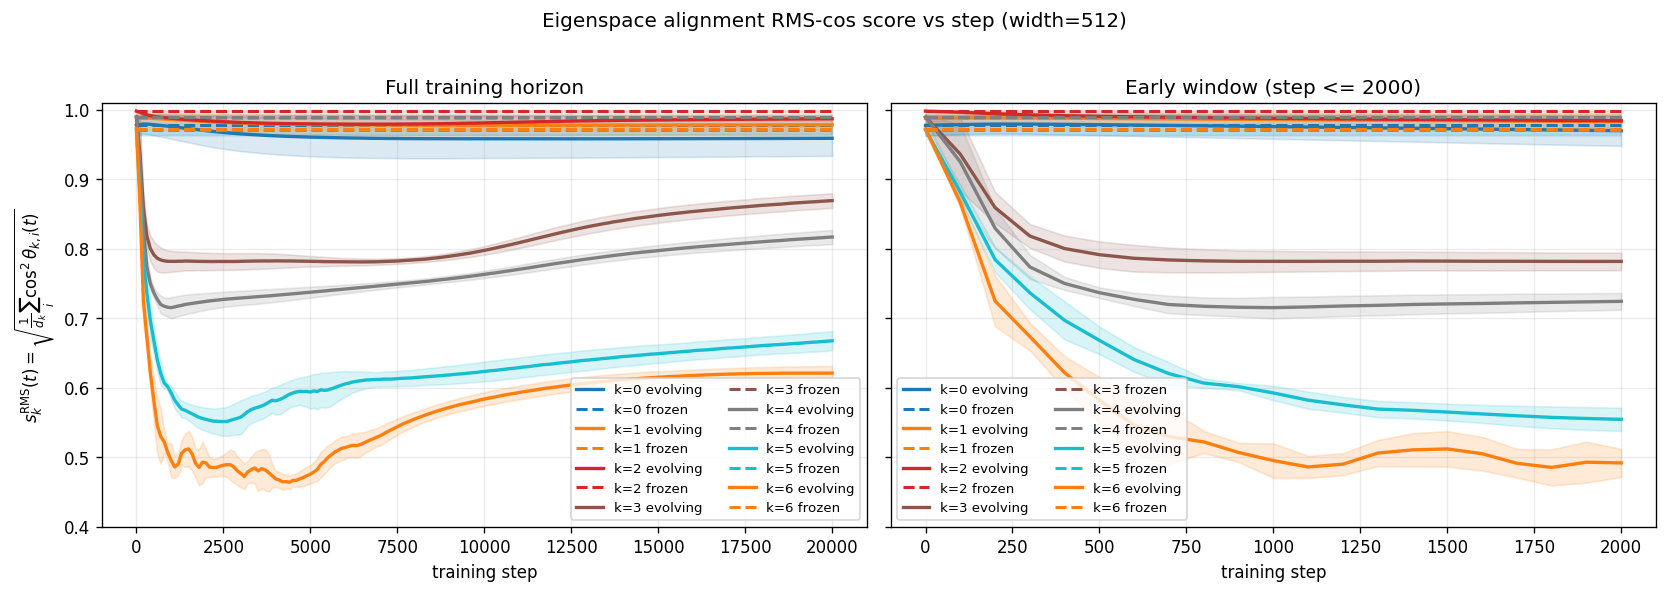

In [9]:
EARLY_MAX_STEP = 2000

# Principal-angle cosines
cos_frozen = np.cos(plane_angles_frozen)      # [seed, T, F, 2]
cos_evolving = np.cos(plane_angles_evolving)  # [seed, T, F, 2]

# RMS cosine subspace affinity over principal angles -> [seed, T, F]
score_frozen = np.sqrt(np.nanmean(cos_frozen**2, axis=3))
score_evolving = np.sqrt(np.nanmean(cos_evolving**2, axis=3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
ax_full, ax_early = axes

for j, k in enumerate(plane_freqs):
    c = freq_to_color.get(int(k), default_cycle[j % len(default_cycle)])
    mf, sf = seed_mean_std(score_frozen[:, :, j])
    me, se = seed_mean_std(score_evolving[:, :, j])

    # Full horizon
    ax_full.plot(snapshot_steps, me, linewidth=2.0, color=c, label=f'k={int(k)} evolving')
    ax_full.fill_between(
        snapshot_steps,
        np.maximum(me - se, 0.0),
        np.minimum(me + se, 1.0),
        alpha=0.16,
        color=c,
    )

    ax_full.plot(snapshot_steps, mf, '--', linewidth=1.8, color=c, label=f'k={int(k)} frozen')
    ax_full.fill_between(
        snapshot_steps,
        np.maximum(mf - sf, 0.0),
        np.minimum(mf + sf, 1.0),
        alpha=0.10,
        color=c,
    )

    # Early-time zoom
    mask = snapshot_steps <= EARLY_MAX_STEP
    ax_early.plot(snapshot_steps[mask], me[mask], linewidth=2.0, color=c, label=f'k={int(k)} evolving')
    ax_early.fill_between(
        snapshot_steps[mask],
        np.maximum(me[mask] - se[mask], 0.0),
        np.minimum(me[mask] + se[mask], 1.0),
        alpha=0.16,
        color=c,
    )

    ax_early.plot(snapshot_steps[mask], mf[mask], '--', linewidth=1.8, color=c, label=f'k={int(k)} frozen')
    ax_early.fill_between(
        snapshot_steps[mask],
        np.maximum(mf[mask] - sf[mask], 0.0),
        np.minimum(mf[mask] + sf[mask], 1.0),
        alpha=0.10,
        color=c,
    )

ax_full.set_title('Full training horizon')
ax_early.set_title(f'Early window (step <= {EARLY_MAX_STEP})')

for ax in axes:
    ax.set_xlabel('training step')
    ax.set_ylim(0.4, 1.01)
    ax.grid(True, alpha=0.25)

ax_full.set_ylabel(r'$s_k^{\mathrm{RMS}}(t)=\sqrt{\frac{1}{d_k}\sum_i\cos^2\theta_{k,i}(t)}$')
ax_full.legend(fontsize=8, ncol=2)
ax_early.legend(fontsize=8, ncol=2)

fig.suptitle(f'Eigenspace alignment RMS-cos score vs step (width={WIDTH})', y=1.02)
fig.tight_layout()

filename = PLOT_DIR / f'eigenspace_alignment_rms_cos_over_time_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()



## Kernel Eigenspace Coordinates (Frozen Static, Evolving Changes)

These are raw eigenspace coordinates $M_{raw}=V^TU$.

Frozen panels are static by construction (kernel fixed). Evolving panels change with training.


In [ ]:
FREQS_TO_SHOW = [int(k) for k in plane_freqs]
TIME_STEPS = keep_existing([0, 2000, 5000, 10000, 20000], snapshot_steps.tolist())
if len(TIME_STEPS) == 0:
    TIME_STEPS = [int(snapshot_steps[0]), int(snapshot_steps[len(snapshot_steps)//2]), int(snapshot_steps[-1])]

n_rows = len(FREQS_TO_SHOW)
n_cols = 1 + len(TIME_STEPS)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.3 * n_cols, 3.6 * n_rows), sharex=True, sharey=True)
axes = np.asarray(axes)
if n_rows == 1:
    axes = axes[None, :]

component_markers = ['o', '^']

for r, k in enumerate(FREQS_TO_SHOW):
    j = plane_idx(k)
    c = freq_to_color.get(int(k), default_cycle[r % len(default_cycle)])

    raw_f = plane_coeff_raw_frozen[:, 0, j, :, :]
    ax = axes[r, 0]
    for comp, marker in enumerate(component_markers):
        ax.scatter(
            raw_f[:, comp, 0], raw_f[:, comp, 1],
            s=30, alpha=0.55, color=c, marker=marker
        )

    ax.axhline(0.0, color='0.75', linewidth=1.0)
    ax.axvline(0.0, color='0.75', linewidth=1.0)
    ax.plot([0, 1], [0, 0], color='black', linewidth=1.1)
    ax.plot([0, 0], [0, 1], color='black', linewidth=1.1)
    ax.set_title(f'k={k} frozen', fontsize=10)
    ax.grid(True, alpha=0.22)
    ax.set_aspect('equal', adjustable='box')

    for c_idx, step in enumerate(TIME_STEPS, start=1):
        t_idx = nearest_step_idx(step)
        raw_e = plane_coeff_raw_evolving[:, t_idx, j, :, :]

        ax = axes[r, c_idx]
        for comp, marker in enumerate(component_markers):
            ax.scatter(
                raw_e[:, comp, 0], raw_e[:, comp, 1],
                s=30, alpha=0.55, color=c, marker=marker
            )

        ax.axhline(0.0, color='0.75', linewidth=1.0)
        ax.axvline(0.0, color='0.75', linewidth=1.0)
        ax.plot([0, 1], [0, 0], color='black', linewidth=1.1)
        ax.plot([0, 0], [0, 1], color='black', linewidth=1.1)
        ax.set_title(f'k={k} step={snapshot_steps[t_idx]}', fontsize=10)
        ax.grid(True, alpha=0.22)
        ax.set_aspect('equal', adjustable='box')

for ax in axes.reshape(-1):
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)

for c_idx in range(n_cols):
    axes[-1, c_idx].set_xlabel(r'$\langle v, \sqrt{2}\cos(k\theta)\rangle$')
for r in range(n_rows):
    axes[r, 0].set_ylabel(r'$\langle v, \sqrt{2}\sin(k\theta)\rangle$')

legend_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='None', color='black', alpha=0.8, label='component 1'),
    plt.Line2D([0], [0], marker='^', linestyle='None', color='black', alpha=0.8, label='component 2'),
]
fig.legend(handles=legend_handles, loc='upper right', fontsize=9)
fig.suptitle(
    f'Kernel eigenspace raw coordinates: frozen vs evolving (width={WIDTH})\n'
    'color=fourier mode frequency, marker=component',
    y=1.02,
)
fig.tight_layout()

filename = PLOT_DIR / f'raw_kernel_eigenspace_grid_frozen_vs_evolving_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()



## Animated Kernel Eigenspace Coordinates

Animation of raw eigenspace coordinates over step:
- frozen points are static reference,
- evolving points update across snapshots.


In [ ]:
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation, PillowWriter

ANIM_FREQS = [int(k) for k in plane_freqs]
ANIM_MAX_FRAMES = 80
FRAME_STRIDE = max(1, len(snapshot_steps) // ANIM_MAX_FRAMES)
FPS = 8
SAVE_GIF = False

frame_indices = list(range(0, len(snapshot_steps), FRAME_STRIDE))
if frame_indices[-1] != len(snapshot_steps) - 1:
    frame_indices.append(len(snapshot_steps) - 1)

n_rows = len(ANIM_FREQS)
fig, axes = plt.subplots(n_rows, 1, figsize=(7.0, 3.8 * n_rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

evolving_scatter = {}
component_markers = ['o', '^']

for r, k in enumerate(ANIM_FREQS):
    j = plane_idx(k)
    c = freq_to_color.get(int(k), default_cycle[r % len(default_cycle)])
    ax = axes[r]

    ax.axhline(0.0, color='0.78', linewidth=1.0)
    ax.axvline(0.0, color='0.78', linewidth=1.0)
    ax.plot([0, 1], [0, 0], color='black', linewidth=1.1)
    ax.plot([0, 0], [0, 1], color='black', linewidth=1.1)

    # frozen reference
    xf1 = plane_coeff_raw_frozen[:, 0, j, 0, 0]
    yf1 = plane_coeff_raw_frozen[:, 0, j, 0, 1]
    xf2 = plane_coeff_raw_frozen[:, 0, j, 1, 0]
    yf2 = plane_coeff_raw_frozen[:, 0, j, 1, 1]

    ax.scatter(xf1, yf1, s=24, alpha=0.28, color=c, marker=component_markers[0])
    ax.scatter(xf2, yf2, s=24, alpha=0.28, color=c, marker=component_markers[1])

    # evolving start frame
    xe1 = plane_coeff_raw_evolving[:, frame_indices[0], j, 0, 0]
    ye1 = plane_coeff_raw_evolving[:, frame_indices[0], j, 0, 1]
    xe2 = plane_coeff_raw_evolving[:, frame_indices[0], j, 1, 0]
    ye2 = plane_coeff_raw_evolving[:, frame_indices[0], j, 1, 1]

    evolving_scatter[(r, 0)] = ax.scatter(xe1, ye1, s=34, alpha=0.88, color=c, marker=component_markers[0])
    evolving_scatter[(r, 1)] = ax.scatter(xe2, ye2, s=34, alpha=0.88, color=c, marker=component_markers[1])

    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.22)
    ax.set_title(f'k={k}')
    ax.set_ylabel(r'$\langle v, \sqrt{2}\sin(k\theta)\rangle$')

axes[-1].set_xlabel(r'$\langle v, \sqrt{2}\cos(k\theta)\rangle$')

step_text = fig.text(0.5, 0.99, '', ha='center', va='top', fontsize=12)

legend_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='None', color='black', alpha=0.9, label='component 1'),
    plt.Line2D([0], [0], marker='^', linestyle='None', color='black', alpha=0.9, label='component 2'),
    plt.Line2D([0], [0], marker='o', linestyle='None', color='black', alpha=0.35, label='frozen alpha'),
    plt.Line2D([0], [0], marker='o', linestyle='None', color='black', alpha=0.9, label='evolving alpha'),
]
fig.legend(handles=legend_handles, loc='upper right', fontsize=9)


def _update(frame_id):
    t_idx = frame_indices[frame_id]
    step = int(snapshot_steps[t_idx])

    artists = []
    for r, k in enumerate(ANIM_FREQS):
        j = plane_idx(k)
        xe1 = plane_coeff_raw_evolving[:, t_idx, j, 0, 0]
        ye1 = plane_coeff_raw_evolving[:, t_idx, j, 0, 1]
        xe2 = plane_coeff_raw_evolving[:, t_idx, j, 1, 0]
        ye2 = plane_coeff_raw_evolving[:, t_idx, j, 1, 1]

        evolving_scatter[(r, 0)].set_offsets(np.c_[xe1, ye1])
        evolving_scatter[(r, 1)].set_offsets(np.c_[xe2, ye2])

        artists.append(evolving_scatter[(r, 0)])
        artists.append(evolving_scatter[(r, 1)])

    step_text.set_text(f'Kernel eigenspace raw coordinates | step={step}')
    artists.append(step_text)
    return artists


anim = FuncAnimation(
    fig,
    _update,
    frames=len(frame_indices),
    interval=int(1000 / FPS),
    blit=False,
)

display(HTML(anim.to_jshtml()))

if SAVE_GIF:
    gif_path = PLOT_DIR / f'kernel_eigenspace_raw_animation_w{WIDTH}.gif'
    anim.save(gif_path, writer=PillowWriter(fps=FPS))
    print(f'Successfully saved {gif_path}')

plt.close(fig)



## Final Prediction Function

We compare final predictions on the dense eval circle against the target function.


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/final_prediction_function_w512.png


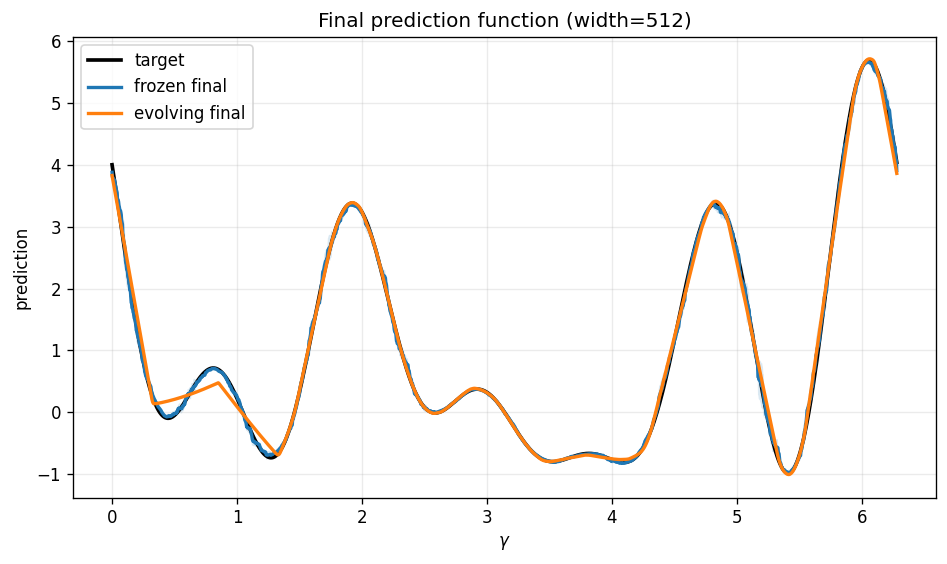

In [10]:
if not has_eval_preds:
    print('Final prediction arrays are not present in this run.')
    print('Rerun with artifacts.save_eval_predictions: true to enable this plot.')
else:
    y_f = pred_eval_frozen[:, -1, :]
    y_e = pred_eval_evolving[:, -1, :]

    mf, sf = seed_mean_std(y_f)
    me, se = seed_mean_std(y_e)

    plt.figure(figsize=(8.0, 4.8))
    plt.plot(gamma_eval, y_eval_true, color='black', linewidth=2.2, label='target')

    plt.plot(gamma_eval, mf, linewidth=2.0, label='frozen final')
    plt.fill_between(gamma_eval, mf - sf, mf + sf, alpha=0.16)

    plt.plot(gamma_eval, me, linewidth=2.0, label='evolving final')
    plt.fill_between(gamma_eval, me - se, me + se, alpha=0.16)

    plt.xlabel(r'$\gamma$')
    plt.ylabel('prediction')
    plt.title(f'Final prediction function (width={WIDTH})')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()

    filename = PLOT_DIR / f'final_prediction_function_w{WIDTH}.png'
    plt.savefig(filename, bbox_inches='tight')
    print(f'Successfully saved {filename}')
    plt.show()



## Numeric Summary at Final Snapshot


In [11]:
print('Final step:', int(snapshot_steps[-1]))

lf = np.mean(train_loss_frozen[:, -1])
le = np.mean(train_loss_evolving[:, -1])
print(f'Final LS objective | frozen={lf:.6e}  evolving={le:.6e}')

mf = np.mean(train_mse_frozen[:, -1])
me = np.mean(train_mse_evolving[:, -1])
print(f'Final train MSE    | frozen={mf:.6e}  evolving={me:.6e}')

print('\nFinal |mode projection| means:')
for i, name in enumerate(tracked_mode_names):
    vf = float(np.mean(np.abs(mode_proj_frozen[:, -1, i])))
    ve = float(np.mean(np.abs(mode_proj_evolving[:, -1, i])))
    print(f'  {name:>6s}: frozen={vf:.4e}  evolving={ve:.4e}')

print('\nFinal projector Frobenius error by plane frequency:')
for j, k in enumerate(plane_freqs):
    pf = float(np.mean(plane_projector_fro_frozen[:, -1, j]))
    pe = float(np.mean(plane_projector_fro_evolving[:, -1, j]))
    print(f'  k={int(k):2d}: frozen={pf:.4f}  evolving={pe:.4f}')



Final step: 20000
Final LS objective | frozen=1.261697e+01  evolving=1.084700e+01
Final train MSE    | frozen=1.232126e-02  evolving=1.059277e-02

Final |mode projection| means:
   const: frozen=3.4552e-03  evolving=4.9822e-03
   cos_1: frozen=3.0885e-03  evolving=6.1395e-03
   sin_1: frozen=5.7174e-03  evolving=2.9854e-03
   cos_2: frozen=1.3169e-02  evolving=2.9542e-02
   sin_2: frozen=1.2772e-02  evolving=6.2310e-02
   cos_3: frozen=1.1946e-01  evolving=2.7354e-01
   sin_3: frozen=2.9639e-02  evolving=9.5681e-02
   cos_4: frozen=1.6917e-01  evolving=1.7616e-01
   sin_4: frozen=2.5692e-02  evolving=3.5020e-01
   cos_5: frozen=3.3264e-02  evolving=4.6519e-02
   sin_5: frozen=4.8708e-01  evolving=1.7539e+00
   cos_6: frozen=9.9391e-02  evolving=1.7062e-01
   sin_6: frozen=5.8239e-01  evolving=2.0244e+00

Final projector Frobenius error by plane frequency:
  k= 0: frozen=0.2698  evolving=0.3738
  k= 1: frozen=0.2824  evolving=0.3873
  k= 2: frozen=0.1139  evolving=0.3182
  k= 3: frozen=

## Cumulative Subspace Alignment and Projection Error ($F_{\leq k}$)

To test whether misalignment is only plane-wise ($F_k$) or persists in larger cumulative
subspaces ($F_{\leq k}$), we construct cumulative diagnostics indexed by increasing
frequency cutoffs.

- If exact `prefix_*` arrays exist in the run artifact, we use them directly.
- Otherwise we use a fallback proxy from existing `plane_*` arrays.

This section shows cumulative alignment and cumulative projection error as separate plots.


Cumulative diagnostics: exact prefix metrics
Alignment source: using prefix_affinity_* from run artifacts
Cumulative frequency order: [0, 1, 2, 3, 4, 5, 6]
Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/cumulative_alignment_exact_w512.png


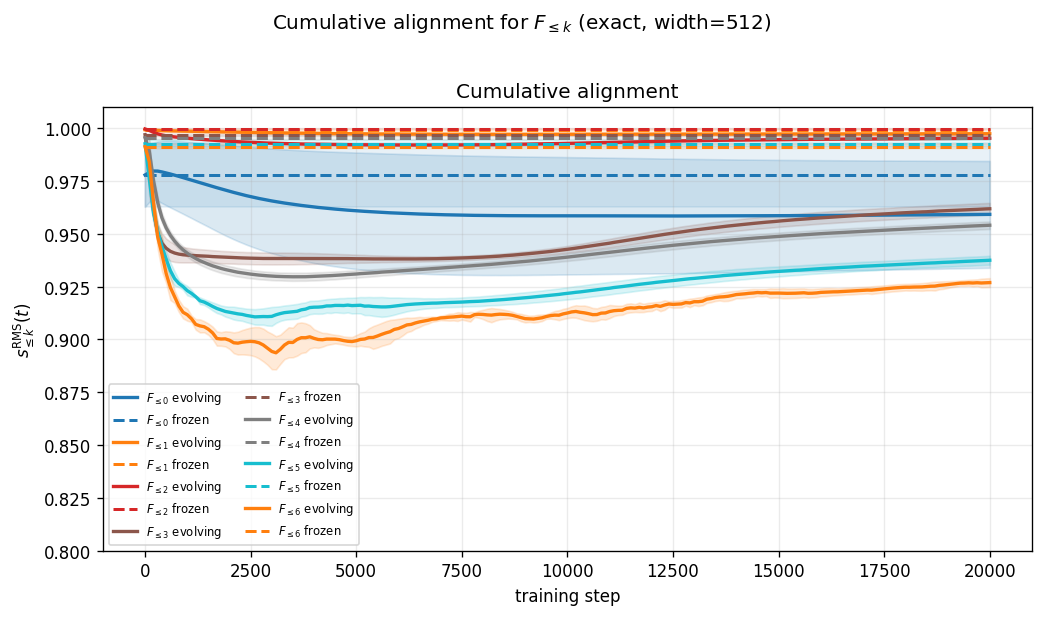

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/cumulative_projection_error_exact_w512.png


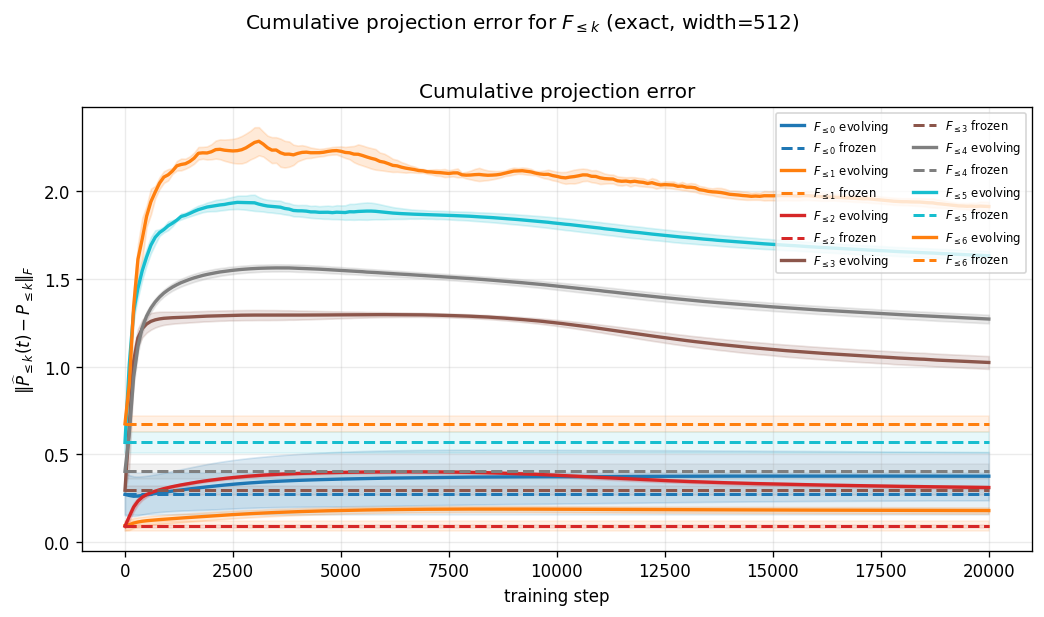

In [12]:
run_keys = set(run.keys())
has_prefix_exact = False
exact_reason = ''

if 'prefix_freqs' in run:
    freqs_sorted = np.asarray(run['prefix_freqs'], dtype=int)
else:
    freqs_sorted = np.asarray(sorted(int(k) for k in plane_freqs), dtype=int)

if {'prefix_affinity_frozen', 'prefix_affinity_evolving'} <= run_keys:
    prefix_aff_f = np.asarray(run['prefix_affinity_frozen'], dtype=float)
    prefix_aff_e = np.asarray(run['prefix_affinity_evolving'], dtype=float)
    has_prefix_exact = True
    exact_reason = 'using prefix_affinity_* from run artifacts'
elif {'prefix_angles_frozen', 'prefix_angles_evolving'} <= run_keys:
    prefix_angles_f = np.asarray(run['prefix_angles_frozen'], dtype=float)
    prefix_angles_e = np.asarray(run['prefix_angles_evolving'], dtype=float)
    prefix_aff_f = np.sqrt(np.nanmean(np.cos(prefix_angles_f) ** 2, axis=3))
    prefix_aff_e = np.sqrt(np.nanmean(np.cos(prefix_angles_e) ** 2, axis=3))
    has_prefix_exact = True
    exact_reason = 'using prefix_angles_* from run artifacts'
else:
    # Fallback proxy from plane-level angles.
    perm = np.asarray([plane_idx(int(k)) for k in freqs_sorted], dtype=int)
    angles_f_sorted = plane_angles_frozen[:, :, perm, :]
    angles_e_sorted = plane_angles_evolving[:, :, perm, :]

    cos2_f = np.cos(angles_f_sorted) ** 2
    cos2_e = np.cos(angles_e_sorted) ** 2
    n_seed, n_snap, n_freq, _ = cos2_f.shape

    prefix_aff_f = np.full((n_seed, n_snap, n_freq), np.nan, dtype=float)
    prefix_aff_e = np.full((n_seed, n_snap, n_freq), np.nan, dtype=float)
    for j in range(n_freq):
        vals_f = cos2_f[:, :, : j + 1, :].reshape(n_seed, n_snap, -1)
        vals_e = cos2_e[:, :, : j + 1, :].reshape(n_seed, n_snap, -1)
        prefix_aff_f[:, :, j] = np.sqrt(np.nanmean(vals_f, axis=2))
        prefix_aff_e[:, :, j] = np.sqrt(np.nanmean(vals_e, axis=2))

    exact_reason = 'fallback proxy from plane_angles_* (RMS over cumulative planes)'

if {'prefix_projector_fro_frozen', 'prefix_projector_fro_evolving'} <= run_keys:
    prefix_eps_f = np.asarray(run['prefix_projector_fro_frozen'], dtype=float)
    prefix_eps_e = np.asarray(run['prefix_projector_fro_evolving'], dtype=float)
else:
    perm = np.asarray([plane_idx(int(k)) for k in freqs_sorted], dtype=int)
    eps_f_sorted = plane_projector_fro_frozen[:, :, perm]
    eps_e_sorted = plane_projector_fro_evolving[:, :, perm]

    n_seed, n_snap, n_freq = eps_f_sorted.shape
    prefix_eps_f = np.full((n_seed, n_snap, n_freq), np.nan, dtype=float)
    prefix_eps_e = np.full((n_seed, n_snap, n_freq), np.nan, dtype=float)
    for j in range(n_freq):
        prefix_eps_f[:, :, j] = np.sqrt(np.nanmean(eps_f_sorted[:, :, : j + 1] ** 2, axis=2))
        prefix_eps_e[:, :, j] = np.sqrt(np.nanmean(eps_e_sorted[:, :, : j + 1] ** 2, axis=2))

# Keep delta arrays for later summary cells.
prefix_delta_f = prefix_eps_f - prefix_eps_f[:, :1, :]
prefix_delta_e = prefix_eps_e - prefix_eps_e[:, :1, :]

print('Cumulative diagnostics:', 'exact prefix metrics' if has_prefix_exact else 'proxy fallback')
print('Alignment source:', exact_reason)
print('Cumulative frequency order:', freqs_sorted.tolist())

# ------------------------------
# Plot 1: cumulative alignment
# ------------------------------
fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))

for j, k in enumerate(freqs_sorted):
    c = freq_to_color.get(int(k), default_cycle[j % len(default_cycle)])
    m_af, s_af = seed_mean_std(prefix_aff_f[:, :, j])
    m_ae, s_ae = seed_mean_std(prefix_aff_e[:, :, j])

    ax.plot(snapshot_steps, m_ae, linewidth=2.0, color=c, label=rf'$F_{{\leq {int(k)}}}$ evolving')
    ax.fill_between(snapshot_steps, np.maximum(m_ae - s_ae, 0.0), np.minimum(m_ae + s_ae, 1.0), alpha=0.16, color=c)

    ax.plot(snapshot_steps, m_af, '--', linewidth=1.8, color=c, label=rf'$F_{{\leq {int(k)}}}$ frozen')
    ax.fill_between(snapshot_steps, np.maximum(m_af - s_af, 0.0), np.minimum(m_af + s_af, 1.0), alpha=0.10, color=c)

ax.set_title('Cumulative alignment')
ax.set_xlabel('training step')
ax.set_ylabel(r'$s_{\leq k}^{\mathrm{RMS}}(t)$')
ax.set_ylim(0.8, 1.01)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=7, ncol=2)

label = 'exact' if has_prefix_exact else 'proxy'
fig.suptitle(f'Cumulative alignment for $F_{{\leq k}}$ ({label}, width={WIDTH})', y=1.02)
fig.tight_layout()

filename = PLOT_DIR / f'cumulative_alignment_{label}_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

# --------------------------------------
# Plot 2: cumulative projection error
# --------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))

for j, k in enumerate(freqs_sorted):
    c = freq_to_color.get(int(k), default_cycle[j % len(default_cycle)])
    m_pf, s_pf = seed_mean_std(prefix_eps_f[:, :, j])
    m_pe, s_pe = seed_mean_std(prefix_eps_e[:, :, j])

    ax.plot(snapshot_steps, m_pe, linewidth=2.0, color=c, label=rf'$F_{{\leq {int(k)}}}$ evolving')
    ax.fill_between(snapshot_steps, np.maximum(m_pe - s_pe, 0.0), m_pe + s_pe, alpha=0.16, color=c)

    ax.plot(snapshot_steps, m_pf, '--', linewidth=1.8, color=c, label=rf'$F_{{\leq {int(k)}}}$ frozen')
    ax.fill_between(snapshot_steps, np.maximum(m_pf - s_pf, 0.0), m_pf + s_pf, alpha=0.10, color=c)

ax.set_title('Cumulative projection error')
ax.set_xlabel('training step')
ax.set_ylabel(r'$\|\widehat P_{\leq k}(t)-P_{\leq k}\|_F$')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=7, ncol=2)

fig.suptitle(f'Cumulative projection error for $F_{{\leq k}}$ ({label}, width={WIDTH})', y=1.02)
fig.tight_layout()

filename = PLOT_DIR / f'cumulative_projection_error_{label}_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()



## Block Drift on Full Tracked Subspace ($C_t$ vs $C_0$)

This section tracks drift of the full tracked Fourier subspace block (all tracked frequencies together),
not cumulative-by-cutoff drift.

Let $C_t$ denote the block operator on this full subspace at step $t$. We plot:
$$\|C_t - C_0\|_F$$
for frozen and evolving branches.


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/full_subspace_block_drift_fro_Ct_minus_C0_full_w512.png


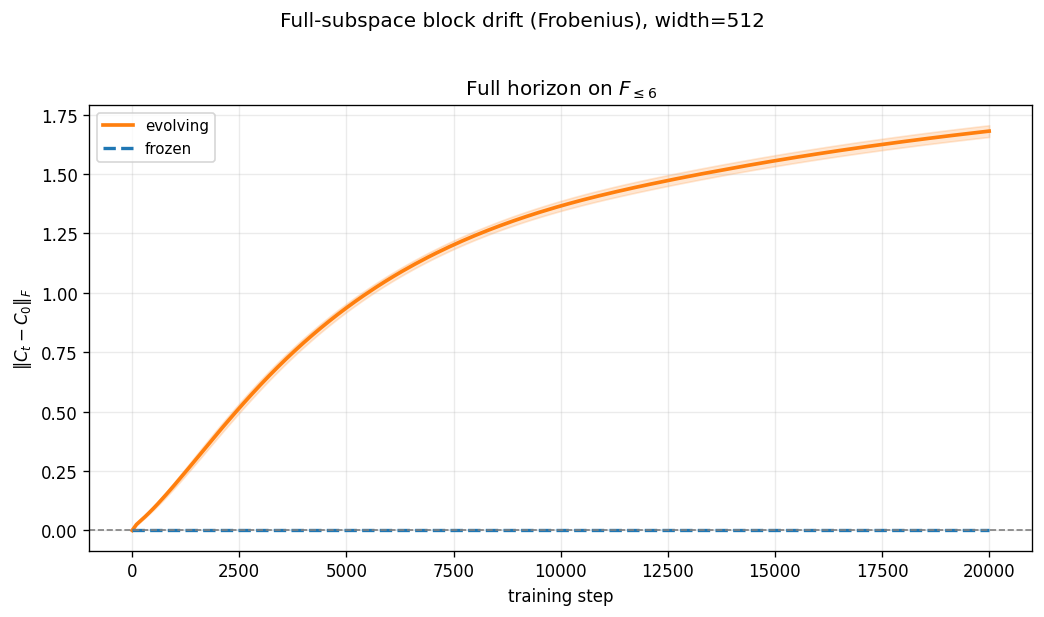

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/full_subspace_block_drift_fro_Ct_minus_C0_early_w512.png


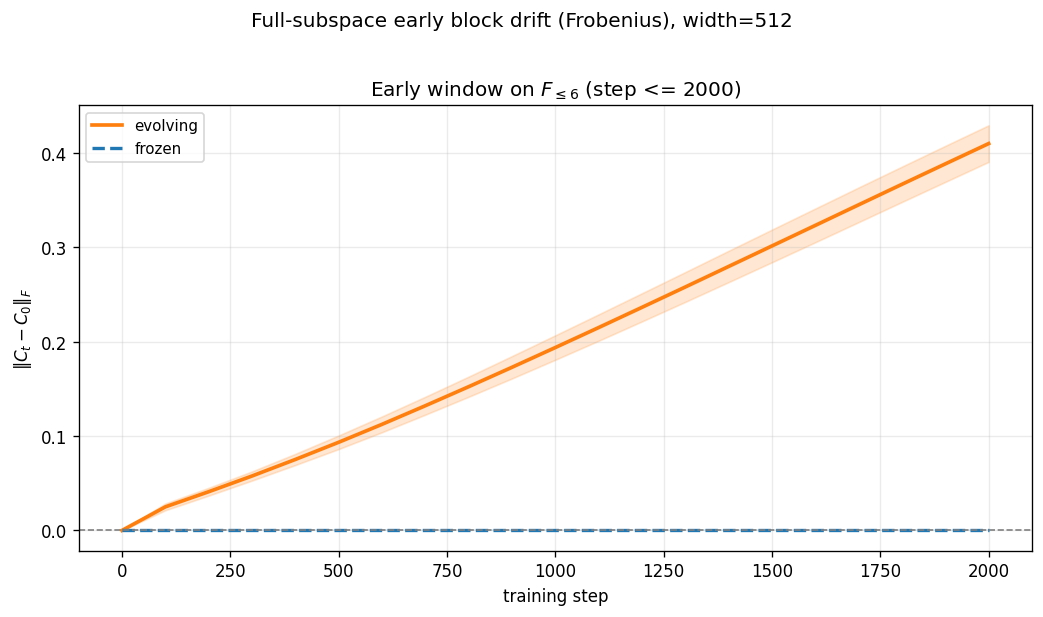

In [13]:
run_keys_ct = set(run.keys())

required_ct_keys = {'prefix_C_t_frozen', 'prefix_C_t_evolving', 'prefix_C_0'}
if not required_ct_keys <= run_keys_ct:
    missing = sorted(required_ct_keys - run_keys_ct)
    raise RuntimeError(
        f'Missing cumulative block keys {missing}. Rerun experiment with latest script.'
    )

C_t_frozen = np.asarray(run['prefix_C_t_frozen'], dtype=float)      # [seed, T, F, D, D]
C_t_evolving = np.asarray(run['prefix_C_t_evolving'], dtype=float)  # [seed, T, F, D, D]
C_0 = np.asarray(run['prefix_C_0'], dtype=float)                    # [seed, F, D, D]

if 'prefix_dims' in run:
    prefix_dims_ct = np.asarray(run['prefix_dims'], dtype=int)
else:
    prefix_dims_ct = np.full((C_0.shape[1],), C_0.shape[2], dtype=int)

if 'prefix_freqs' in run:
    prefix_freqs_ct = np.asarray(run['prefix_freqs'], dtype=int)
else:
    prefix_freqs_ct = np.arange(C_0.shape[1], dtype=int)

j_full = len(prefix_freqs_ct) - 1
d_full = int(prefix_dims_ct[j_full])
k_full = int(prefix_freqs_ct[j_full])

n_seed_ct, n_snap_ct, n_freq_ct, _, _ = C_t_evolving.shape
if C_0.shape[:2] != (n_seed_ct, n_freq_ct):
    raise RuntimeError('Unexpected shape mismatch between prefix_C_t_* and prefix_C_0 arrays.')


def _full_block_drift_fro(C_t_arr, C0_arr, j_cutoff, d_cutoff):
    n_seed, n_snap = C_t_arr.shape[0], C_t_arr.shape[1]
    out = np.full((n_seed, n_snap), np.nan, dtype=float)

    for s in range(n_seed):
        C0_block = C0_arr[s, j_cutoff, :d_cutoff, :d_cutoff]
        for t in range(n_snap):
            delta = C_t_arr[s, t, j_cutoff, :d_cutoff, :d_cutoff] - C0_block
            out[s, t] = np.linalg.norm(delta, ord='fro')

    return out


drift_full_frozen = _full_block_drift_fro(C_t_frozen, C_0, j_full, d_full)
drift_full_evolving = _full_block_drift_fro(C_t_evolving, C_0, j_full, d_full)

mf, sf = seed_mean_std(drift_full_frozen)
me, se = seed_mean_std(drift_full_evolving)

# Plot 1: full horizon
fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))
ax.plot(snapshot_steps, me, linewidth=2.2, color='C1', label='evolving')
ax.fill_between(snapshot_steps, np.maximum(me - se, 0.0), me + se, alpha=0.18, color='C1')
ax.plot(snapshot_steps, mf, '--', linewidth=2.0, color='C0', label='frozen')
ax.fill_between(snapshot_steps, np.maximum(mf - sf, 0.0), mf + sf, alpha=0.12, color='C0')

ax.set_title(rf'Full horizon on $F_{{\leq {k_full}}}$')
ax.set_xlabel('training step')
ax.set_ylabel(r'$\|C_t - C_0\|_F$')
ax.grid(True, alpha=0.25)
ax.axhline(0.0, color='0.5', linestyle='--', linewidth=1.0)
ax.legend(fontsize=9)

fig.suptitle(f'Full-subspace block drift (Frobenius), width={WIDTH}', y=1.02)
fig.tight_layout()

filename = PLOT_DIR / f'full_subspace_block_drift_fro_Ct_minus_C0_full_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

# Plot 2: early window
early_mask = snapshot_steps <= EARLY_MAX_STEP

fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))
ax.plot(snapshot_steps[early_mask], me[early_mask], linewidth=2.2, color='C1', label='evolving')
ax.fill_between(
    snapshot_steps[early_mask],
    np.maximum(me[early_mask] - se[early_mask], 0.0),
    me[early_mask] + se[early_mask],
    alpha=0.18,
    color='C1',
)
ax.plot(snapshot_steps[early_mask], mf[early_mask], '--', linewidth=2.0, color='C0', label='frozen')
ax.fill_between(
    snapshot_steps[early_mask],
    np.maximum(mf[early_mask] - sf[early_mask], 0.0),
    mf[early_mask] + sf[early_mask],
    alpha=0.12,
    color='C0',
)

ax.set_title(rf'Early window on $F_{{\leq {k_full}}}$ (step <= {EARLY_MAX_STEP})')
ax.set_xlabel('training step')
ax.set_ylabel(r'$\|C_t - C_0\|_F$')
ax.grid(True, alpha=0.25)
ax.axhline(0.0, color='0.5', linestyle='--', linewidth=1.0)
ax.legend(fontsize=9)

fig.suptitle(f'Full-subspace early block drift (Frobenius), width={WIDTH}', y=1.02)
fig.tight_layout()

filename = PLOT_DIR / f'full_subspace_block_drift_fro_Ct_minus_C0_early_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()



## Spectral Redistribution in the Tracked Subspace

To quantify how evolving NTK changes spectral strength in the tracked subspace, we use:
$$\mu_{\leq k}(t)=\frac{1}{d_{\leq k}}\operatorname{tr}(C_{\leq k}(t)).$$

Interpretation:
- larger $\mu_{\leq k}(t)$ means stronger average operator strength on that subspace,
- ratio $\mu^{evolving}_{\leq k}(t)/\mu^{frozen}_{\leq k}(t) > 1$ indicates redistribution that amplifies
  learning rates in that subspace relative to the frozen baseline.

This section uses separate plots (no side-by-side subplots).


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/spectral_scale_mu_full_subspace_w512.png


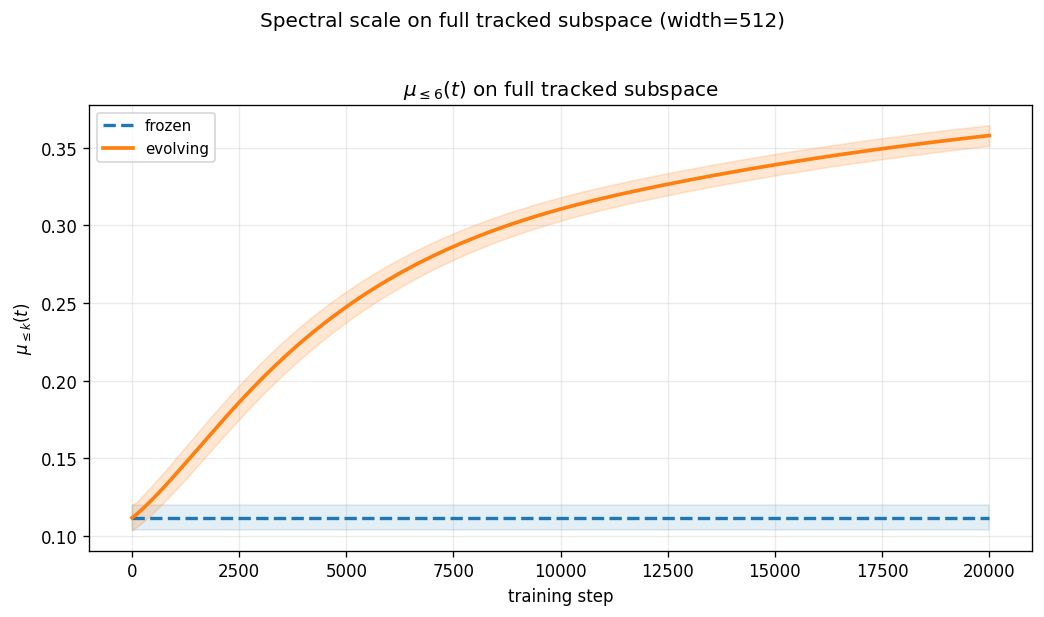

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/spectral_redistribution_ratio_mu_w512.png


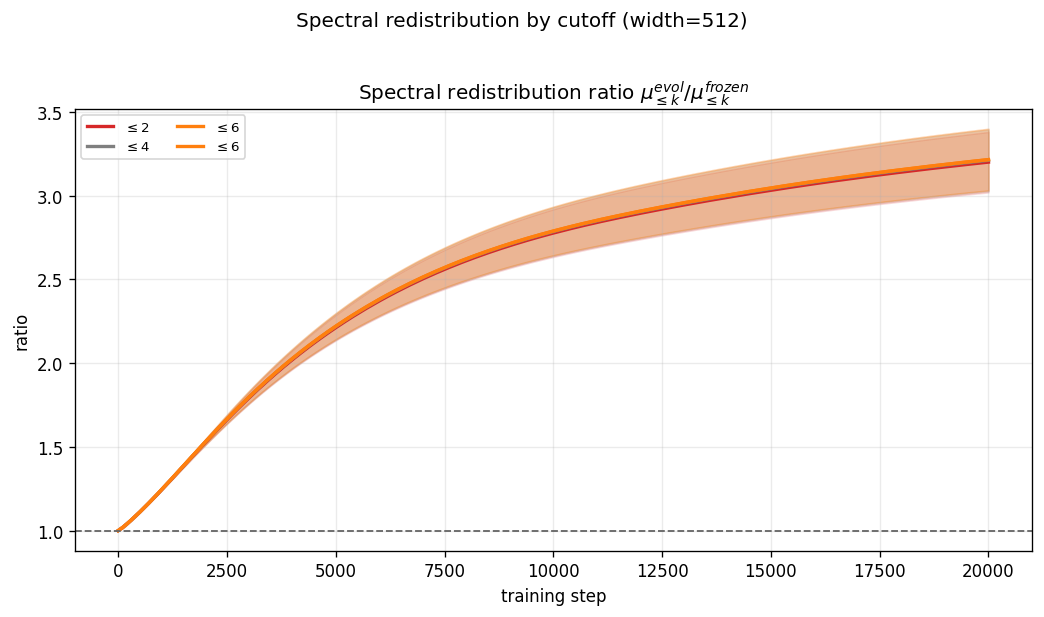

In [14]:
run_keys_mu = set(run.keys())
required_mu_keys = {'prefix_mu_frozen', 'prefix_mu_evolving', 'prefix_freqs'}
if not required_mu_keys <= run_keys_mu:
    missing = sorted(required_mu_keys - run_keys_mu)
    raise RuntimeError(f'Missing spectral redistribution keys {missing}.')

prefix_freqs_mu = np.asarray(run['prefix_freqs'], dtype=int)
mu_f = np.asarray(run['prefix_mu_frozen'], dtype=float)    # [seed, T, F]
mu_e = np.asarray(run['prefix_mu_evolving'], dtype=float)  # [seed, T, F]
mu_ratio = mu_e / np.maximum(mu_f, 1e-12)

cutoffs_to_show = keep_existing([2, 4, 6, int(prefix_freqs_mu[-1])], prefix_freqs_mu.tolist())
if len(cutoffs_to_show) == 0:
    cutoffs_to_show = [int(prefix_freqs_mu[-1])]

# Plot 1: absolute mu on full tracked subspace
j_full_mu = int(np.where(prefix_freqs_mu == int(prefix_freqs_mu[-1]))[0][0])
mf_full, sf_full = seed_mean_std(mu_f[:, :, j_full_mu])
me_full, se_full = seed_mean_std(mu_e[:, :, j_full_mu])

fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))
ax.plot(snapshot_steps, mf_full, '--', linewidth=2.0, color='C0', label='frozen')
ax.fill_between(snapshot_steps, np.maximum(mf_full - sf_full, 0.0), mf_full + sf_full, alpha=0.12, color='C0')
ax.plot(snapshot_steps, me_full, linewidth=2.2, color='C1', label='evolving')
ax.fill_between(snapshot_steps, np.maximum(me_full - se_full, 0.0), me_full + se_full, alpha=0.18, color='C1')

ax.set_title(rf'$\mu_{{\leq {int(prefix_freqs_mu[-1])}}}(t)$ on full tracked subspace')
ax.set_xlabel('training step')
ax.set_ylabel(r'$\mu_{\leq k}(t)$')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=9)

fig.suptitle(f'Spectral scale on full tracked subspace (width={WIDTH})', y=1.02)
fig.tight_layout()

filename = PLOT_DIR / f'spectral_scale_mu_full_subspace_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

# Plot 2: redistribution ratio by cutoff
fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))
for j, k in enumerate(cutoffs_to_show):
    idx = int(np.where(prefix_freqs_mu == int(k))[0][0])
    m, s = seed_mean_std(mu_ratio[:, :, idx])
    c = freq_to_color.get(int(k), default_cycle[j % len(default_cycle)])
    ax.plot(snapshot_steps, m, linewidth=2.0, color=c, label=rf'$\leq {int(k)}$')
    ax.fill_between(snapshot_steps, np.maximum(m - s, 0.0), m + s, alpha=0.16, color=c)

ax.axhline(1.0, color='0.4', linestyle='--', linewidth=1.1)
ax.set_title(r'Spectral redistribution ratio $\mu^{evol}_{\leq k}/\mu^{frozen}_{\leq k}$')
ax.set_xlabel('training step')
ax.set_ylabel('ratio')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, ncol=2)

fig.suptitle(f'Spectral redistribution by cutoff (width={WIDTH})', y=1.02)
fig.tight_layout()

filename = PLOT_DIR / f'spectral_redistribution_ratio_mu_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()



## Cross-Width RMS-Cos Alignment Comparison (128 vs 256 vs 512 vs 1024)

To compare finite-width effects, we overlay the evolving-branch RMS-cos alignment score
for the same target family (`k0256`) across widths 128, 256, 512, and 1024:

$$
s_k^{\mathrm{RMS}}(t)
=
\sqrt{\frac{1}{d_k}\sum_{i=1}^{d_k}\cos^2\theta_{k,i}(t)}.
$$

Higher curves indicate stronger eigenspace-to-Fourier alignment.


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_compare/rms_cos_alignment_over_time_w128_vs_w256_vs_w512_vs_w1024.png


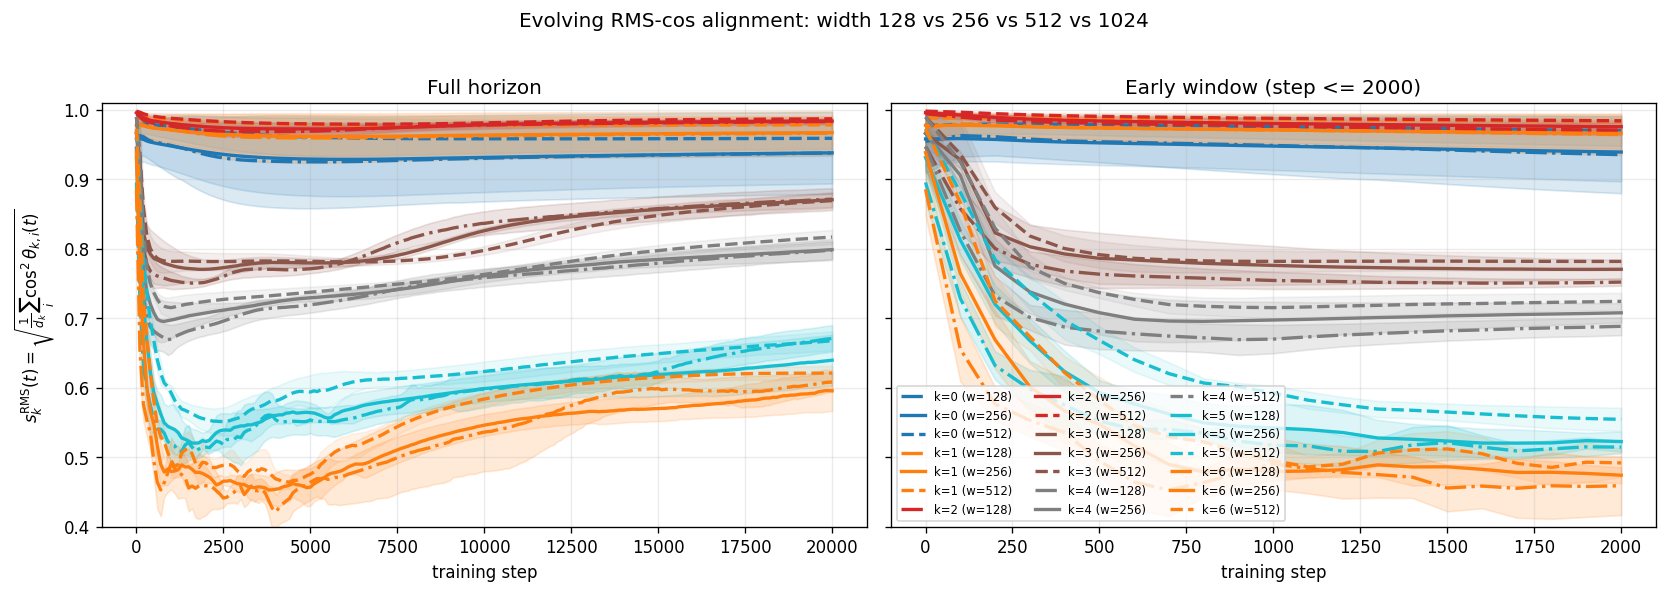

In [15]:
EARLY_MAX_STEP_COMPARE = 2000

EXPERIMENTS = [
    ('128', 'ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w128', '-.'),
    ('256', 'ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w256', '-'),
    ('512', 'ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512', '--'),
    ('1024', 'ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w1024', ':'),
]

runs = {}
for width_label, exp_name, linestyle in EXPERIMENTS:
    run_dir = latest_run_dir(BASE_RESULTS, exp_name)
    if run_dir is None:
        raise FileNotFoundError(f'Could not find latest run for {exp_name}')

    manifest_w = load_manifest(run_dir)
    width_key = sorted([int(w) for w in manifest_w['runs'].keys()])[0]
    run_w = npz(run_dir, manifest_w['runs'][str(width_key)])
    angles = np.asarray(run_w['plane_angles_evolving'], dtype=float)

    runs[width_label] = {
        'exp_name': exp_name,
        'run_dir': run_dir,
        'steps': np.asarray(run_w['snapshot_steps'], dtype=int),
        'freqs': np.asarray(run_w['plane_freqs'], dtype=int),
        'score': np.sqrt(np.nanmean(np.cos(angles) ** 2, axis=3)),
        'linestyle': linestyle,
    }

freqs_ref = runs['128']['freqs']
for width_label in ['256', '512']:#, '1024']:
    if not np.array_equal(freqs_ref, runs[width_label]['freqs']):
        raise ValueError(
            f"plane_freqs mismatch for w={width_label}: {runs[width_label]['freqs'].tolist()} vs {freqs_ref.tolist()}"
        )

freqs = freqs_ref
colors = {int(k): freq_to_color.get(int(k), default_cycle[i % len(default_cycle)]) for i, k in enumerate(freqs)}
fill_alpha = {'128': 0.16, '256': 0.14, '512': 0.09, '1024': 0.05}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
ax_full, ax_early = axes

for j, k in enumerate(freqs):
    c = colors[int(k)]

    for width_label in ['128', '256', '512']:#, '1024']:
        info = runs[width_label]
        m, s = seed_mean_std(info['score'][:, :, j])
        steps = info['steps']
        ls = info['linestyle']
        a = fill_alpha[width_label]

        ax_full.plot(steps, m, color=c, linestyle=ls, linewidth=2.0, label=f'k={int(k)} (w={width_label})')
        ax_full.fill_between(steps, np.maximum(m - s, 0.0), np.minimum(m + s, 1.0), color=c, alpha=a)

        mask = steps <= EARLY_MAX_STEP_COMPARE
        ax_early.plot(steps[mask], m[mask], color=c, linestyle=ls, linewidth=2.0, label=f'k={int(k)} (w={width_label})')
        ax_early.fill_between(steps[mask], np.maximum(m[mask] - s[mask], 0.0), np.minimum(m[mask] + s[mask], 1.0), color=c, alpha=a)

ax_full.set_title('Full horizon')
ax_early.set_title(f'Early window (step <= {EARLY_MAX_STEP_COMPARE})')
for ax in axes:
    ax.set_xlabel('training step')
    ax.set_ylim(0.4, 1.01)
    ax.grid(True, alpha=0.25)

ax_full.set_ylabel(r'$s_k^{\mathrm{RMS}}(t)=\sqrt{\frac{1}{d_k}\sum_i\cos^2\theta_{k,i}(t)}$')
# ax_full.legend(fontsize=7, ncol=3)
ax_early.legend(fontsize=7, ncol=3)

fig.suptitle('Evolving RMS-cos alignment: width 128 vs 256 vs 512 vs 1024', y=1.02)
fig.tight_layout()

compare_plot_dir = ROOT / 'notebooks' / 'plots' / 'ntk_frozen_vs_evolving_mode_dynamics_width_compare'
compare_plot_dir.mkdir(parents=True, exist_ok=True)
filename = compare_plot_dir / 'rms_cos_alignment_over_time_w128_vs_w256_vs_w512_vs_w1024.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()



## Fourier-Plane Projection Error (Absolute)

For each tracked Fourier plane frequency $k$, we plot the absolute projection error
$$\epsilon_k(t):=\|\widehat P_k(t)-P_k\|_F.$$

This directly tracks subspace mismatch over training for frozen and evolving branches.


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w512/projection_error_absolute_over_training_w512.png


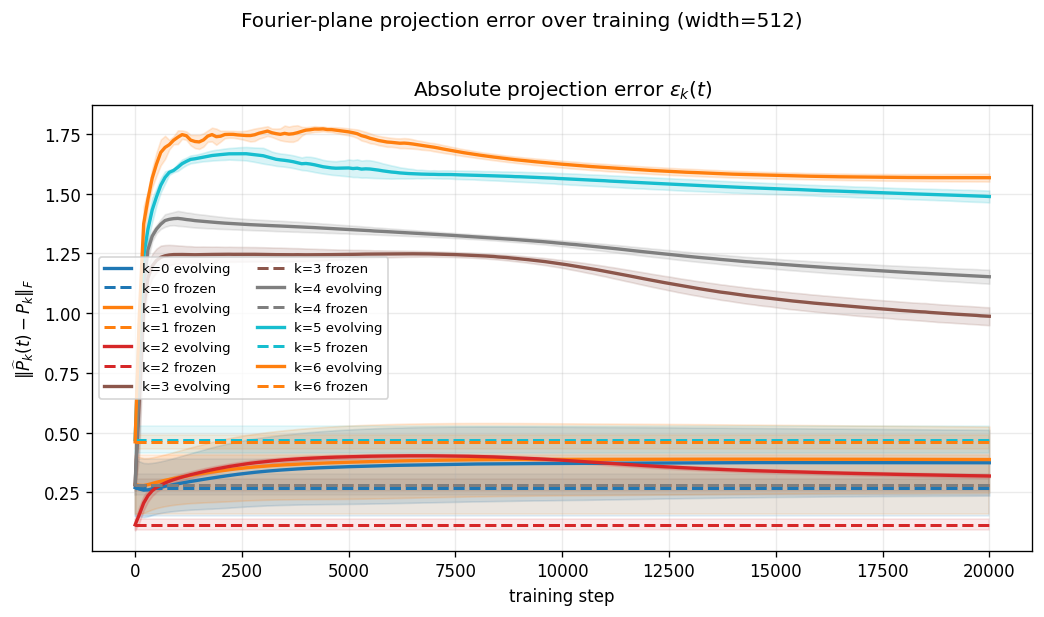

In [16]:
# epsilon_k(t) = ||P_hat_k(t) - P_k||_F
eps_frozen = np.asarray(plane_projector_fro_frozen, dtype=float)
eps_evolving = np.asarray(plane_projector_fro_evolving, dtype=float)

# Keep delta arrays for later summary cells.
delta_eps_evolving = eps_evolving - eps_evolving[:, :1, :]
delta_eps_frozen = eps_frozen - eps_frozen[:, :1, :]

fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.0))

for j, k in enumerate(plane_freqs):
    c = freq_to_color.get(int(k), default_cycle[j % len(default_cycle)])
    mf, sf = seed_mean_std(eps_frozen[:, :, j])
    me, se = seed_mean_std(eps_evolving[:, :, j])

    ax.plot(snapshot_steps, me, linewidth=2.0, color=c, label=f'k={int(k)} evolving')
    ax.fill_between(snapshot_steps, np.maximum(me - se, 0.0), me + se, alpha=0.16, color=c)

    ax.plot(snapshot_steps, mf, '--', linewidth=1.8, color=c, label=f'k={int(k)} frozen')
    ax.fill_between(snapshot_steps, np.maximum(mf - sf, 0.0), mf + sf, alpha=0.10, color=c)

ax.set_title(r'Absolute projection error $\epsilon_k(t)$')
ax.set_xlabel('training step')
ax.set_ylabel(r'$\|\widehat P_k(t)-P_k\|_F$')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, ncol=2)

fig.suptitle(f'Fourier-plane projection error over training (width={WIDTH})', y=1.02)
fig.tight_layout()

filename = PLOT_DIR / f'projection_error_absolute_over_training_w{WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()



## Cross-Run Target/Width Drift Comparison

This section compares projector drift trajectories across selected run families
(different target supports and widths). For each run, we summarize drift by averaging
$\Delta\epsilon_k(t)$ over frequencies tracked in that run's `plane_freqs`.


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_drift_compare/mean_delta_epsilon_cross_runs_k0256_equalamp.png


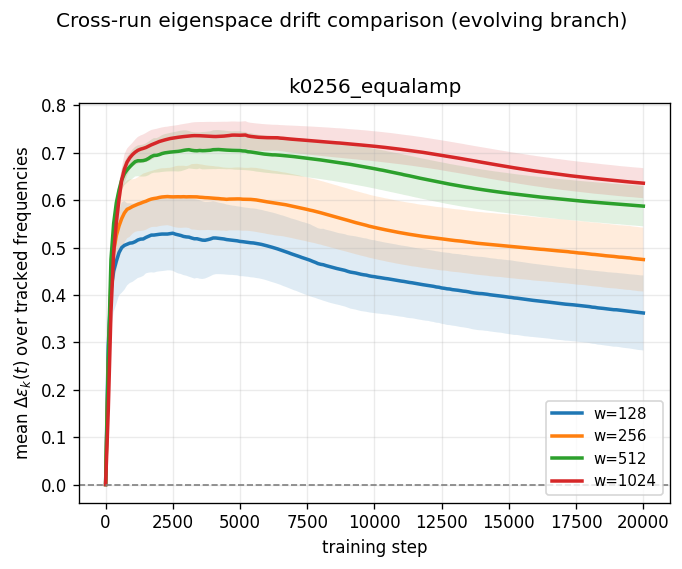

In [17]:
# Update this list if you add new run families
CASE_SPECS = [
    ('k0256_equalamp', 'ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w{w}', [128, 256, 512, 1024]),
]

fig, axes = plt.subplots(1, len(CASE_SPECS), figsize=(5.8 * len(CASE_SPECS), 4.6), sharey=True)
axes = np.atleast_1d(axes)

for ax, (case_name, pattern, widths_case) in zip(axes, CASE_SPECS):
    for w in widths_case:
        exp_name = pattern.format(w=w)
        run_dir_case = latest_run_dir(BASE_RESULTS, exp_name)
        if run_dir_case is None:
            print(f'Skip missing run family: {exp_name}')
            continue

        man_case = load_manifest(run_dir_case)
        w_key = sorted([int(x) for x in man_case['runs'].keys()])[0]
        run_case = npz(run_dir_case, man_case['runs'][str(w_key)])

        steps_case = np.asarray(run_case['snapshot_steps'], dtype=int)
        eps_ev_case = np.asarray(run_case['plane_projector_fro_evolving'], dtype=float)
        delta_case = eps_ev_case - eps_ev_case[:, :1, :]

        # Mean drift across tracked frequencies in this run
        drift_seed = np.mean(delta_case, axis=2)
        m, s = seed_mean_std(drift_seed)
        ax.plot(steps_case, m, linewidth=2.1, label=f'w={w}')
        ax.fill_between(steps_case, m - s, m + s, alpha=0.14)

    ax.axhline(0.0, color='0.5', linestyle='--', linewidth=1.0)
    ax.set_title(case_name)
    ax.set_xlabel('training step')
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel(r'mean $\Delta\epsilon_k(t)$ over tracked frequencies')
axes[0].legend(fontsize=9)
fig.suptitle('Cross-run eigenspace drift comparison (evolving branch)', y=1.02)
fig.tight_layout()

compare_plot_dir = ROOT / 'notebooks' / 'plots' / 'ntk_frozen_vs_evolving_mode_drift_compare'
compare_plot_dir.mkdir(parents=True, exist_ok=True)
filename = compare_plot_dir / 'mean_delta_epsilon_cross_runs_k0256_equalamp.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()



## Interpretation: Single-Plane vs Cumulative Misalignment

This cell gives a compact, data-driven interpretation of the two core questions using
final and early-time alignment/drift summaries.


In [18]:
def _final_mean(x):
    return float(np.nanmean(np.asarray(x, dtype=float)[:, -1]))


def _early_drop(score_arr, step_max=EARLY_MAX_STEP):
    # score_arr: [seed, T]
    m = np.nanmean(np.asarray(score_arr, dtype=float), axis=0)
    mask = snapshot_steps <= int(step_max)
    if not np.any(mask):
        return np.nan
    vals = m[mask]
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.nan
    return float(vals[0] - np.nanmin(vals))


# Per-plane evolving summaries (single F_k)
plane_score_e = score_evolving
plane_delta_e = delta_eps_evolving

plane_rows = []
for j, k in enumerate(plane_freqs):
    plane_rows.append({
        'k': int(k),
        'final_align': _final_mean(plane_score_e[:, :, j]),
        'early_drop': _early_drop(plane_score_e[:, :, j], step_max=EARLY_MAX_STEP),
        'final_drift': _final_mean(plane_delta_e[:, :, j]),
    })

# Cumulative evolving summaries (F_{<=k}) from exact or proxy arrays computed above
cum_rows = []
for j, k in enumerate(freqs_sorted):
    cum_rows.append({
        'k': int(k),
        'final_align': _final_mean(prefix_aff_e[:, :, j]),
        'early_drop': _early_drop(prefix_aff_e[:, :, j], step_max=EARLY_MAX_STEP),
        'final_drift': _final_mean(prefix_delta_e[:, :, j]),
    })

# Frozen-vs-evolving cumulative gap at final step
cum_gap_rows = []
for j, k in enumerate(freqs_sorted):
    align_f = _final_mean(prefix_aff_f[:, :, j])
    align_e = _final_mean(prefix_aff_e[:, :, j])
    drift_f = _final_mean(prefix_delta_f[:, :, j])
    drift_e = _final_mean(prefix_delta_e[:, :, j])
    cum_gap_rows.append({
        'k': int(k),
        'align_gap_f_minus_e': align_f - align_e,
        'drift_gap_e_minus_f': drift_e - drift_f,
    })

print('=== Interpretation metrics (evolving branch) ===')
print(f'Cumulative source: {"exact prefix" if has_prefix_exact else "proxy fallback"}')
print('')
print('Per-plane F_k (single-frequency) at final step:')
for row in plane_rows:
    print(
        f"  k={row['k']:2d} | final_align={row['final_align']:.4f} "
        f"early_drop={row['early_drop']:.4f} final_drift={row['final_drift']:.4f}"
    )

print('')
print('Cumulative F_{<=k} at final step:')
for row in cum_rows:
    print(
        f"  <= {row['k']:2d} | final_align={row['final_align']:.4f} "
        f"early_drop={row['early_drop']:.4f} final_drift={row['final_drift']:.4f}"
    )

print('')
print('Frozen-vs-evolving cumulative gaps at final step:')
for row in cum_gap_rows:
    print(
        f"  <= {row['k']:2d} | align(frozen-evolving)={row['align_gap_f_minus_e']:+.4f} "
        f"drift(evolving-frozen)={row['drift_gap_e_minus_f']:+.4f}"
    )

# Compact text answer to the two research questions
plane_valid = [r for r in plane_rows if np.isfinite(r['final_align'])]
cum_valid = [r for r in cum_rows if np.isfinite(r['final_align'])]
gap_valid = [r for r in cum_gap_rows if np.isfinite(r['align_gap_f_minus_e'])]

print('=== Direct answers ===')
if cum_valid:
    worst_cum = min(cum_valid, key=lambda r: r['final_align'])
    print(
        '1) Single-frequency vs cumulative misalignment: '
        f"misalignment is not confined to one plane only; cumulative alignment over F_<=k "
        f"also drops (worst cumulative at <= {worst_cum['k']} with final align {worst_cum['final_align']:.4f})."
    )
else:
    print('1) Single-frequency vs cumulative misalignment: insufficient finite cumulative data in this run.')

if gap_valid:
    largest_cum_gap = max(gap_valid, key=lambda r: r['align_gap_f_minus_e'])
    print(
        '2) Why frozen often performs better: '
        f"frozen keeps higher cumulative alignment and lower cumulative drift; "
        f"largest final cumulative alignment advantage is at <= {largest_cum_gap['k']} "
        f"(gap {largest_cum_gap['align_gap_f_minus_e']:+.4f}), consistent with better-conditioned residual dynamics."
    )
else:
    print('2) Why frozen often performs better: insufficient finite frozen/evolving gap data in this run.')

if not has_prefix_exact:
    print('Note: cumulative values above are labeled as proxies from plane_* metrics because prefix_* exact arrays are unavailable in this run.')



=== Interpretation metrics (evolving branch) ===
Cumulative source: exact prefix

Per-plane F_k (single-frequency) at final step:
  k= 0 | final_align=0.9592 early_drop=0.0077 final_drift=0.1040
  k= 1 | final_align=0.9786 early_drop=0.0048 final_drift=0.1049
  k= 2 | final_align=0.9873 early_drop=0.0139 final_drift=0.2043
  k= 3 | final_align=0.8695 early_drop=0.2081 final_drift=0.7056
  k= 4 | final_align=0.8170 early_drop=0.2744 final_drift=0.8705
  k= 5 | final_align=0.6677 early_drop=0.4169 final_drift=1.0176
  k= 6 | final_align=0.6211 early_drop=0.4876 final_drift=1.1057

Cumulative F_{<=k} at final step:
  <=  0 | final_align=0.9592 early_drop=0.0077 final_drift=0.1040
  <=  1 | final_align=0.9973 early_drop=0.0011 final_drift=0.0862
  <=  2 | final_align=0.9952 early_drop=0.0058 final_drift=0.2210
  <=  3 | final_align=0.9618 early_drop=0.0581 final_drift=0.7297
  <=  4 | final_align=0.9540 early_drop=0.0629 final_drift=0.8700
  <=  5 | final_align=0.9375 early_drop=0.0797 fin

## Width-Stacked Side-by-Side Residual Decay

This section generates one figure per width (not subplots across widths).
Each figure has two panels:
- left: frozen decay of target-present modes,
- right: evolving decay of target-present modes.


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/side_by_side_residual_decay_equalamp_w128.png


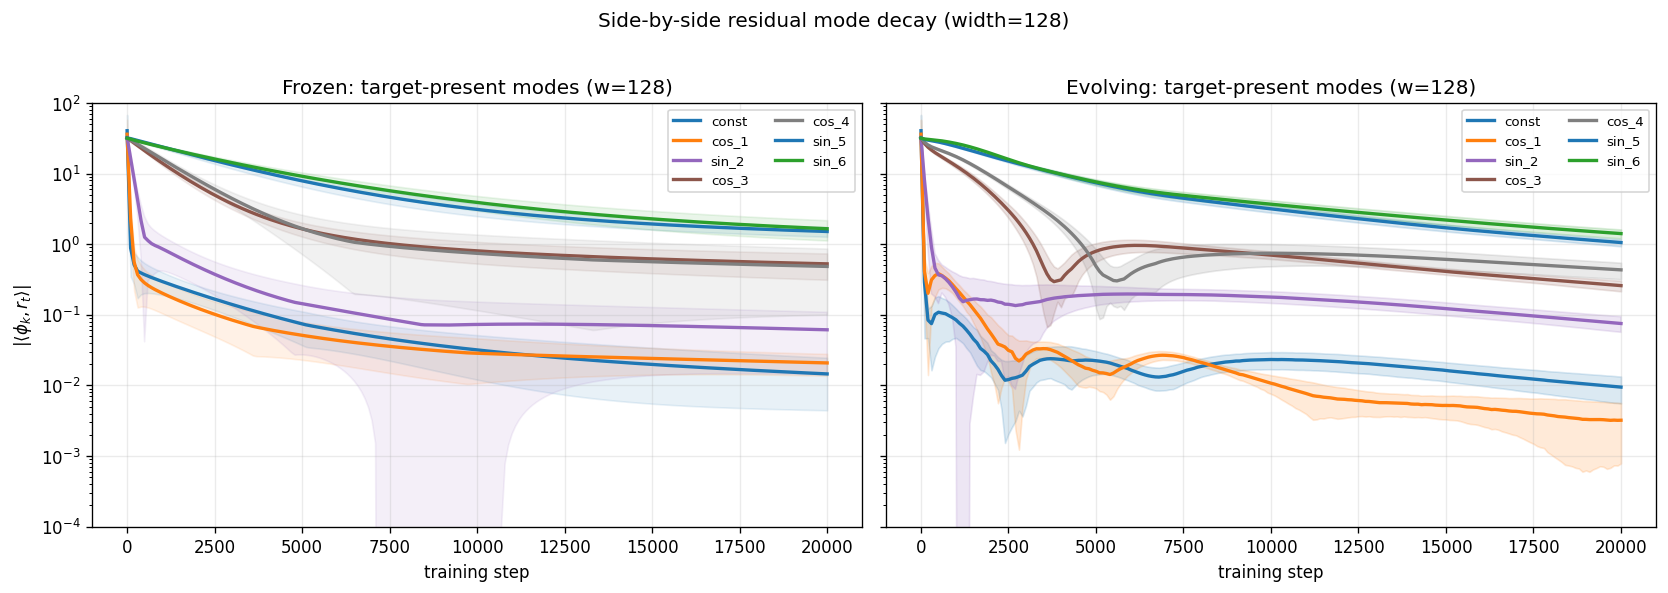

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/side_by_side_residual_decay_equalamp_w256.png


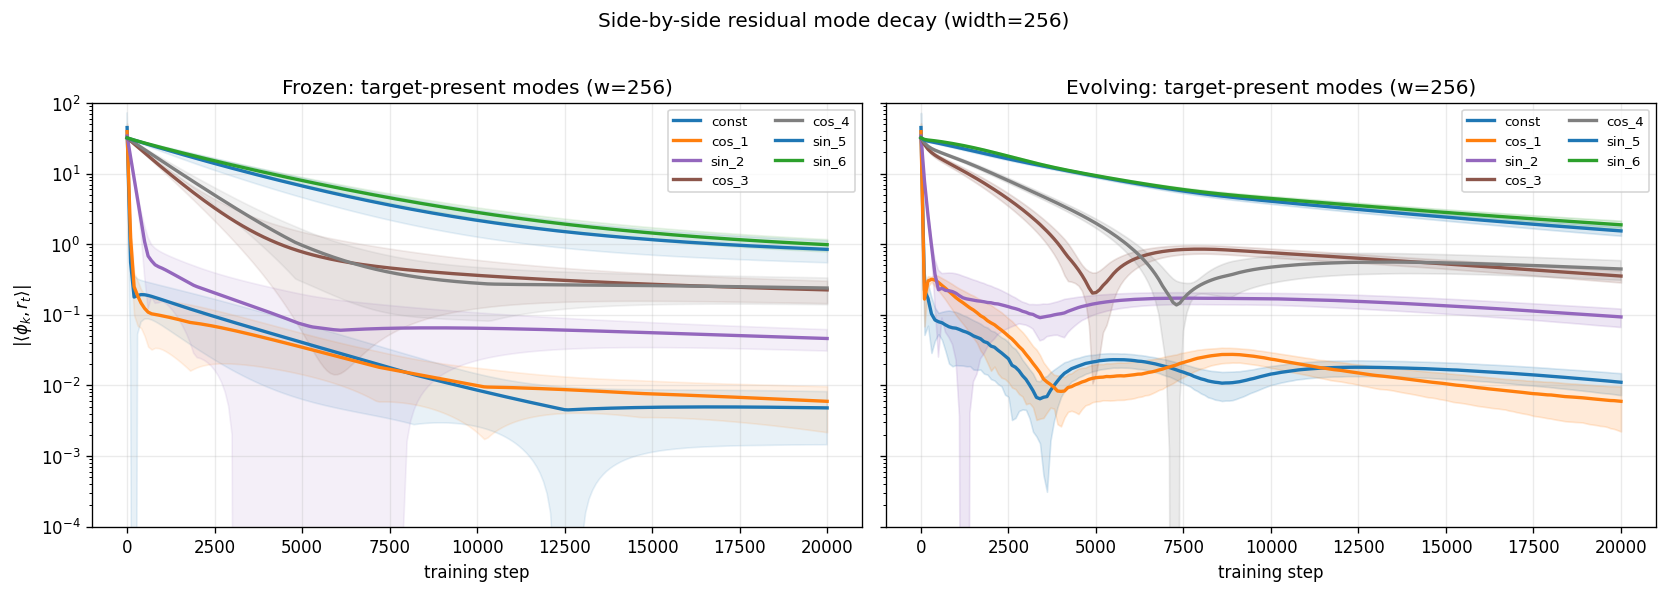

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/side_by_side_residual_decay_equalamp_w512.png


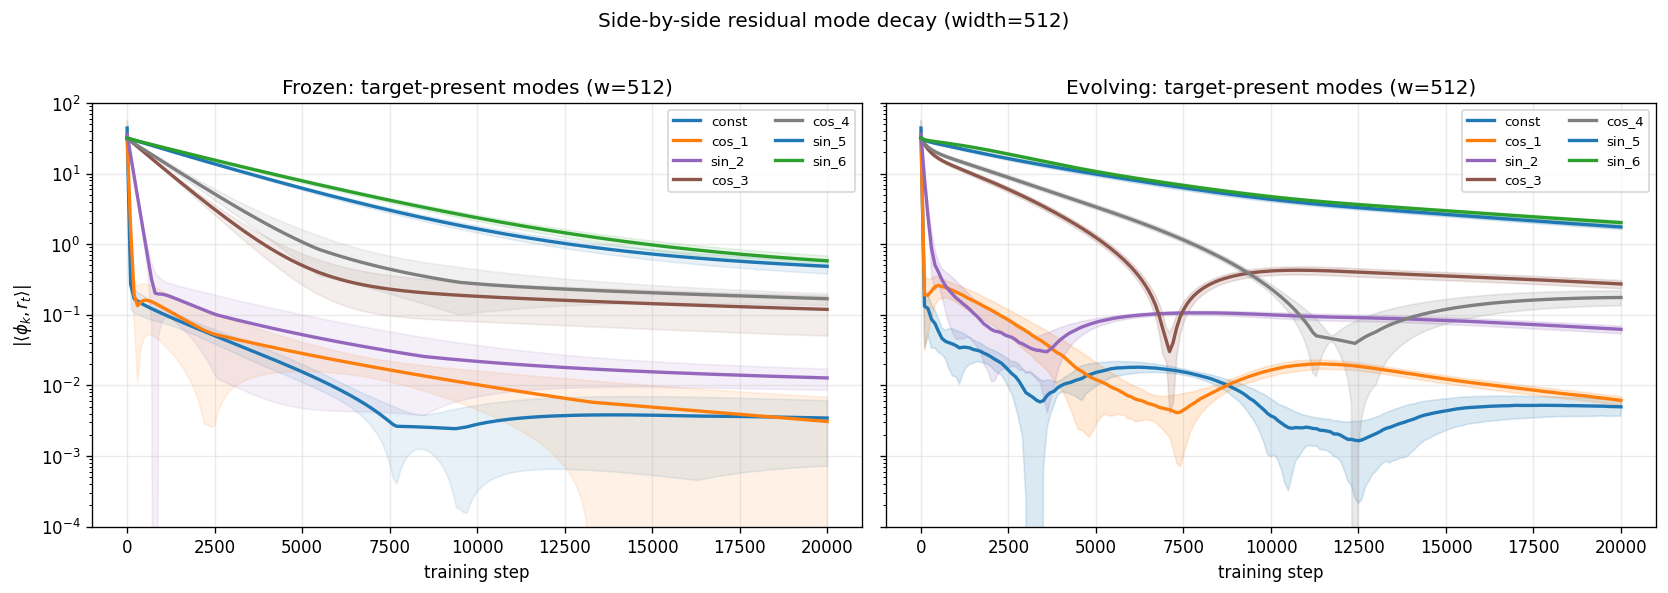

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/side_by_side_residual_decay_equalamp_w1024.png


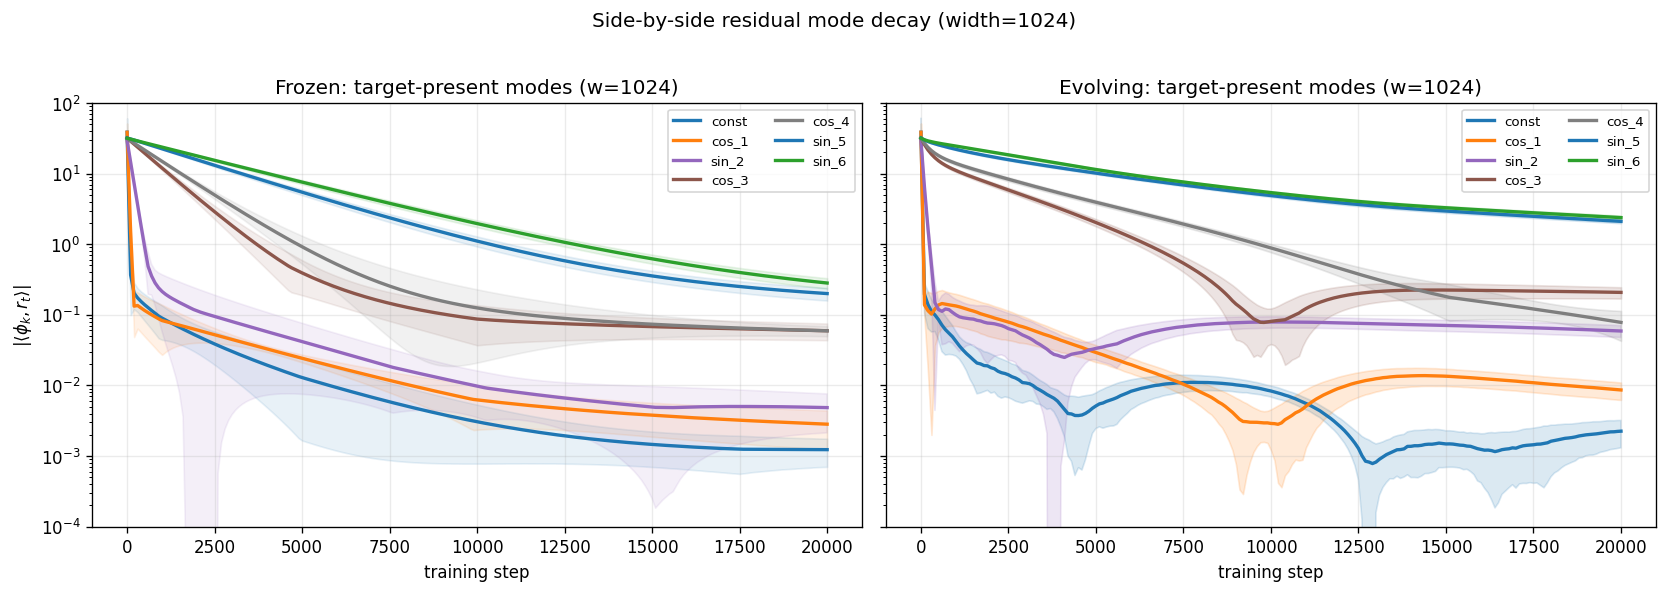

In [19]:
WIDTHS_STACK = [128, 256, 512, 1024]
TARGET_FAMILY_FMT = 'ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w{width}'

stack_plot_dir = ROOT / 'notebooks' / 'plots' / 'ntk_frozen_vs_evolving_mode_dynamics_width_stacks'
stack_plot_dir.mkdir(parents=True, exist_ok=True)


def _target_present_indices(meta, tracked_mode_names_local):
    target_ks_local = np.asarray(meta.get('target_Ks', []), dtype=int)
    target_amps_local = np.asarray(meta.get('target_amps', []), dtype=float)
    target_phases_local = np.asarray(meta.get('target_phases', []), dtype=float)

    if not (
        len(target_ks_local) == len(target_amps_local) == len(target_phases_local)
    ):
        raise ValueError('target metadata arrays have mismatched lengths')

    present = set()
    amp_tol = 1e-10

    for k, a, phi in zip(target_ks_local, target_amps_local, target_phases_local):
        k = int(k)
        a = float(a)
        phi = float(phi)
        if abs(a) <= amp_tol:
            continue
        if k == 0:
            if abs(a * np.cos(phi)) > amp_tol:
                present.add('const')
            continue

        c_cos = a * np.cos(phi)
        c_sin = -a * np.sin(phi)
        if abs(c_cos) > amp_tol:
            present.add(f'cos_{k}')
        if abs(c_sin) > amp_tol:
            present.add(f'sin_{k}')

    idx = [i for i, name in enumerate(tracked_mode_names_local) if str(name) in present]
    if len(idx) == 0:
        idx = list(range(len(tracked_mode_names_local)))
    return idx


for w in WIDTHS_STACK:
    exp_name_w = TARGET_FAMILY_FMT.format(width=w)
    run_dir_w = latest_run_dir(BASE_RESULTS, exp_name_w)
    if run_dir_w is None:
        print(f'Skip missing run: {exp_name_w}')
        continue

    manifest_w = load_manifest(run_dir_w)
    width_key = sorted([int(x) for x in manifest_w['runs'].keys()])[0]
    run_w = npz(run_dir_w, manifest_w['runs'][str(width_key)])

    steps_w = np.asarray(run_w['snapshot_steps'], dtype=int)
    mode_proj_f_w = np.asarray(run_w['mode_proj_frozen'], dtype=float)
    mode_proj_e_w = np.asarray(run_w['mode_proj_evolving'], dtype=float)
    tracked_names_w = [str(x) for x in run_w['tracked_mode_names']]

    present_idx_w = _target_present_indices(manifest_w['meta'], tracked_names_w)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True, sharey=True)
    ax_frozen, ax_evolving = axes

    for plot_i, mode_i in enumerate(present_idx_w):
        mode_name = tracked_names_w[mode_i]
        c = mode_to_color.get(mode_name, default_cycle[plot_i % len(default_cycle)])

        y_f = np.abs(mode_proj_f_w[:, :, mode_i])
        y_e = np.abs(mode_proj_e_w[:, :, mode_i])

        mf, sf = seed_mean_std(y_f)
        me, se = seed_mean_std(y_e)

        ax_frozen.plot(steps_w, mf, linewidth=2.0, color=c, label=mode_name)
        ax_frozen.fill_between(steps_w, np.maximum(mf - sf, 1e-16), mf + sf, alpha=0.10, color=c)

        ax_evolving.plot(steps_w, me, linewidth=2.0, color=c, label=mode_name)
        ax_evolving.fill_between(steps_w, np.maximum(me - se, 1e-16), me + se, alpha=0.16, color=c)

    ax_frozen.set_title(f'Frozen: target-present modes (w={w})')
    ax_evolving.set_title(f'Evolving: target-present modes (w={w})')

    for ax in axes:
        ax.set_yscale('log')
        ax.set_ylim(1e-4, 1e+2)
        ax.set_xlabel('training step')
        ax.grid(True, alpha=0.25)

    ax_frozen.set_ylabel(r'$|\langle \phi_k, r_t \rangle|$')
    ax_frozen.legend(fontsize=8, ncol=2)
    ax_evolving.legend(fontsize=8, ncol=2)

    fig.suptitle(f'Side-by-side residual mode decay (width={w})', y=1.02)
    fig.tight_layout()

    filename = stack_plot_dir / f'side_by_side_residual_decay_equalamp_w{w}.png'
    plt.savefig(filename, bbox_inches='tight')
    print(f'Successfully saved {filename}')
    plt.show()



## Width-Stacked Projection Error (Absolute)

This section generates one absolute projection-error figure per width (one below another when executed).


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/projection_error_absolute_equalamp_by_freq_w128.png


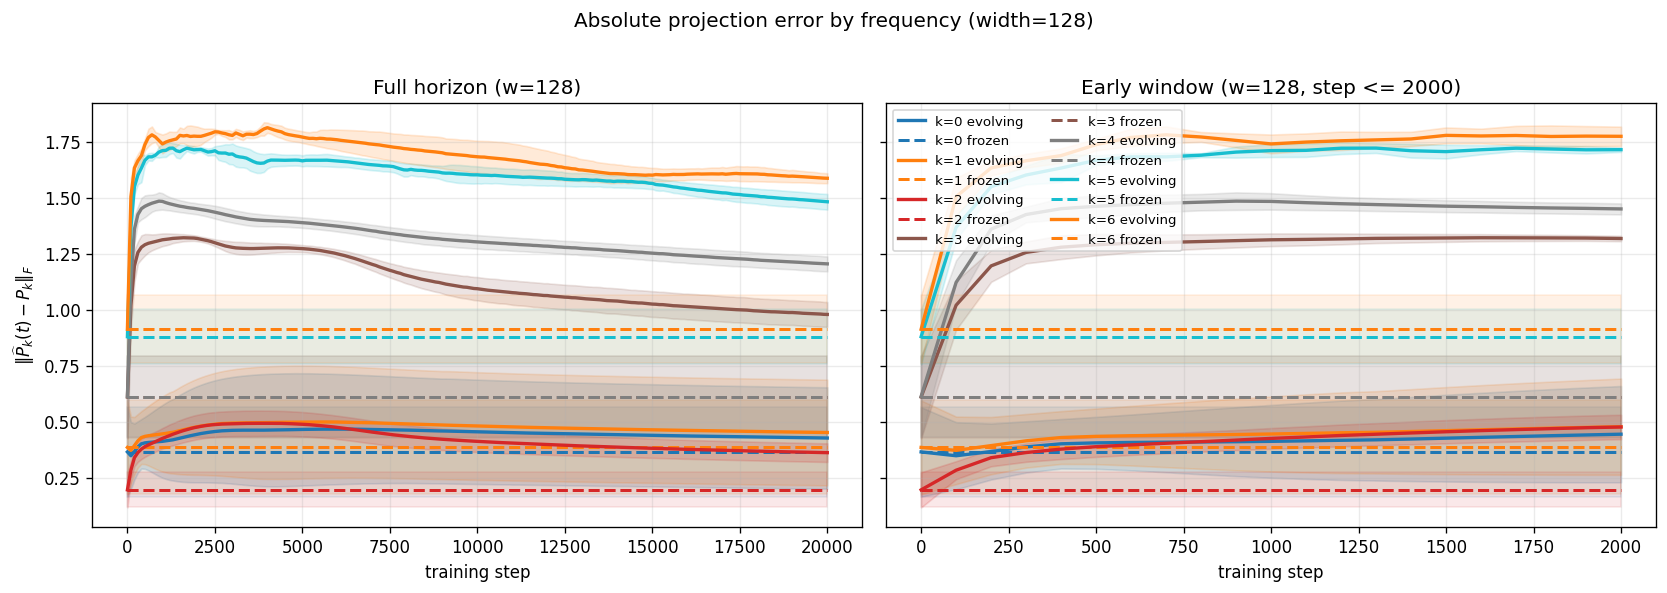

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/projection_error_absolute_equalamp_by_freq_w256.png


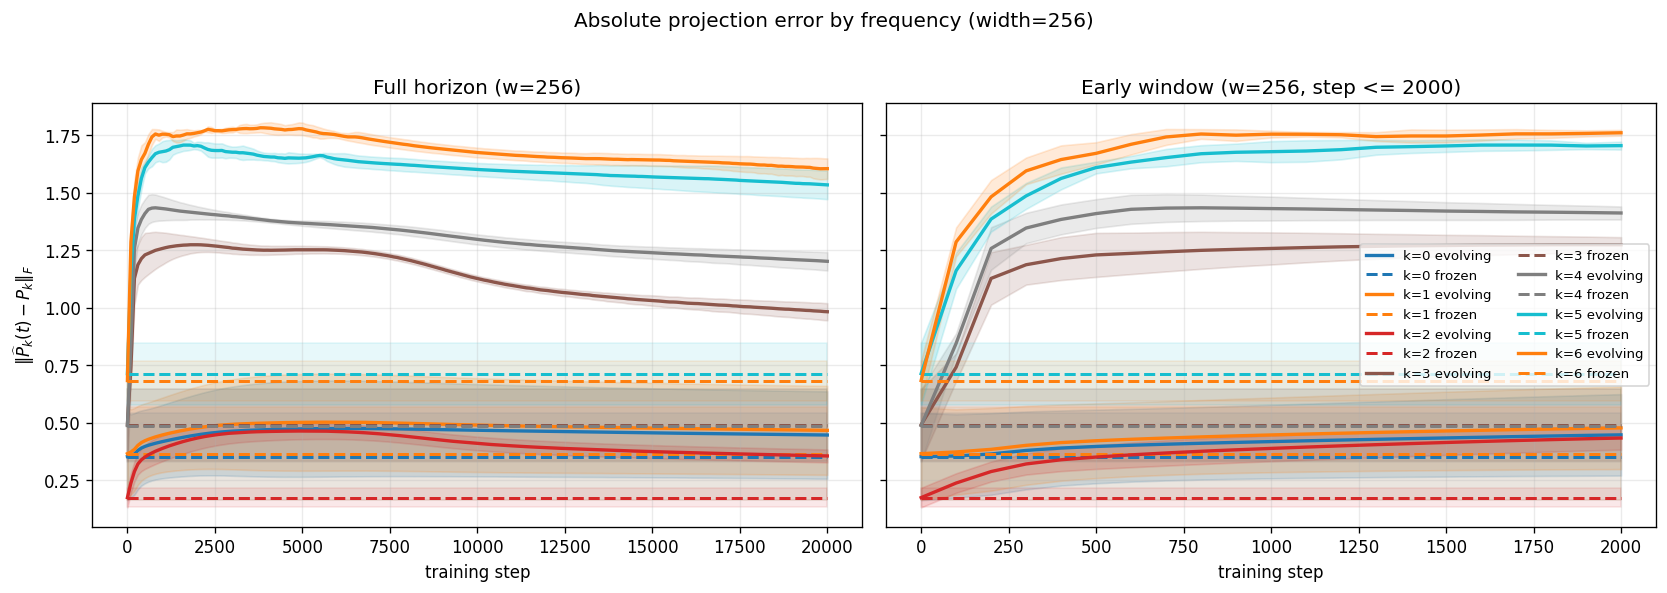

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/projection_error_absolute_equalamp_by_freq_w512.png


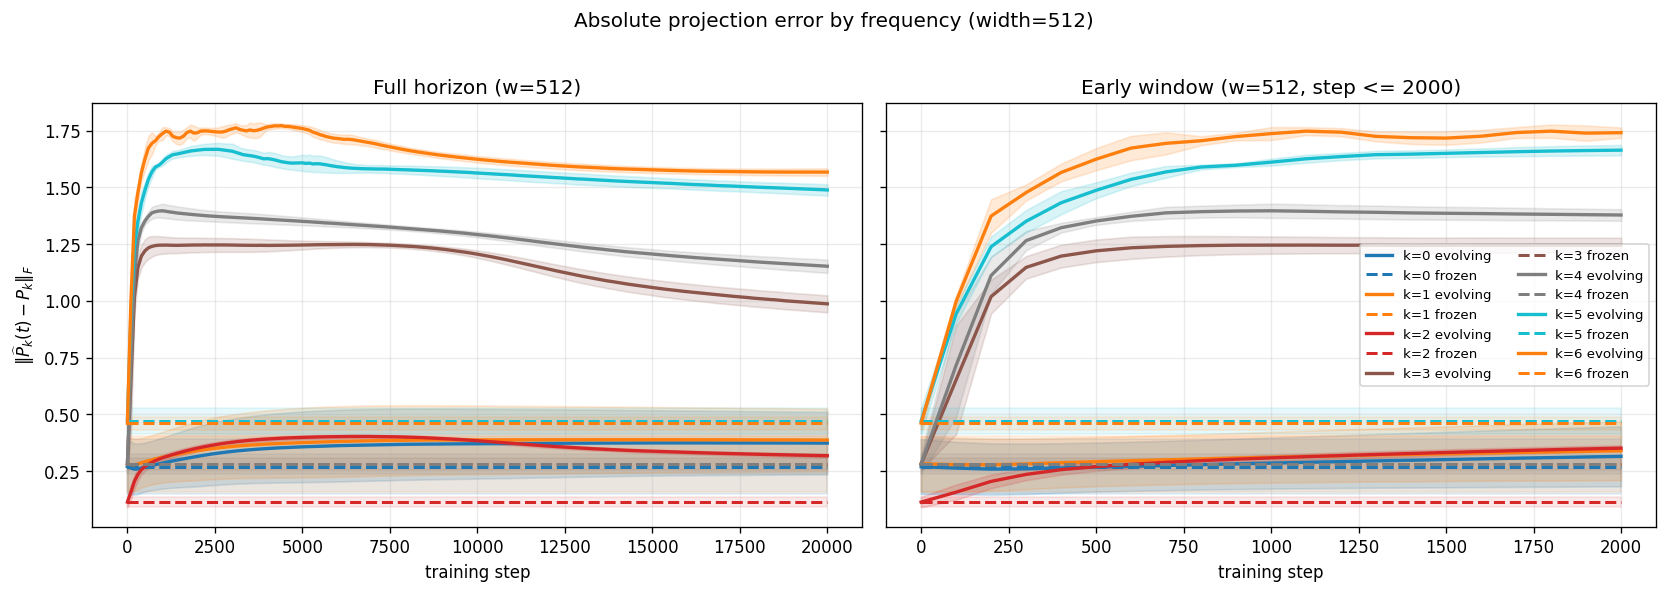

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/projection_error_absolute_equalamp_by_freq_w1024.png


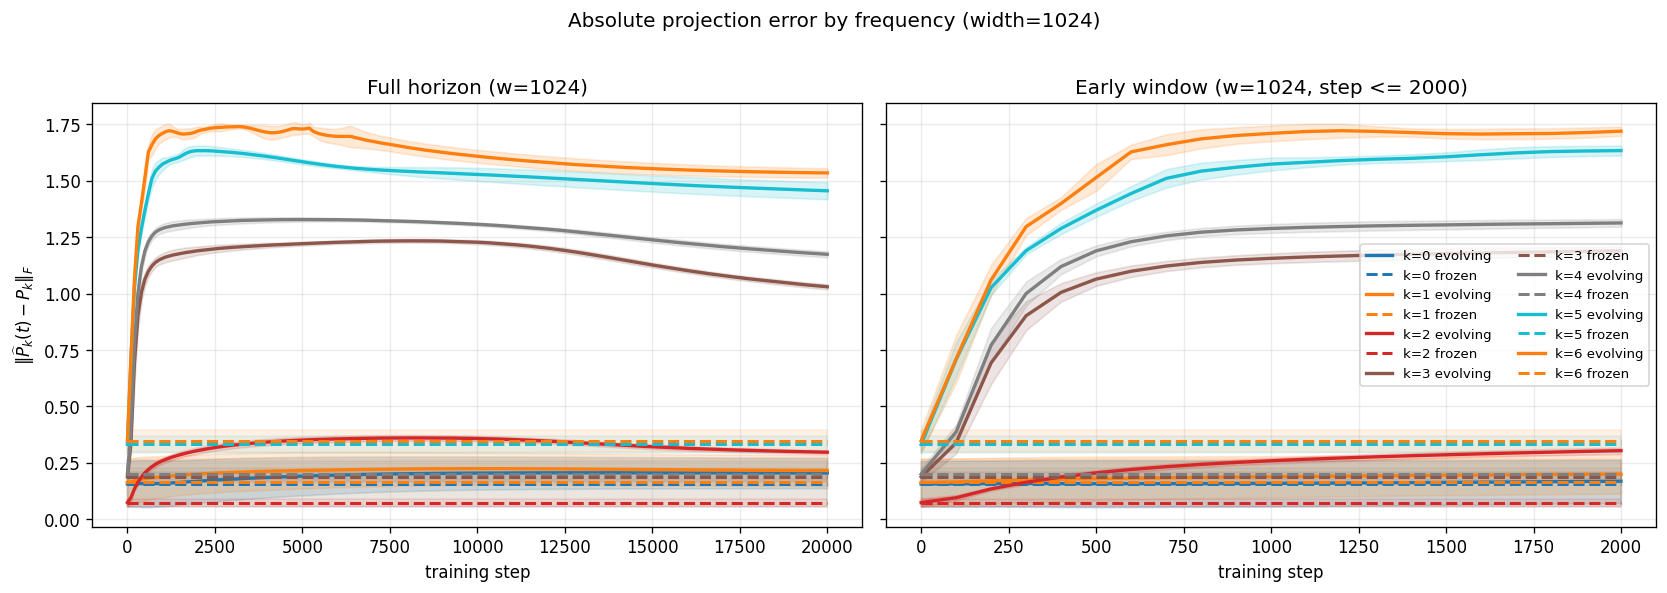

In [20]:
EARLY_MAX_STEP_STACK = int(globals().get('EARLY_MAX_STEP', 2000))

for w in WIDTHS_STACK:
    exp_name_w = TARGET_FAMILY_FMT.format(width=w)
    run_dir_w = latest_run_dir(BASE_RESULTS, exp_name_w)
    if run_dir_w is None:
        print(f'Skip missing run: {exp_name_w}')
        continue

    manifest_w = load_manifest(run_dir_w)
    width_key = sorted([int(x) for x in manifest_w['runs'].keys()])[0]
    run_w = npz(run_dir_w, manifest_w['runs'][str(width_key)])

    steps_w = np.asarray(run_w['snapshot_steps'], dtype=int)
    freqs_w = np.asarray(run_w['plane_freqs'], dtype=int)
    eps_f_w = np.asarray(run_w['plane_projector_fro_frozen'], dtype=float)
    eps_e_w = np.asarray(run_w['plane_projector_fro_evolving'], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
    ax_full, ax_early = axes

    for j, k in enumerate(freqs_w):
        c = freq_to_color.get(int(k), default_cycle[j % len(default_cycle)])
        mf, sf = seed_mean_std(eps_f_w[:, :, j])
        me, se = seed_mean_std(eps_e_w[:, :, j])

        ax_full.plot(steps_w, me, linewidth=2.0, color=c, label=f'k={int(k)} evolving')
        ax_full.fill_between(steps_w, np.maximum(me - se, 0.0), me + se, alpha=0.16, color=c)
        ax_full.plot(steps_w, mf, '--', linewidth=1.8, color=c, label=f'k={int(k)} frozen')
        ax_full.fill_between(steps_w, np.maximum(mf - sf, 0.0), mf + sf, alpha=0.10, color=c)

        mask_w = steps_w <= EARLY_MAX_STEP_STACK
        ax_early.plot(steps_w[mask_w], me[mask_w], linewidth=2.0, color=c, label=f'k={int(k)} evolving')
        ax_early.fill_between(
            steps_w[mask_w],
            np.maximum(me[mask_w] - se[mask_w], 0.0),
            me[mask_w] + se[mask_w],
            alpha=0.16,
            color=c,
        )
        ax_early.plot(steps_w[mask_w], mf[mask_w], '--', linewidth=1.8, color=c, label=f'k={int(k)} frozen')
        ax_early.fill_between(
            steps_w[mask_w],
            np.maximum(mf[mask_w] - sf[mask_w], 0.0),
            mf[mask_w] + sf[mask_w],
            alpha=0.10,
            color=c,
        )

    ax_full.set_title(f'Full horizon (w={w})')
    ax_early.set_title(f'Early window (w={w}, step <= {EARLY_MAX_STEP_STACK})')

    for ax in axes:
        ax.set_xlabel('training step')
        ax.grid(True, alpha=0.25)

    ax_full.set_ylabel(r'$\|\widehat P_k(t)-P_k\|_F$')
    ax_early.legend(fontsize=8, ncol=2)

    fig.suptitle(f'Absolute projection error by frequency (width={w})', y=1.02)
    fig.tight_layout()

    filename = stack_plot_dir / f'projection_error_absolute_equalamp_by_freq_w{w}.png'
    plt.savefig(filename, bbox_inches='tight')
    print(f'Successfully saved {filename}')
    plt.show()




## Width-Stacked Spectral Strength (Absolute)

This section generates one per-frequency spectral-strength figure per width (one below another when executed).


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/spectral_strength_equalamp_by_freq_w128.png


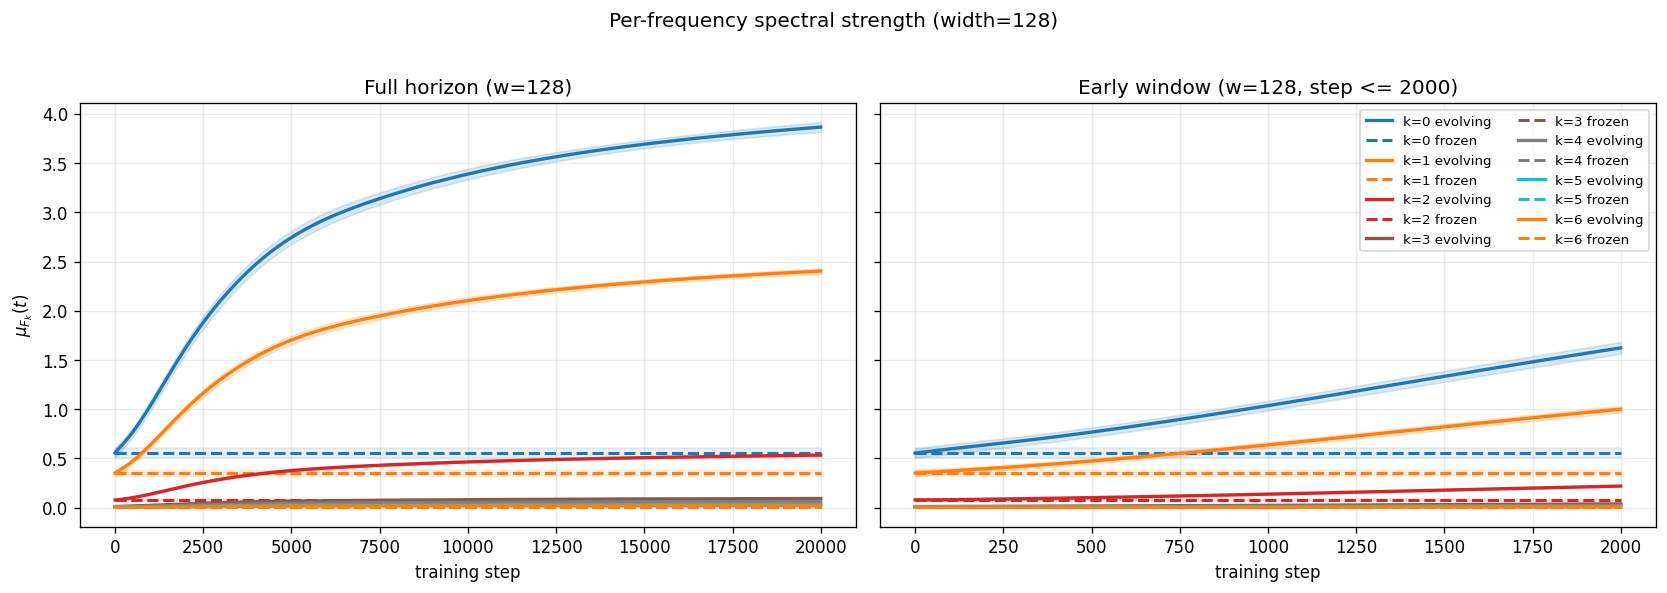

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/spectral_strength_equalamp_by_freq_w256.png


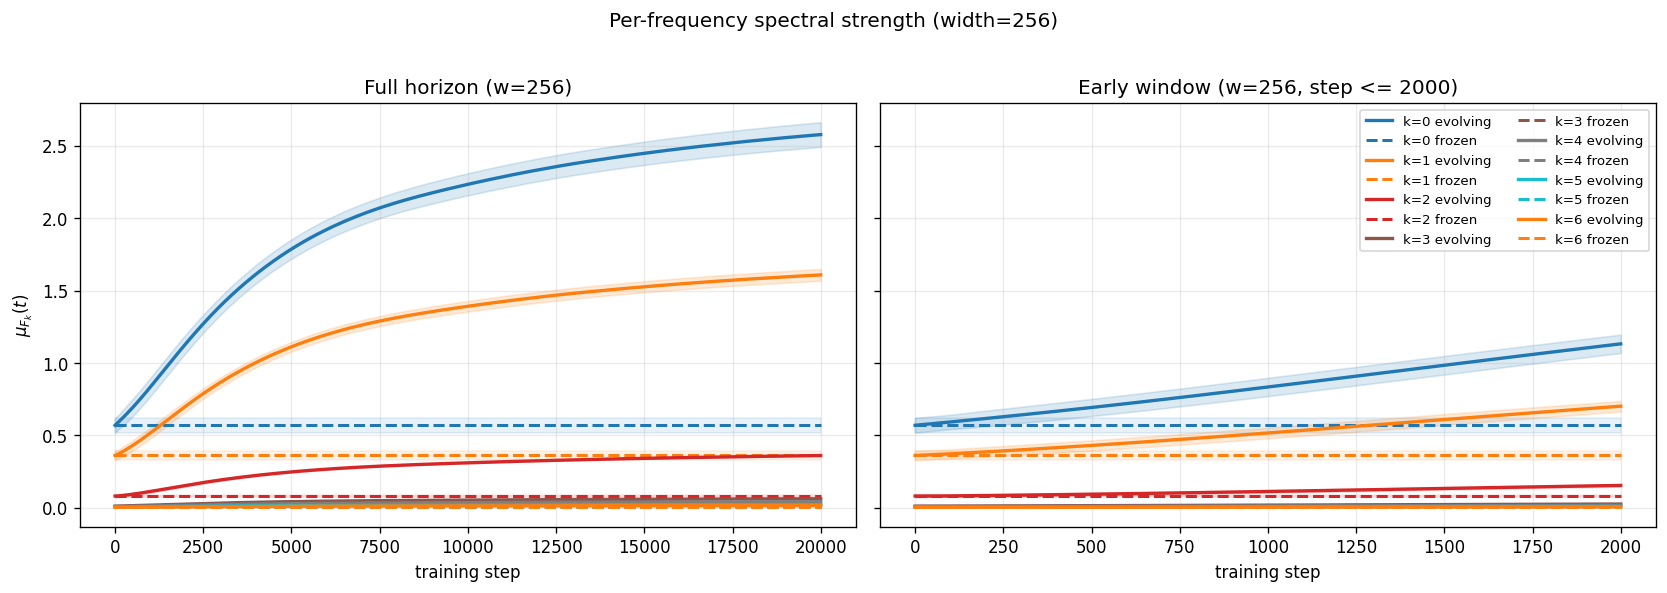

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/spectral_strength_equalamp_by_freq_w512.png


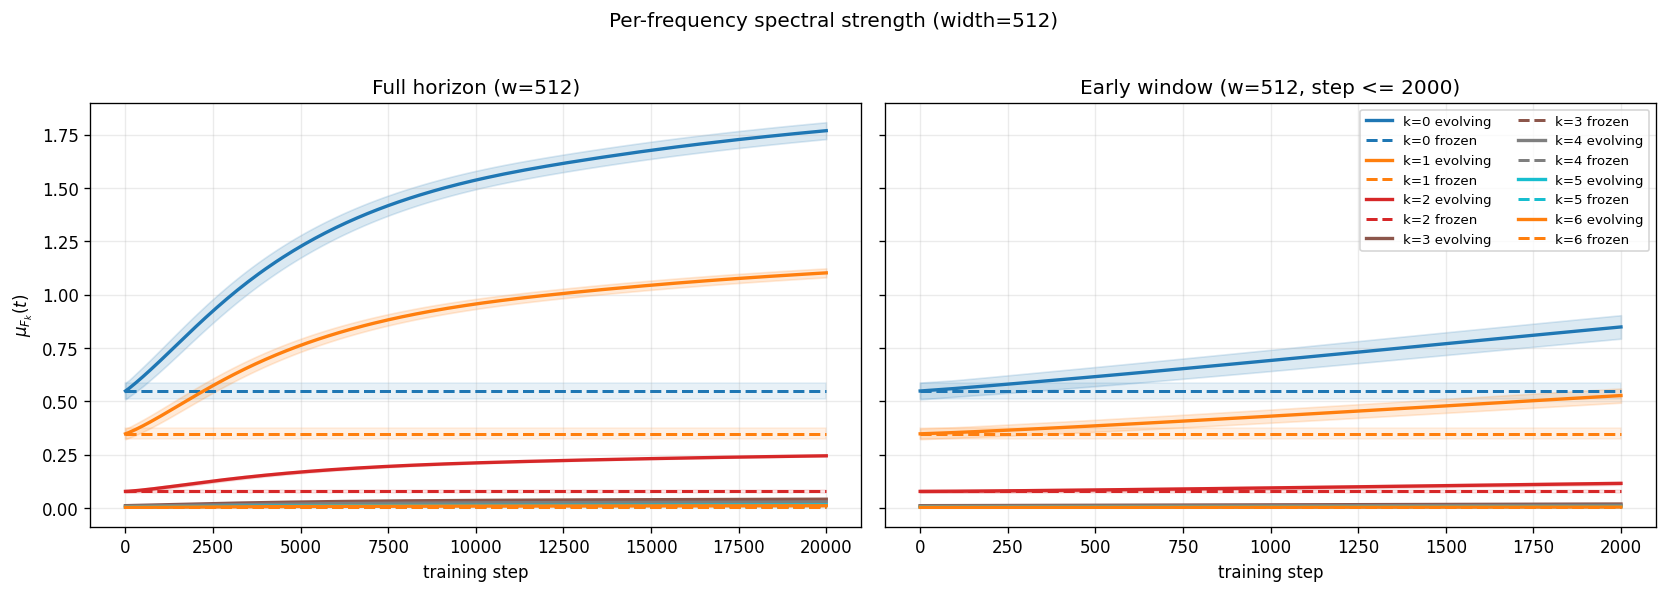

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/spectral_strength_equalamp_by_freq_w1024.png


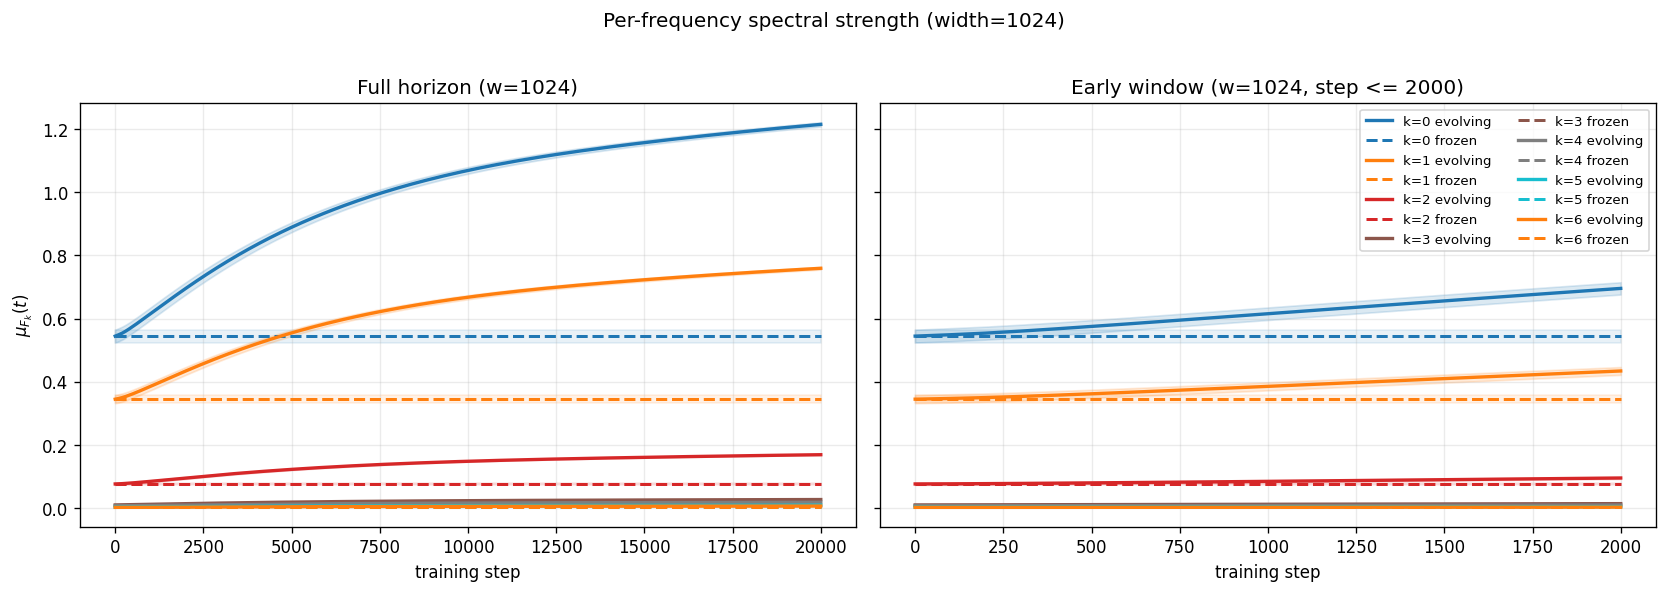

In [21]:
EARLY_MAX_STEP_STACK = int(globals().get('EARLY_MAX_STEP', 2000))


def _per_plane_mu_from_prefix_local(prefix_mu, prefix_dims):
    prefix_mu = np.asarray(prefix_mu, dtype=float)
    prefix_dims = np.asarray(prefix_dims, dtype=float)

    tau_cum = prefix_mu * prefix_dims.reshape(1, 1, -1)
    tau_plane = np.full_like(tau_cum, np.nan, dtype=float)

    tau_plane[:, :, 0] = tau_cum[:, :, 0]
    if tau_cum.shape[2] > 1:
        tau_plane[:, :, 1:] = tau_cum[:, :, 1:] - tau_cum[:, :, :-1]

    d_plane = np.empty((tau_cum.shape[2],), dtype=float)
    d_plane[0] = prefix_dims[0]
    if tau_cum.shape[2] > 1:
        d_plane[1:] = prefix_dims[1:] - prefix_dims[:-1]

    mu_plane = tau_plane / np.maximum(d_plane.reshape(1, 1, -1), 1e-12)
    return mu_plane


for w in WIDTHS_STACK:
    exp_name_w = TARGET_FAMILY_FMT.format(width=w)
    run_dir_w = latest_run_dir(BASE_RESULTS, exp_name_w)
    if run_dir_w is None:
        print(f'Skip missing run: {exp_name_w}')
        continue

    manifest_w = load_manifest(run_dir_w)
    width_key = sorted([int(x) for x in manifest_w['runs'].keys()])[0]
    run_w = npz(run_dir_w, manifest_w['runs'][str(width_key)])

    steps_w = np.asarray(run_w['snapshot_steps'], dtype=int)
    freqs_w = np.asarray(run_w['plane_freqs'], dtype=int)

    required = {'prefix_mu_frozen', 'prefix_mu_evolving', 'prefix_freqs'}
    if not required <= set(run_w.keys()):
        print(f'Skip width={w}: missing spectral keys {sorted(required - set(run_w.keys()))}')
        continue

    prefix_freqs_w = np.asarray(run_w['prefix_freqs'], dtype=int)
    prefix_mu_f_w = np.asarray(run_w['prefix_mu_frozen'], dtype=float)
    prefix_mu_e_w = np.asarray(run_w['prefix_mu_evolving'], dtype=float)

    if 'prefix_dims' in run_w:
        prefix_dims_w = np.asarray(run_w['prefix_dims'], dtype=int)
    else:
        prefix_dims_w = 1 + 2 * prefix_freqs_w

    mu_plane_f_all = _per_plane_mu_from_prefix_local(prefix_mu_f_w, prefix_dims_w)
    mu_plane_e_all = _per_plane_mu_from_prefix_local(prefix_mu_e_w, prefix_dims_w)

    idx_map = {int(k): i for i, k in enumerate(prefix_freqs_w)}
    if not set(int(k) for k in freqs_w).issubset(set(idx_map.keys())):
        missing_freqs = sorted(set(int(k) for k in freqs_w) - set(idx_map.keys()))
        print(f'Skip width={w}: missing prefix frequencies for {missing_freqs}')
        continue

    idx_w = np.asarray([idx_map[int(k)] for k in freqs_w], dtype=int)
    mu_f_w = mu_plane_f_all[:, :, idx_w]
    mu_e_w = mu_plane_e_all[:, :, idx_w]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
    ax_full, ax_early = axes

    for j, k in enumerate(freqs_w):
        c = freq_to_color.get(int(k), default_cycle[j % len(default_cycle)])
        mf, sf = seed_mean_std(mu_f_w[:, :, j])
        me, se = seed_mean_std(mu_e_w[:, :, j])

        ax_full.plot(steps_w, me, linewidth=2.0, color=c, label=f'k={int(k)} evolving')
        ax_full.fill_between(steps_w, np.maximum(me - se, 0.0), me + se, alpha=0.16, color=c)
        ax_full.plot(steps_w, mf, '--', linewidth=1.8, color=c, label=f'k={int(k)} frozen')
        ax_full.fill_between(steps_w, np.maximum(mf - sf, 0.0), mf + sf, alpha=0.10, color=c)

        mask_w = steps_w <= EARLY_MAX_STEP_STACK
        ax_early.plot(steps_w[mask_w], me[mask_w], linewidth=2.0, color=c, label=f'k={int(k)} evolving')
        ax_early.fill_between(
            steps_w[mask_w],
            np.maximum(me[mask_w] - se[mask_w], 0.0),
            me[mask_w] + se[mask_w],
            alpha=0.16,
            color=c,
        )
        ax_early.plot(steps_w[mask_w], mf[mask_w], '--', linewidth=1.8, color=c, label=f'k={int(k)} frozen')
        ax_early.fill_between(
            steps_w[mask_w],
            np.maximum(mf[mask_w] - sf[mask_w], 0.0),
            mf[mask_w] + sf[mask_w],
            alpha=0.10,
            color=c,
        )

    ax_full.set_title(f'Full horizon (w={w})')
    ax_early.set_title(f'Early window (w={w}, step <= {EARLY_MAX_STEP_STACK})')

    for ax in axes:
        ax.set_xlabel('training step')
        ax.grid(True, alpha=0.25)

    ax_full.set_ylabel(r'$\mu_{F_k}(t)$')
    ax_early.legend(fontsize=8, ncol=2)

    fig.suptitle(f'Per-frequency spectral strength (width={w})', y=1.02)
    fig.tight_layout()

    filename = stack_plot_dir / f'spectral_strength_equalamp_by_freq_w{w}.png'
    plt.savefig(filename, bbox_inches='tight')
    print(f'Successfully saved {filename}')
    plt.show()




## Width-Stacked Cosine Alignment (RMS-Cos)

This section generates one alignment figure per width (one below another when executed).


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/rms_cos_alignment_equalamp_by_freq_w128.png


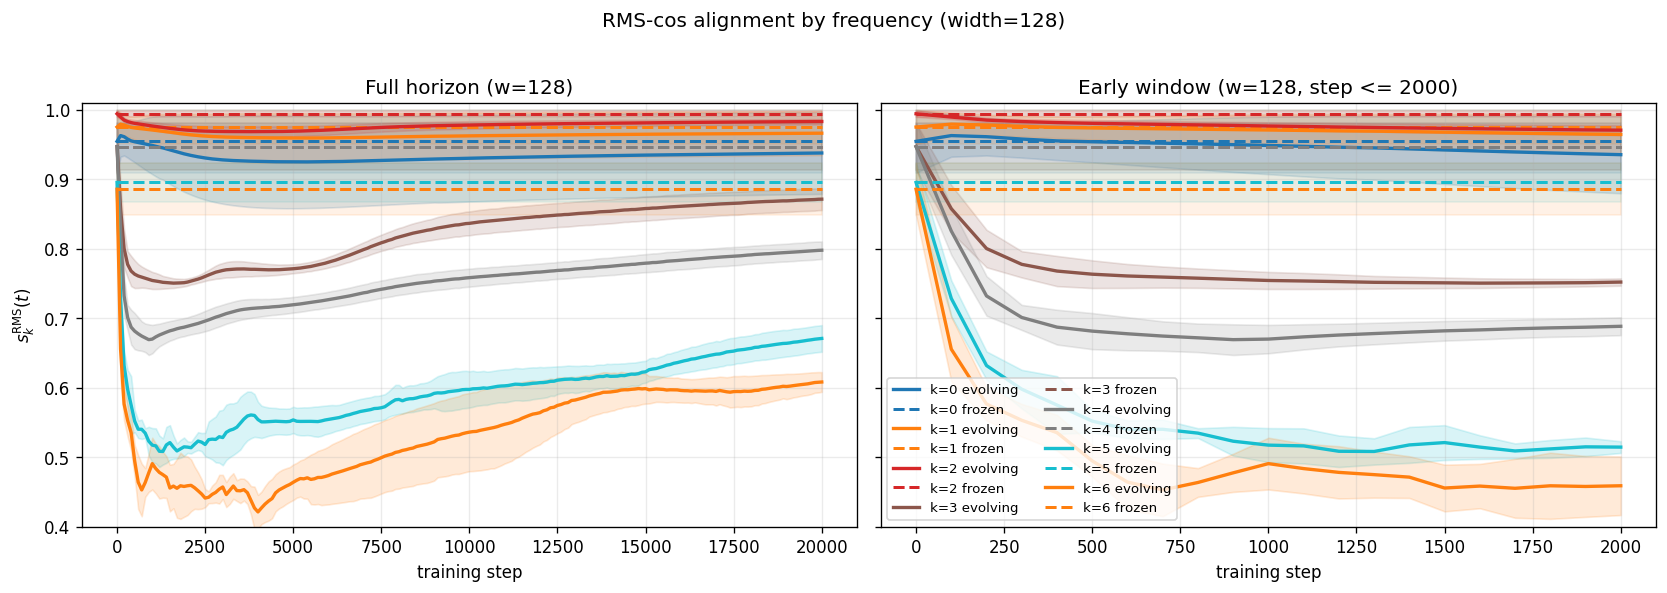

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/rms_cos_alignment_equalamp_by_freq_w256.png


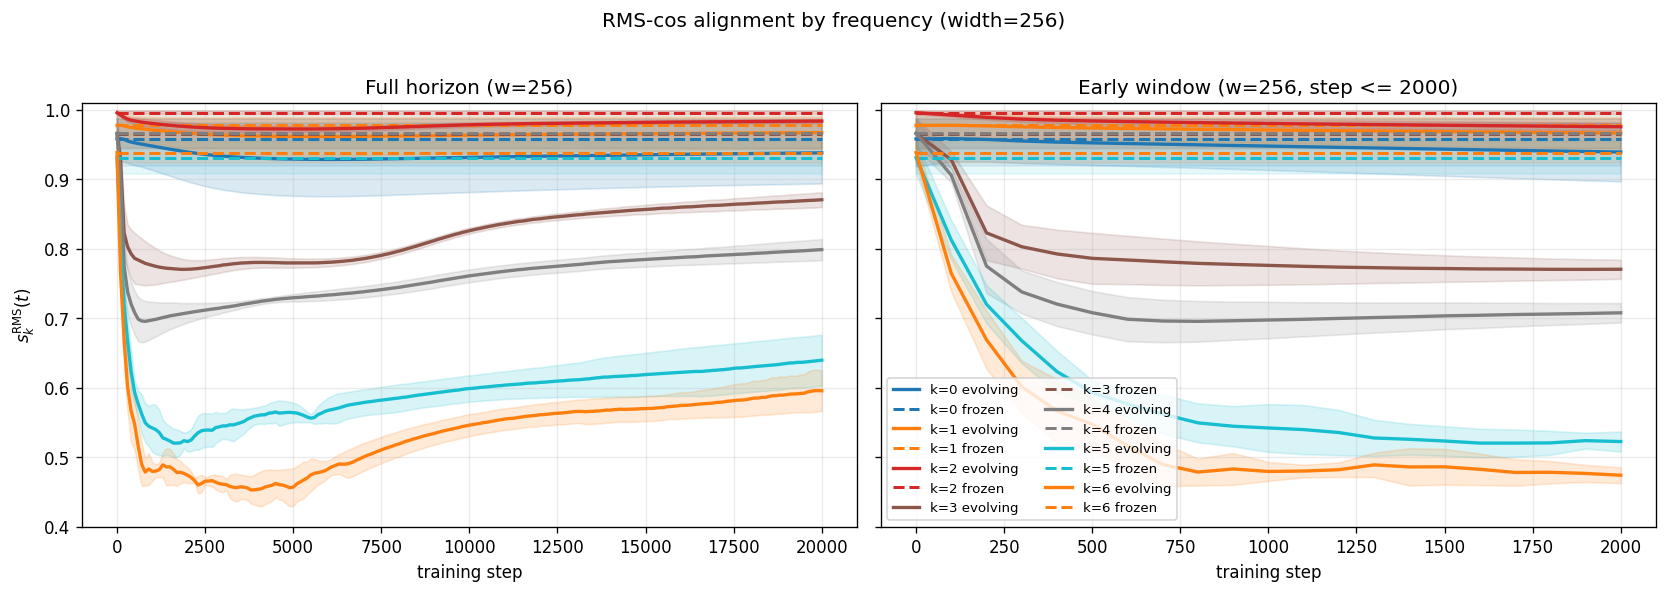

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/rms_cos_alignment_equalamp_by_freq_w512.png


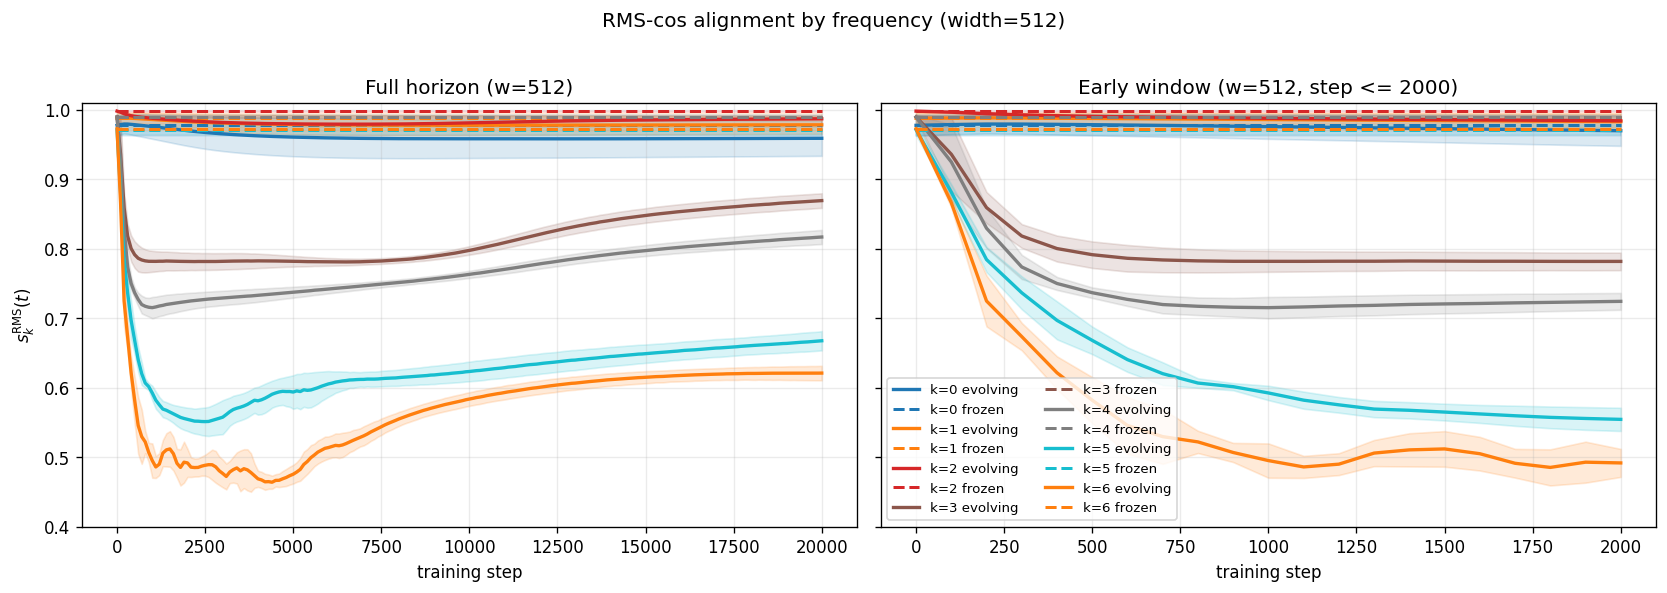

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/rms_cos_alignment_equalamp_by_freq_w1024.png


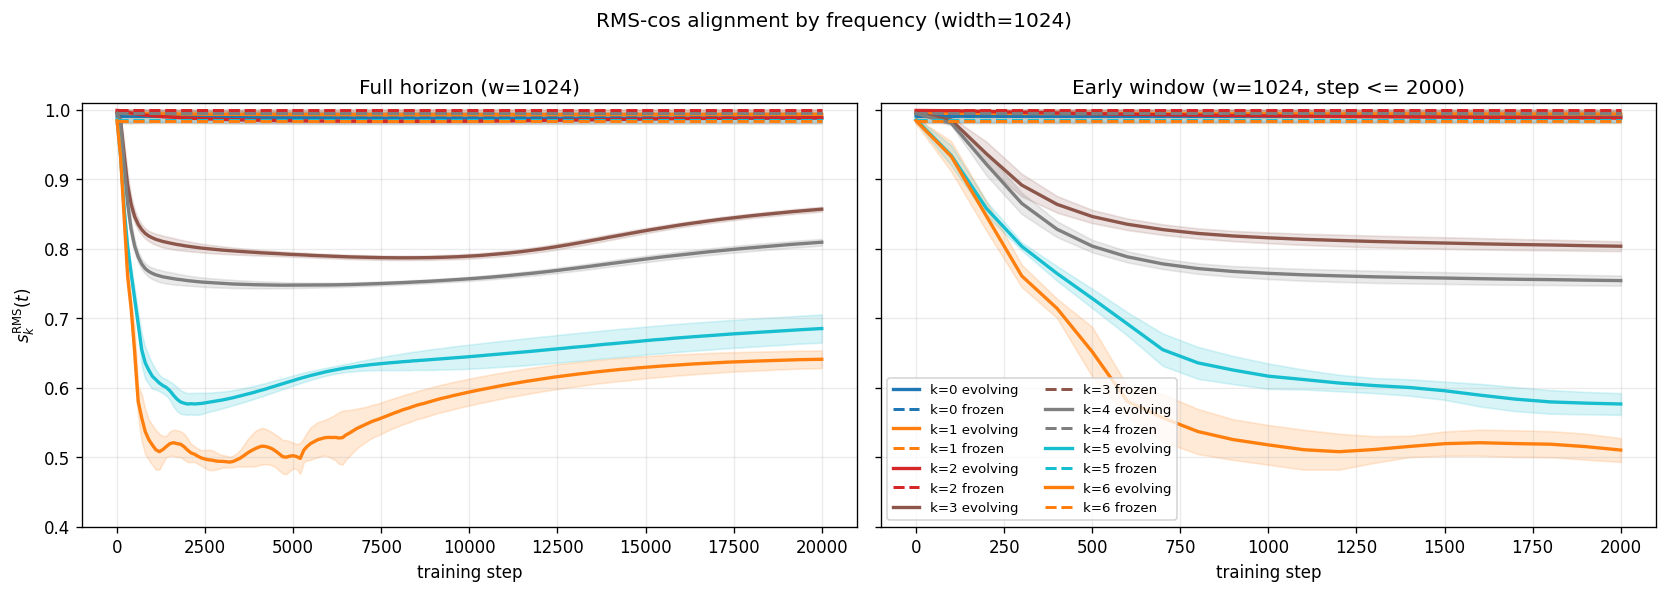

In [22]:
for w in WIDTHS_STACK:
    exp_name_w = TARGET_FAMILY_FMT.format(width=w)
    run_dir_w = latest_run_dir(BASE_RESULTS, exp_name_w)
    if run_dir_w is None:
        print(f'Skip missing run: {exp_name_w}')
        continue

    manifest_w = load_manifest(run_dir_w)
    width_key = sorted([int(x) for x in manifest_w['runs'].keys()])[0]
    run_w = npz(run_dir_w, manifest_w['runs'][str(width_key)])

    steps_w = np.asarray(run_w['snapshot_steps'], dtype=int)
    freqs_w = np.asarray(run_w['plane_freqs'], dtype=int)
    angles_f_w = np.asarray(run_w['plane_angles_frozen'], dtype=float)
    angles_e_w = np.asarray(run_w['plane_angles_evolving'], dtype=float)

    score_f_w = np.sqrt(np.nanmean(np.cos(angles_f_w) ** 2, axis=3))
    score_e_w = np.sqrt(np.nanmean(np.cos(angles_e_w) ** 2, axis=3))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
    ax_full, ax_early = axes

    for j, k in enumerate(freqs_w):
        c = freq_to_color.get(int(k), default_cycle[j % len(default_cycle)])
        mf, sf = seed_mean_std(score_f_w[:, :, j])
        me, se = seed_mean_std(score_e_w[:, :, j])

        ax_full.plot(steps_w, me, linewidth=2.0, color=c, label=f'k={int(k)} evolving')
        ax_full.fill_between(steps_w, np.maximum(me - se, 0.0), np.minimum(me + se, 1.0), alpha=0.16, color=c)
        ax_full.plot(steps_w, mf, '--', linewidth=1.8, color=c, label=f'k={int(k)} frozen')
        ax_full.fill_between(steps_w, np.maximum(mf - sf, 0.0), np.minimum(mf + sf, 1.0), alpha=0.10, color=c)

        mask_w = steps_w <= EARLY_MAX_STEP
        ax_early.plot(steps_w[mask_w], me[mask_w], linewidth=2.0, color=c, label=f'k={int(k)} evolving')
        ax_early.fill_between(
            steps_w[mask_w],
            np.maximum(me[mask_w] - se[mask_w], 0.0),
            np.minimum(me[mask_w] + se[mask_w], 1.0),
            alpha=0.16,
            color=c,
        )
        ax_early.plot(steps_w[mask_w], mf[mask_w], '--', linewidth=1.8, color=c, label=f'k={int(k)} frozen')
        ax_early.fill_between(
            steps_w[mask_w],
            np.maximum(mf[mask_w] - sf[mask_w], 0.0),
            np.minimum(mf[mask_w] + sf[mask_w], 1.0),
            alpha=0.10,
            color=c,
        )

    ax_full.set_title(f'Full horizon (w={w})')
    ax_early.set_title(f'Early window (w={w}, step <= {EARLY_MAX_STEP})')

    for ax in axes:
        ax.set_xlabel('training step')
        ax.set_ylim(0.4, 1.01)
        ax.grid(True, alpha=0.25)

    ax_full.set_ylabel(r'$s_k^{\mathrm{RMS}}(t)$')
    # ax_full.legend(fontsize=8, ncol=2)
    ax_early.legend(fontsize=8, ncol=2)

    fig.suptitle(f'RMS-cos alignment by frequency (width={w})', y=1.02)
    fig.tight_layout()

    filename = stack_plot_dir / f'rms_cos_alignment_equalamp_by_freq_w{w}.png'
    plt.savefig(filename, bbox_inches='tight')
    print(f'Successfully saved {filename}')
    plt.show()



## Width-Stacked Cumulative Alignment ($F_{\le k}$)

This section generates one cumulative-alignment figure per width (one below another when executed).


Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/cumulative_rms_cos_alignment_equalamp_w128_exact.png


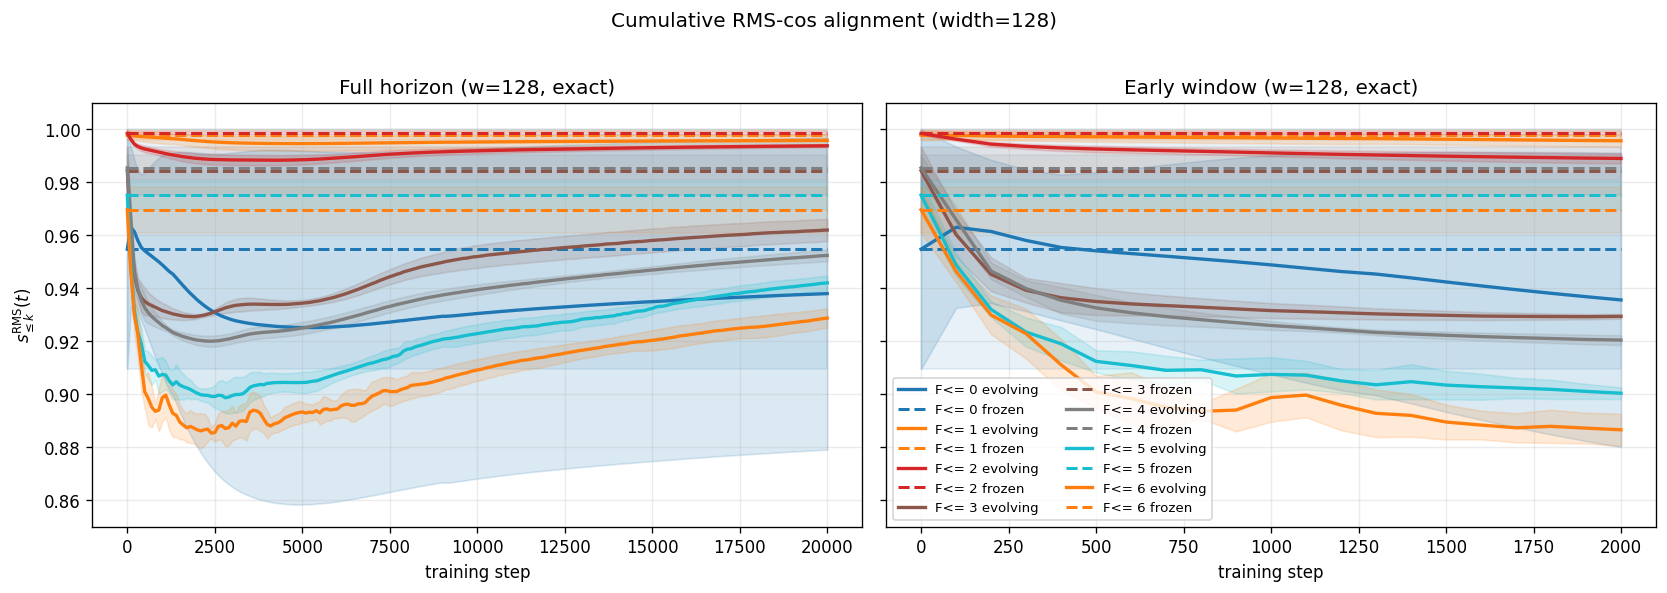

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/cumulative_rms_cos_alignment_equalamp_w256_exact.png


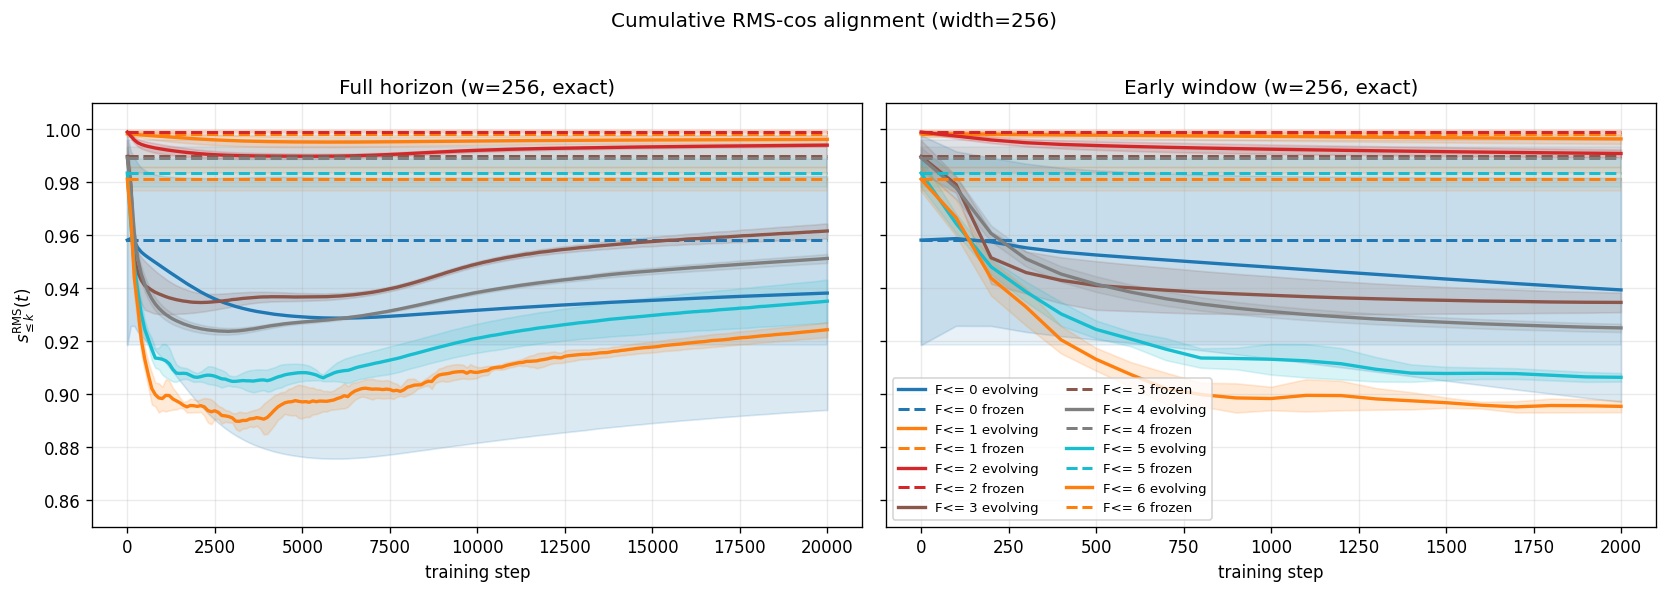

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/cumulative_rms_cos_alignment_equalamp_w512_exact.png


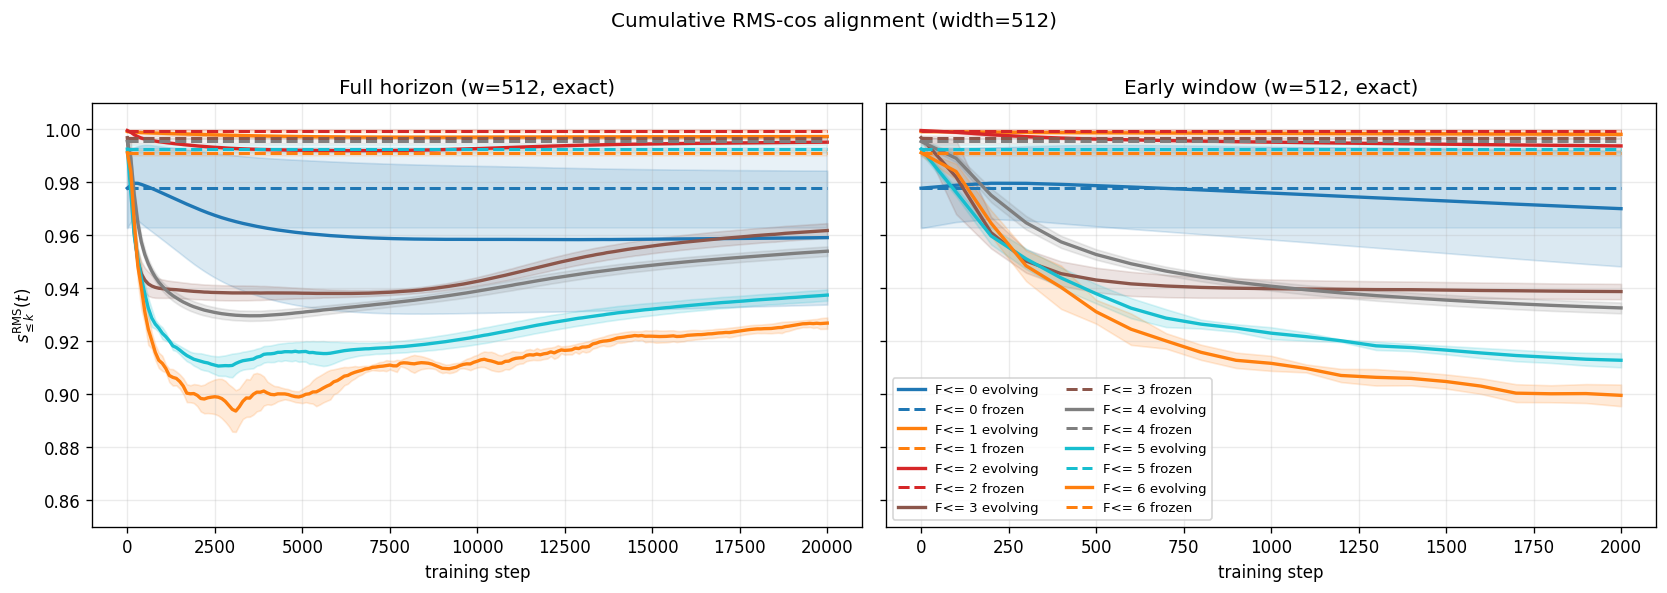

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_stacks/cumulative_rms_cos_alignment_equalamp_w1024_exact.png


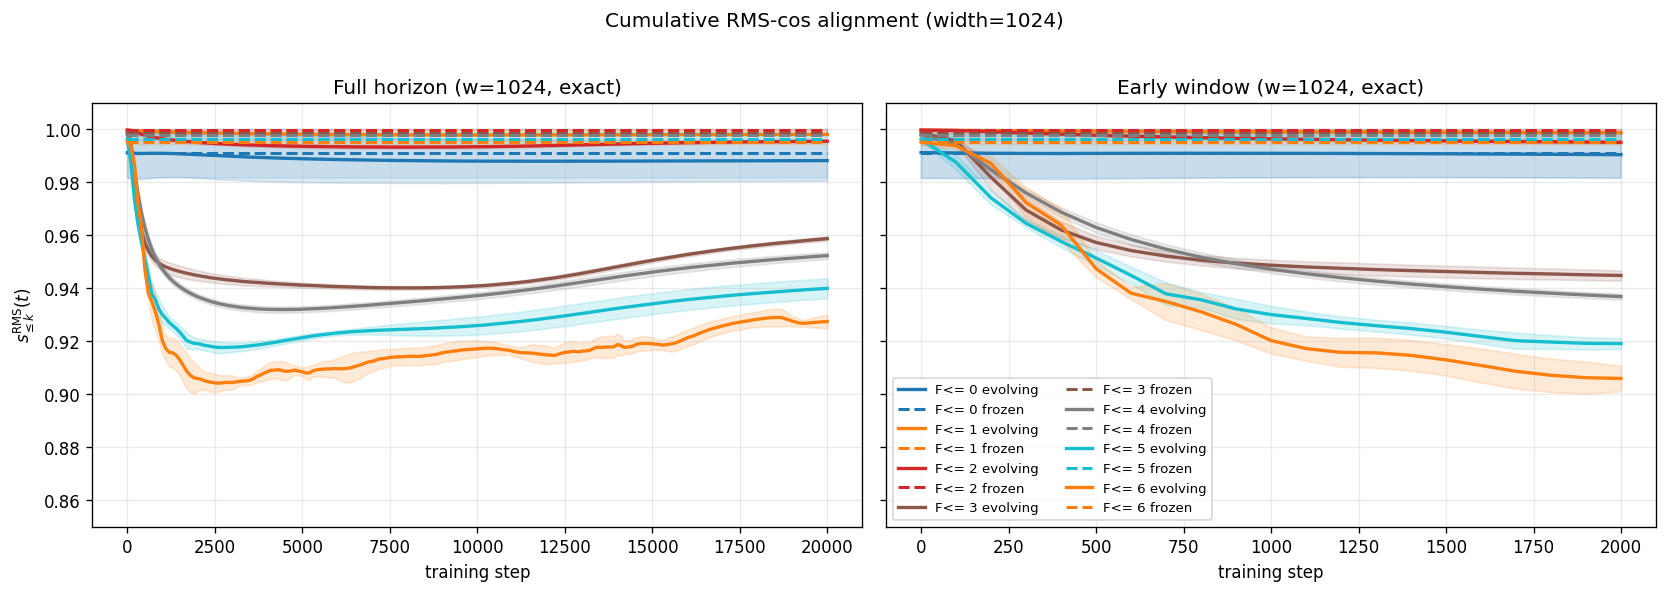

In [23]:
for w in WIDTHS_STACK:
    exp_name_w = TARGET_FAMILY_FMT.format(width=w)
    run_dir_w = latest_run_dir(BASE_RESULTS, exp_name_w)
    if run_dir_w is None:
        print(f'Skip missing run: {exp_name_w}')
        continue

    manifest_w = load_manifest(run_dir_w)
    width_key = sorted([int(x) for x in manifest_w['runs'].keys()])[0]
    run_w = npz(run_dir_w, manifest_w['runs'][str(width_key)])

    steps_w = np.asarray(run_w['snapshot_steps'], dtype=int)
    run_keys_w = set(run_w.keys())

    if {'prefix_affinity_frozen', 'prefix_affinity_evolving'} <= run_keys_w:
        prefix_aff_f_w = np.asarray(run_w['prefix_affinity_frozen'], dtype=float)
        prefix_aff_e_w = np.asarray(run_w['prefix_affinity_evolving'], dtype=float)
        freqs_w = np.asarray(run_w.get('prefix_freqs', np.arange(prefix_aff_f_w.shape[2])), dtype=int)
        source_w = 'exact'
    else:
        freqs_w = np.asarray(sorted(int(k) for k in np.asarray(run_w['plane_freqs'], dtype=int)), dtype=int)
        perm_w = np.asarray([int(np.where(np.asarray(run_w['plane_freqs'], dtype=int) == int(k))[0][0]) for k in freqs_w], dtype=int)

        angles_f_w = np.asarray(run_w['plane_angles_frozen'], dtype=float)[:, :, perm_w, :]
        angles_e_w = np.asarray(run_w['plane_angles_evolving'], dtype=float)[:, :, perm_w, :]
        cos2_f_w = np.cos(angles_f_w) ** 2
        cos2_e_w = np.cos(angles_e_w) ** 2

        n_seed_w, n_snap_w, n_freq_w, _ = cos2_f_w.shape
        prefix_aff_f_w = np.full((n_seed_w, n_snap_w, n_freq_w), np.nan, dtype=float)
        prefix_aff_e_w = np.full((n_seed_w, n_snap_w, n_freq_w), np.nan, dtype=float)

        for j in range(n_freq_w):
            vals_f = cos2_f_w[:, :, : j + 1, :].reshape(n_seed_w, n_snap_w, -1)
            vals_e = cos2_e_w[:, :, : j + 1, :].reshape(n_seed_w, n_snap_w, -1)
            prefix_aff_f_w[:, :, j] = np.sqrt(np.nanmean(vals_f, axis=2))
            prefix_aff_e_w[:, :, j] = np.sqrt(np.nanmean(vals_e, axis=2))

        source_w = 'proxy'

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
    ax_full, ax_early = axes

    for j, k in enumerate(freqs_w):
        c = freq_to_color.get(int(k), default_cycle[j % len(default_cycle)])

        mf, sf = seed_mean_std(prefix_aff_f_w[:, :, j])
        me, se = seed_mean_std(prefix_aff_e_w[:, :, j])

        ax_full.plot(steps_w, me, linewidth=2.0, color=c, label=f'F<= {int(k)} evolving')
        ax_full.fill_between(steps_w, np.maximum(me - se, 0.0), np.minimum(me + se, 1.0), alpha=0.16, color=c)
        ax_full.plot(steps_w, mf, '--', linewidth=1.8, color=c, label=f'F<= {int(k)} frozen')
        ax_full.fill_between(steps_w, np.maximum(mf - sf, 0.0), np.minimum(mf + sf, 1.0), alpha=0.10, color=c)

        mask_w = steps_w <= EARLY_MAX_STEP
        ax_early.plot(steps_w[mask_w], me[mask_w], linewidth=2.0, color=c, label=f'F<= {int(k)} evolving')
        ax_early.fill_between(
            steps_w[mask_w],
            np.maximum(me[mask_w] - se[mask_w], 0.0),
            np.minimum(me[mask_w] + se[mask_w], 1.0),
            alpha=0.16,
            color=c,
        )
        ax_early.plot(steps_w[mask_w], mf[mask_w], '--', linewidth=1.8, color=c, label=f'F<= {int(k)} frozen')
        ax_early.fill_between(
            steps_w[mask_w],
            np.maximum(mf[mask_w] - sf[mask_w], 0.0),
            np.minimum(mf[mask_w] + sf[mask_w], 1.0),
            alpha=0.10,
            color=c,
        )

    ax_full.set_title(f'Full horizon (w={w}, {source_w})')
    ax_early.set_title(f'Early window (w={w}, {source_w})')

    for ax in axes:
        ax.set_xlabel('training step')
        ax.set_ylim(0.85, 1.01)
        ax.grid(True, alpha=0.25)

    ax_full.set_ylabel(r'$s_{\leq k}^{\mathrm{RMS}}(t)$')
    # ax_full.legend(fontsize=8, ncol=2)
    ax_early.legend(fontsize=8, ncol=2)

    fig.suptitle(f'Cumulative RMS-cos alignment (width={w})', y=1.02)
    fig.tight_layout()

    filename = stack_plot_dir / f'cumulative_rms_cos_alignment_equalamp_w{w}_{source_w}.png'
    plt.savefig(filename, bbox_inches='tight')
    print(f'Successfully saved {filename}')
    plt.show()



## Cross-Width Per-Subspace Story Grid (Absolute Metrics on $F_k$)

This section compares every tracked Fourier subspace $F_k$ across widths in one grid.
Rows are frequencies $k$ and columns are absolute metrics over time:

- alignment on $F_k$: $s_{F_k}^{\mathrm{RMS}}(t)$,
- projection error on $F_k$: $\|\widehat P_{F_k}(t)-P_{F_k}\|_F$,
- spectral strength on $F_k$: $\mu_{F_k}(t)$.

For each width, evolving is plotted with a solid line and frozen with a dotted line.

Per-frequency $\mu_{F_k}$ is recovered from cumulative `prefix_mu_*` traces:
$$\tau_{\leq k}(t)=d_{\leq k}\,\mu_{\leq k}(t),\quad\tau_k(t)=\tau_{\leq k}(t)-\tau_{\leq k-1}(t),\quad\mu_{F_k}(t)=\tau_k(t)/d_k.$$


Story grid widths: [128, 256, 512, 1024]
Story grid frequencies: [0, 1, 2, 3, 4, 5, 6]
Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_mode_dynamics_width_compare/per_subspace_story_grid_absolute_equalamp_w128_w256_w512_w1024.png


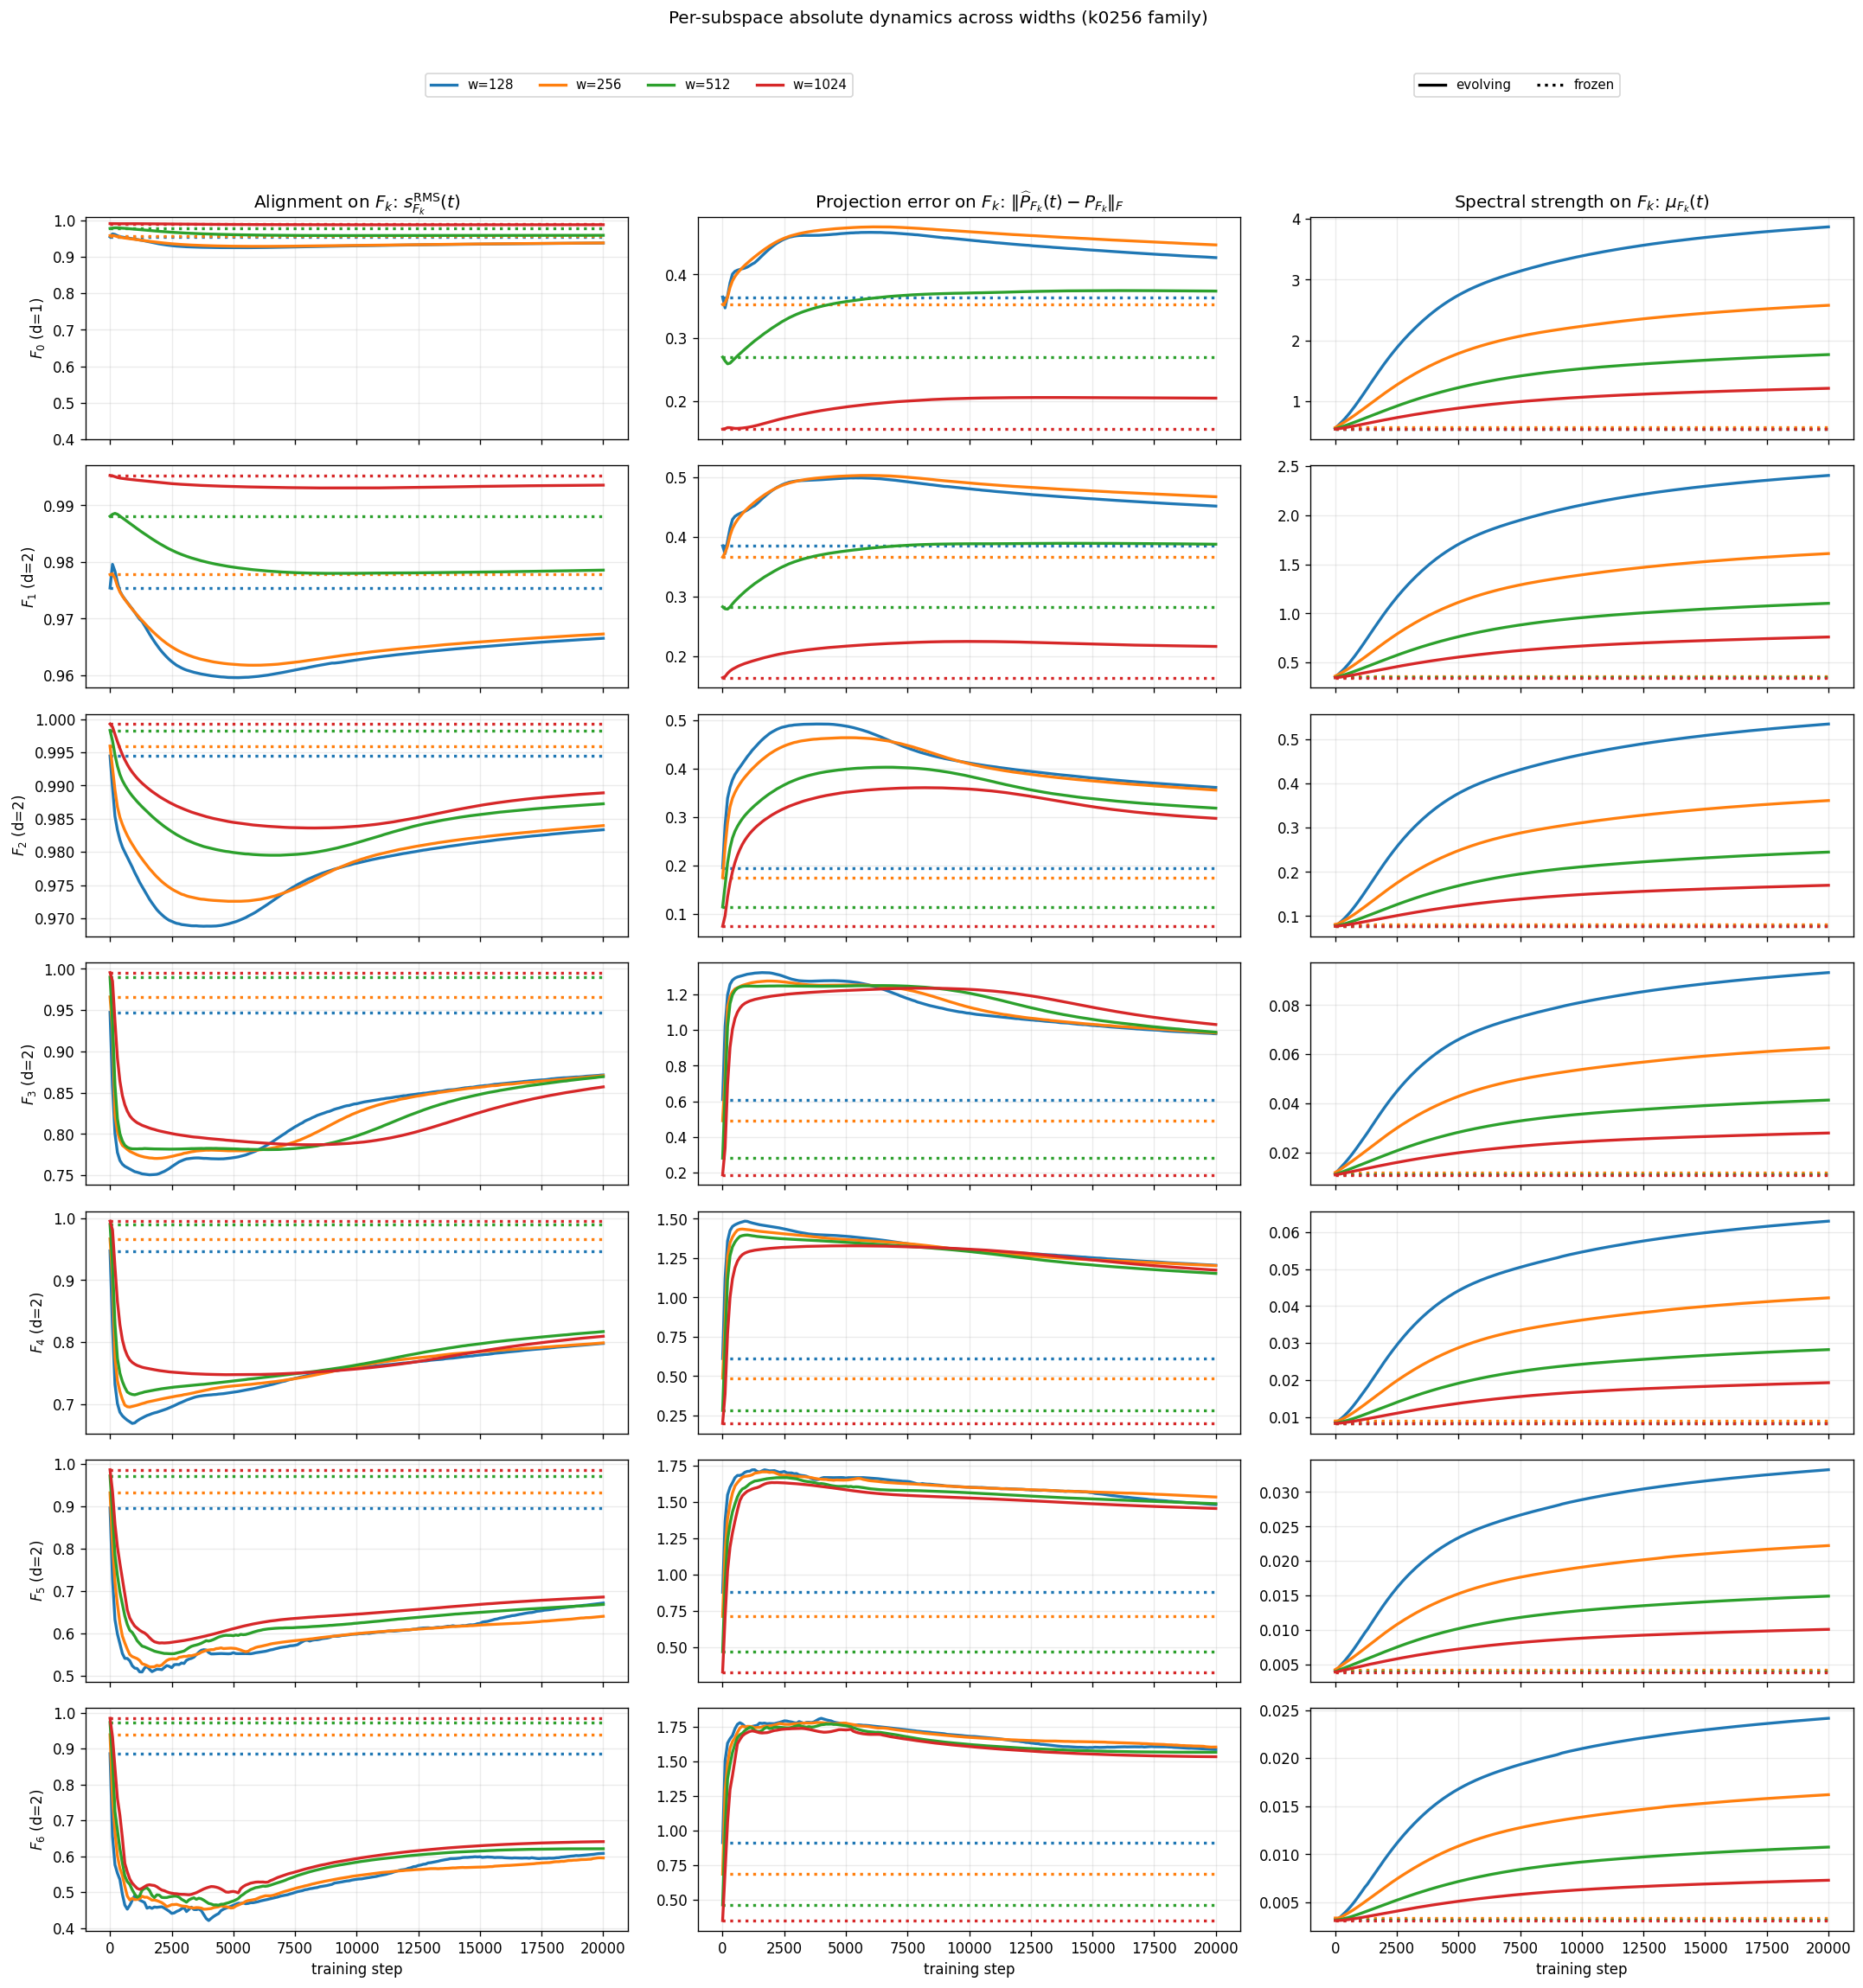

In [24]:
from matplotlib.lines import Line2D

WIDTHS_GRID = [128, 256, 512, 1024]
TARGET_GRID_FMT = 'ntk_frozen_vs_evolving_mode_dynamics_k0256_equalamp_w{width}'

story_plot_dir = ROOT / 'notebooks' / 'plots' / 'ntk_frozen_vs_evolving_mode_dynamics_width_compare'
story_plot_dir.mkdir(parents=True, exist_ok=True)


def _per_plane_mu_from_prefix(prefix_mu, prefix_dims):
    prefix_mu = np.asarray(prefix_mu, dtype=float)
    prefix_dims = np.asarray(prefix_dims, dtype=float)

    tau_cum = prefix_mu * prefix_dims.reshape(1, 1, -1)
    tau_plane = np.full_like(tau_cum, np.nan, dtype=float)

    tau_plane[:, :, 0] = tau_cum[:, :, 0]
    if tau_cum.shape[2] > 1:
        tau_plane[:, :, 1:] = tau_cum[:, :, 1:] - tau_cum[:, :, :-1]

    d_plane = np.empty((tau_cum.shape[2],), dtype=float)
    d_plane[0] = prefix_dims[0]
    if tau_cum.shape[2] > 1:
        d_plane[1:] = prefix_dims[1:] - prefix_dims[:-1]

    mu_plane = tau_plane / np.maximum(d_plane.reshape(1, 1, -1), 1e-12)
    return mu_plane, d_plane


width_colors = {
    128: 'C0',
    256: 'C1',
    512: 'C2',
    1024: 'C3',
}

story = {}
for w in WIDTHS_GRID:
    exp_name_w = TARGET_GRID_FMT.format(width=w)
    run_dir_w = latest_run_dir(BASE_RESULTS, exp_name_w)
    if run_dir_w is None:
        print(f'Skip missing run: {exp_name_w}')
        continue

    manifest_w = load_manifest(run_dir_w)
    width_key = sorted([int(x) for x in manifest_w['runs'].keys()])[0]
    run_w = npz(run_dir_w, manifest_w['runs'][str(width_key)])

    steps_w = np.asarray(run_w['snapshot_steps'], dtype=int)
    freqs_w = np.asarray(run_w['plane_freqs'], dtype=int)

    angles_f_w = np.asarray(run_w['plane_angles_frozen'], dtype=float)
    angles_e_w = np.asarray(run_w['plane_angles_evolving'], dtype=float)
    score_f_w = np.sqrt(np.nanmean(np.cos(angles_f_w) ** 2, axis=3))
    score_e_w = np.sqrt(np.nanmean(np.cos(angles_e_w) ** 2, axis=3))

    eps_f_w = np.asarray(run_w['plane_projector_fro_frozen'], dtype=float)
    eps_e_w = np.asarray(run_w['plane_projector_fro_evolving'], dtype=float)

    needed = {'prefix_mu_frozen', 'prefix_mu_evolving', 'prefix_freqs'}
    if not needed <= set(run_w.keys()):
        print(f'Skip width={w}: missing spectral keys {sorted(needed - set(run_w.keys()))}')
        continue

    prefix_freqs_w = np.asarray(run_w['prefix_freqs'], dtype=int)
    prefix_mu_f_w = np.asarray(run_w['prefix_mu_frozen'], dtype=float)
    prefix_mu_e_w = np.asarray(run_w['prefix_mu_evolving'], dtype=float)

    if 'prefix_dims' in run_w:
        prefix_dims_w = np.asarray(run_w['prefix_dims'], dtype=int)
    else:
        prefix_dims_w = 1 + 2 * prefix_freqs_w

    if len(prefix_freqs_w) > 1 and not np.all(np.diff(prefix_freqs_w) == 1):
        print(
            f'Warning width={w}: prefix cutoffs are not consecutive ({prefix_freqs_w.tolist()}); '
            'mu_{F_k} will represent per-band increments between listed cutoffs.'
        )

    mu_plane_f_all, d_plane_w = _per_plane_mu_from_prefix(prefix_mu_f_w, prefix_dims_w)
    mu_plane_e_all, _ = _per_plane_mu_from_prefix(prefix_mu_e_w, prefix_dims_w)

    idx_map = {int(k): i for i, k in enumerate(prefix_freqs_w)}
    if not set(int(k) for k in freqs_w).issubset(set(idx_map.keys())):
        missing_freqs = sorted(set(int(k) for k in freqs_w) - set(idx_map.keys()))
        print(f'Skip width={w}: missing prefix frequencies for {missing_freqs}')
        continue

    idx_w = np.asarray([idx_map[int(k)] for k in freqs_w], dtype=int)

    story[int(w)] = {
        'steps': steps_w,
        'freqs': freqs_w,
        'align_f': score_f_w,
        'align_e': score_e_w,
        'proj_f': eps_f_w,
        'proj_e': eps_e_w,
        'mu_f': mu_plane_f_all[:, :, idx_w],
        'mu_e': mu_plane_e_all[:, :, idx_w],
        'd_plane': d_plane_w[idx_w],
    }

if len(story) == 0:
    raise RuntimeError('No widths available for per-subspace story grid.')

available_widths = [w for w in WIDTHS_GRID if w in story]
common_freqs = sorted(set.intersection(*(set(int(k) for k in story[w]['freqs']) for w in available_widths)))
if len(common_freqs) == 0:
    raise RuntimeError('No common plane frequencies across available widths.')

print('Story grid widths:', available_widths)
print('Story grid frequencies:', common_freqs)

n_rows = len(common_freqs)
fig, axes = plt.subplots(n_rows, 3, figsize=(18.0, 2.6 * n_rows), sharex='col')
axes = np.asarray(axes)
if n_rows == 1:
    axes = axes[None, :]

col_titles = [
    r'Alignment on $F_k$: $s_{F_k}^{\mathrm{RMS}}(t)$',
    r'Projection error on $F_k$: $\|\widehat P_{F_k}(t)-P_{F_k}\|_F$',
    r'Spectral strength on $F_k$: $\mu_{F_k}(t)$',
]
for c, title in enumerate(col_titles):
    axes[0, c].set_title(title)

for r, k in enumerate(common_freqs):
    for w in available_widths:
        info = story[w]
        j = int(np.where(info['freqs'] == int(k))[0][0])
        steps = info['steps']
        color = width_colors.get(w, default_cycle[(w // 128) % len(default_cycle)])

        ma_f, _ = seed_mean_std(info['align_f'][:, :, j])
        ma_e, _ = seed_mean_std(info['align_e'][:, :, j])

        mp_f, _ = seed_mean_std(info['proj_f'][:, :, j])
        mp_e, _ = seed_mean_std(info['proj_e'][:, :, j])

        mm_f, _ = seed_mean_std(info['mu_f'][:, :, j])
        mm_e, _ = seed_mean_std(info['mu_e'][:, :, j])

        axes[r, 0].plot(steps, ma_e, color=color, linestyle='-', linewidth=2.0)
        axes[r, 0].plot(steps, ma_f, color=color, linestyle=':', linewidth=2.0)

        axes[r, 1].plot(steps, mp_e, color=color, linestyle='-', linewidth=2.0)
        axes[r, 1].plot(steps, mp_f, color=color, linestyle=':', linewidth=2.0)

        axes[r, 2].plot(steps, mm_e, color=color, linestyle='-', linewidth=2.0)
        axes[r, 2].plot(steps, mm_f, color=color, linestyle=':', linewidth=2.0)

    d_k = 1 if int(k) == 0 else 2
    axes[r, 0].set_ylabel(rf'$F_{{{int(k)}}}$ (d={d_k})')
    for c in range(3):
        axes[r, c].grid(True, alpha=0.25)

for c in range(3):
    axes[-1, c].set_xlabel('training step')

axes[0, 0].set_ylim(0.4, 1.01)

width_handles = [
    Line2D([0], [0], color=width_colors[w], linewidth=2.0, linestyle='-', label=f'w={w}')
    for w in available_widths
]
branch_handles = [
    Line2D([0], [0], color='black', linewidth=2.0, linestyle='-', label='evolving'),
    Line2D([0], [0], color='black', linewidth=2.0, linestyle=':', label='frozen'),
]

fig.legend(
    width_handles,
    [h.get_label() for h in width_handles],
    loc='upper center',
    ncol=len(available_widths),
    bbox_to_anchor=(0.34, 1.02),
    fontsize=9,
)
fig.legend(
    branch_handles,
    [h.get_label() for h in branch_handles],
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.81, 1.02),
    fontsize=9,
)

fig.suptitle('Per-subspace absolute dynamics across widths (k0256 family)', y=1.05)
fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.98])

filename = story_plot_dir / 'per_subspace_story_grid_absolute_equalamp_w128_w256_w512_w1024.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

